> **© 2026 Suna Kim. All Rights Reserved.**
>
> This repository is shared publicly to demonstrate applied finance/coding
> skills as part of my professional portfolio. No permission is granted to
> use, copy, modify, or distribute this code without explicit written
> consent from the author.

# 📊 Scenario Simulation — Historical Analogue Price Projection


## Overview

```
Cell 01  Settings     ← EDIT HERE — all config in one place
Cell 02  Install      ← run once per session
Cell 03  Engine       ← run once per session (do not edit)
─────────────────────────────────────────────────────
Cell 04  Proxies + weights    ← re-run when market changes
Cell 05  Prices               ← re-run when tickers change
Cell 06  Fundamentals         ← optional
─────────────────────────────────────────────────────
Cell 07  Fan charts           ← main simulation output
Cell 08  All-scenario grids   ← detailed scenario view
Cell 09  Factor regression    ← factor-based projection
Cell 10  Bond strip           ← yield curve / discount factors
─────────────────────────────────────────────────────
Cell 11  Summary table        ← cross-nation CSV
Cell 12  Re-inspect weights   ← anytime
Cell 13  Ad-hoc ticker        ← any ticker on demand
```

---
## ▶ Section 1 — Setup  *(run once per session)*

## Cell 01 — ⚙️ Settings  *(the only cell you need to edit)*

Everything you might want to change lives here. Edit this cell, then run
Section 1 top-to-bottom. No other cell needs touching for a normal run.

In [ ]:
import os
import sys
import subprocess
import importlib
import getpass

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  A. OUTPUT FOLDER                                                           ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
OUTPUT_DIR = "./sim_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  B. INSTALL PACKAGES — FAST / SKIP IF ALREADY INSTALLED                    ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
REQUIRED_PKGS = {
    "yfinance": "yfinance",
    "fredapi": "fredapi",
    "pandas_datareader": "pandas-datareader",
    "statsmodels": "statsmodels",
    "scipy": "scipy",
    "sklearn": "scikit-learn",
}

def install_if_missing(import_name, pip_name):
    if importlib.util.find_spec(import_name) is None:
        print(f"Installing {pip_name}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name, "-q"])
    else:
        print(f"✅ {pip_name} already installed")

for import_name, pip_name in REQUIRED_PKGS.items():
    install_if_missing(import_name, pip_name)

print("\nPackages ready.")

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  C. FRED CONNECTION                                                         ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
FRED_API_KEY = "input your fred api key"

RF_ANN = 0.045
FRED_DATA = {}

try:
    from fredapi import Fred
    from datetime import datetime

    fred = Fred(api_key=FRED_API_KEY)
    s, e = datetime(2020, 1, 1), datetime.today()

    dgs3mo = fred.get_series("DGS3MO", observation_start=s, observation_end=e).dropna()
    dgs10  = fred.get_series("DGS10",  observation_start=s, observation_end=e).dropna()
    dgs2   = fred.get_series("DGS2",   observation_start=s, observation_end=e).dropna()

    RF_ANN = float(dgs3mo.iloc[-1]) / 100
    slope = float(dgs10.iloc[-1]) / 100 - float(dgs2.iloc[-1]) / 100

    FRED_DATA = {
        "rf_ann": RF_ANN,
        "slope_10y2y": slope,
        "dgs10": float(dgs10.iloc[-1]) / 100,
        "dgs2": float(dgs2.iloc[-1]) / 100,
    }

    print(
        f"\n✅  FRED: RF={RF_ANN:.2%}  |  10Y-2Y={slope:+.2%}  "
        f"({'normal' if slope > 0 else 'INVERTED ⚠️'})"
    )

except Exception as e:
    print(f"\n⚠  FRED failed: {e} — using RF_ANN={RF_ANN:.1%} fallback")

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  D. WRDS DEFAULT STATE — RUN-ALL SAFE                                      ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
USE_WRDS = True
db = None
HAS_WRDS = False

print("ℹ WRDS login skipped in Cell 01A.")
print("   Run Cell 01B manually if you want WRDS connected.")

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  E. PROJECTION DATES                                                        ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
PROJECTION_START = "2026-05-08"
PROJECTION_END   = "2029-01-20"

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  G. SCENARIO WEIGHTS                                                        ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
SCENARIO_WEIGHTS = {
    "oil_shock_1973": 2.0,
    "nixon_shock_1971": 1.5,
    "nixon_watergate_1973": 1.5,
    "tariff_shock_2025": 1.0,
    "rate_shock_2022": 1.0,
    "gfc_2008": 0.8,
    "roaring_tech_boom_1990s": 0.5,
    "gulf_war_1990": 0.5,
    "soft_landing": 0.2,
}

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  H. SIMULATION SETTINGS                                                     ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
N_PATHS = 3000

CALIBRATION_LOOKBACK_DAYS = 252
STACKING_LOOKBACK_DAYS = 252
STACKING_FORWARD_DAYS = 21

GLOBAL_ANALYSIS_START = "2021-01-01"

WEIGHT_SENSITIVITY = 0.60
SHOW_PLOTS = True
CHART_DPI = 150

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  I. WEIGHT BLEND SETTINGS                                                   ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
WEIGHT_PRIOR = 0.20
WEIGHT_DISTANCE = 0.40
WEIGHT_BAYESIAN = 0.40

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  F. TICKER WATCHLIST / SIM CONFIG                                           ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
SIM_CONFIG = {
    "MARKETS": {
        "usa": {
            "enabled": True,
            "currency": "USD",
            "market_index": "SPY",
            "fx_to_usd": None,
            "tickers": {
                "SPY":  {"analysis_start": None,         "beta_override": 1.00, "sector": "default",      "product_type": "etf",   "kor_name": "S&P500 ETF"},
                "QQQ":  {"analysis_start": None,         "beta_override": None, "sector": "tech",          "product_type": "etf",   "kor_name": "나스닥100 ETF"},
                "IWM":  {"analysis_start": None,         "beta_override": None, "sector": "default",       "product_type": "etf",   "kor_name": "러셀2000 ETF"},
                "NVDA": {"analysis_start": "2019-01-01", "beta_override": None, "sector": "semiconductor", "product_type": "stock", "kor_name": "엔비디아"},
                "AAPL": {"analysis_start": None,         "beta_override": None, "sector": "tech",          "product_type": "stock", "kor_name": "애플"},
                "MSFT": {"analysis_start": None,         "beta_override": None, "sector": "tech",          "product_type": "stock", "kor_name": "마이크로소프트"},
                "TSM":  {"analysis_start": None,         "beta_override": None, "sector": "semiconductor", "product_type": "stock", "kor_name": "TSMC ADR"},
                "XOM":  {"analysis_start": None,         "beta_override": None, "sector": "energy",        "product_type": "stock", "kor_name": "엑슨모빌"},
                "CVX":  {"analysis_start": None,         "beta_override": None, "sector": "energy",        "product_type": "stock", "kor_name": "쉐브론"},
                "GLD":  {"analysis_start": None,         "beta_override": None, "sector": "gold",          "product_type": "etf",   "kor_name": "금 ETF"},
                "TLT":  {"analysis_start": None,         "beta_override": None, "sector": "bond",          "product_type": "etf",   "kor_name": "20년+ 국채 ETF"},
            },
        },

        "kor": {
            "enabled": False,
            "currency": "KRW",
            "market_index": "^KS11",
            "fx_to_usd": "USDKRW=X",
            "tickers": {
                "005930.KS": {"analysis_start": None, "beta_override": None, "sector": "semiconductor", "product_type": "stock", "kor_name": "삼성전자"},
                "000660.KS": {"analysis_start": None, "beta_override": None, "sector": "semiconductor", "product_type": "stock", "kor_name": "SK하이닉스"},
                "005380.KS": {"analysis_start": None, "beta_override": None, "sector": "auto",          "product_type": "stock", "kor_name": "현대자동차"},
                "035420.KS": {"analysis_start": None, "beta_override": None, "sector": "tech",          "product_type": "stock", "kor_name": "NAVER"},
                "207940.KS": {"analysis_start": None, "beta_override": None, "sector": "bio",           "product_type": "stock", "kor_name": "삼성바이오로직스"},
            },
        },

        "jpn": {
            "enabled": False,
            "currency": "JPY",
            "market_index": "^N225",
            "fx_to_usd": "USDJPY=X",
            "tickers": {
                "7203.T": {"analysis_start": None, "beta_override": None, "sector": "auto",       "product_type": "stock", "kor_name": "도요타"},
                "6758.T": {"analysis_start": None, "beta_override": None, "sector": "tech",       "product_type": "stock", "kor_name": "소니"},
                "9984.T": {"analysis_start": None, "beta_override": None, "sector": "tech",       "product_type": "stock", "kor_name": "소프트뱅크"},
                "7974.T": {"analysis_start": None, "beta_override": None, "sector": "tech",       "product_type": "stock", "kor_name": "닌텐도"},
                "8306.T": {"analysis_start": None, "beta_override": None, "sector": "financials", "product_type": "stock", "kor_name": "미쓰비시UFJ"},
            },
        },

        "chn": {
            "enabled": False,
            "currency": "USD",
            "market_index": "MCHI",
            "fx_to_usd": None,
            "tickers": {
                "BABA": {"analysis_start": None, "beta_override": None, "sector": "tech",     "product_type": "stock", "kor_name": "알리바바 ADR"},
                "PDD":  {"analysis_start": None, "beta_override": None, "sector": "consumer", "product_type": "stock", "kor_name": "핀둬둬 ADR"},
                "JD":   {"analysis_start": None, "beta_override": None, "sector": "consumer", "product_type": "stock", "kor_name": "징둥닷컴 ADR"},
                "BIDU": {"analysis_start": None, "beta_override": None, "sector": "tech",     "product_type": "stock", "kor_name": "바이두 ADR"},
                "MCHI": {"analysis_start": None, "beta_override": None, "sector": "default",  "product_type": "etf",   "kor_name": "중국 MSCI ETF"},
            },
        },
    },

    "PROJECTION_START": PROJECTION_START,
    "PROJECTION_END": PROJECTION_END,
    "GLOBAL_ANALYSIS_START": GLOBAL_ANALYSIS_START,

    "PROXIES": {
        "market": "SPY",
        "tech": "QQQ",
        "small_cap": "IWM",
        "volatility": "^VIX",
        "tbill": "SGOV",
        "short_bond": "SHY",
        "long_bond": "TLT",
        "credit_ig": "LQD",
        "credit_hy": "HYG",
        "credit_em": "EMB",
        "tips": "TIP",
        "commodity": "PDBC",
        "usd": "UUP",
        "discretionary": "XLY",
        "staples": "XLP",
        "financials": "XLF",
        "gold": "GLD",
        "oil": "USO",
    },

    "CALIBRATION_LOOKBACK_DAYS": CALIBRATION_LOOKBACK_DAYS,
    "STACKING_LOOKBACK_DAYS": STACKING_LOOKBACK_DAYS,
    "STACKING_FORWARD_DAYS": STACKING_FORWARD_DAYS,

    "SCENARIO_WEIGHTS": SCENARIO_WEIGHTS,
    "N_PATHS": N_PATHS,
    "WEIGHT_SENSITIVITY": WEIGHT_SENSITIVITY,
    "WEIGHT_PRIOR": WEIGHT_PRIOR,
    "WEIGHT_DISTANCE": WEIGHT_DISTANCE,
    "WEIGHT_BAYESIAN": WEIGHT_BAYESIAN,

    "SAVE_DIR": OUTPUT_DIR,
    "SHOW_PLOTS": SHOW_PLOTS,
    "CHART_DPI": CHART_DPI,

    "USE_WRDS": USE_WRDS,
}

nations = [n for n, m in SIM_CONFIG["MARKETS"].items() if m.get("enabled")]
n_tickers = sum(
    len(m["tickers"])
    for m in SIM_CONFIG["MARKETS"].values()
    if m.get("enabled")
)

print(f"\n✅  Cell 01A complete")
print(f"   Output      : {OUTPUT_DIR}")
print(f"   Projection  : {PROJECTION_START} → {PROJECTION_END}")
print(f"   Nations     : {nations}  ({n_tickers} tickers)")
print(f"   Scenarios   : {list(SCENARIO_WEIGHTS.keys())}")
print(f"   N_PATHS     : {N_PATHS}  |  prior={WEIGHT_PRIOR:.0%} / distance={WEIGHT_DISTANCE:.0%} / bayes={WEIGHT_BAYESIAN:.0%}")
print(f"   FRED        : {'✅ connected' if FRED_DATA else '⚠ fallback rate used'}")
print(f"   WRDS        : {'✅ connected' if HAS_WRDS else 'ℹ skipped; run Cell 01B manually if needed'}")

✅ yfinance already installed
✅ fredapi already installed
✅ pandas-datareader already installed
✅ statsmodels already installed
✅ scipy already installed
✅ scikit-learn already installed

Packages ready.

✅  FRED: RF=3.69%  |  10Y-2Y=+0.51%  (normal)
ℹ WRDS login skipped in Cell 01A.
   Run Cell 01B manually if you want WRDS connected.

✅  Cell 01A complete
   Output      : ./sim_output
   Projection  : 2026-05-08 → 2029-01-20
   Nations     : ['usa']  (11 tickers)
   Scenarios   : ['oil_shock_1973', 'nixon_shock_1971', 'nixon_watergate_1973', 'tariff_shock_2025', 'rate_shock_2022', 'gfc_2008', 'roaring_tech_boom_1990s', 'gulf_war_1990', 'soft_landing']
   N_PATHS     : 3000  |  prior=20% / distance=40% / bayes=40%
   FRED        : ✅ connected
   WRDS        : ℹ skipped; run Cell 01B manually if needed


## Cell 02 — Install packages  *(run once per session)*

In [ ]:
!pip install yfinance fredapi pandas-datareader statsmodels scipy scikit-learn --quiet
# !pip install wrds --quiet   # ← uncomment if you have a WRDS subscription

import importlib
REQUIRED = ["numpy","pandas","matplotlib","scipy","yfinance","fredapi","sklearn"]
all_ok = True
for pkg in REQUIRED:
    found = importlib.util.find_spec(pkg) is not None
    if not found: all_ok = False
    try: ver = getattr(__import__(pkg.replace("-","_")), "__version__", "?")
    except: ver = "missing"
    print(f"  {'✅' if found else '❌'}  {pkg:<20} {ver}")

HAS_WRDS = importlib.util.find_spec("wrds") is not None
print(f"  {'✅' if HAS_WRDS else 'ℹ '}  wrds                 {'installed' if HAS_WRDS else 'not installed (optional)'}")
print()
print("✅  Ready" if all_ok else "❌  Re-run the pip install line above")

  ✅  numpy                2.0.2
  ✅  pandas               2.2.2
  ✅  matplotlib           3.10.0
  ✅  scipy                1.16.3
  ✅  yfinance             0.2.66
  ✅  fredapi              0.5.2
  ✅  sklearn              1.6.1
  ✅  wrds                 installed

✅  Ready


## Cell 03 —  Engine  *(run once per session)*

In [ ]:
#CELL 03

import numpy as np
import pandas as pd
import json
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from scipy.stats import norm
from datetime import datetime, timedelta
import os, warnings
warnings.filterwarnings("ignore")

try:
    import yfinance as yf
    _YF_AVAILABLE = True
except ImportError:
    _YF_AVAILABLE = False
    print("⚠  yfinance not installed")

try:
    from fredapi import Fred
    _FRED_AVAILABLE = True
except ImportError:
    _FRED_AVAILABLE = False

try:
    import wrds as _wrds_mod
    _WRDS_AVAILABLE = True
except ImportError:
    _WRDS_AVAILABLE = False


# ── Shared robust yfinance price fetcher (used by engine + cell 03) ───────────
def _yf_prices(syms: list, period: str = "5d") -> pd.Series:
    """Always returns a Series of last prices. Never raises."""
    if not syms or not _YF_AVAILABLE:
        return pd.Series(dtype=float)
    try:
        raw = yf.download(syms, period=period, auto_adjust=True, progress=False)["Close"]
        if isinstance(raw, pd.Series):
            raw = raw.to_frame(name=syms[0])
        raw = raw.dropna(axis=1, how="all")
        return raw.ffill().iloc[-1].dropna()
    except Exception as e:
        print(f"   ⚠ _yf_prices failed: {e}")
        return pd.Series(dtype=float)


# ── Derive flat ticker table from MARKETS ────────────────────────────────────
def _build_ticker_table(markets: dict) -> dict:
    flat = {}
    for nation, mkt in markets.items():
        if not mkt.get("enabled", True):
            continue
        for sym, cfg in mkt["tickers"].items():
            flat[sym] = {
                **cfg,
                "nation":       nation,
                "currency":     mkt["currency"],
                "market_index": mkt["market_index"],
                "fx_to_usd":    mkt["fx_to_usd"],
            }
    return flat

def get_tickers_by_nation(nation: str) -> dict:
    mkt = SIM_CONFIG["MARKETS"].get(nation, {})
    if not mkt.get("enabled", False):
        return {}
    return {
        sym: {**cfg, "nation": nation,
              "currency": mkt["currency"],
              "market_index": mkt["market_index"],
              "fx_to_usd": mkt["fx_to_usd"]}
        for sym, cfg in mkt["tickers"].items()
    }

def get_enabled_nations() -> list:
    return [n for n, m in SIM_CONFIG["MARKETS"].items() if m.get("enabled", True)]

def get_market_index(nation: str) -> str:
    return SIM_CONFIG["MARKETS"].get(nation, {}).get("market_index", "SPY")

def get_fx_ticker(nation: str):
    return SIM_CONFIG["MARKETS"].get(nation, {}).get("fx_to_usd", None)


_MARKETS      = SIM_CONFIG["MARKETS"]
_TICKERS      = _build_ticker_table(_MARKETS)
_ENABLED_NATS = get_enabled_nations()

def _parse_date(s):
    return datetime.strptime(s, "%Y-%m-%d") if s else datetime.today()

_PROJ_START  = _parse_date(SIM_CONFIG.get("PROJECTION_START"))
_PROJ_END    = _parse_date(SIM_CONFIG.get("PROJECTION_END"))
_HORIZON     = max(0.1, (_PROJ_END - _PROJ_START).days / 365.25)

_GLOBAL_START = SIM_CONFIG["GLOBAL_ANALYSIS_START"]
_PROXIES      = SIM_CONFIG["PROXIES"]
_CAL_DAYS     = SIM_CONFIG["CALIBRATION_LOOKBACK_DAYS"]
_N_PATHS      = SIM_CONFIG["N_PATHS"]
_WEIGHT_SENS  = SIM_CONFIG["WEIGHT_SENSITIVITY"]
_SAVE_DIR     = SIM_CONFIG["SAVE_DIR"]
_SHOW_PLOTS   = SIM_CONFIG["SHOW_PLOTS"]
_CHART_DPI    = SIM_CONFIG["CHART_DPI"]

_raw_w = SIM_CONFIG["SCENARIO_WEIGHTS"]
_total = sum(v for v in _raw_w.values() if v > 0)
DEFAULT_WEIGHTS = {k: v / _total for k, v in _raw_w.items() if v > 0}


# ══════════════════════════════════════════════════════════════════════════════
# 0b.  LIVE PROXY CALIBRATION
# ══════════════════════════════════════════════════════════════════════════════

_PROXY_CACHE: dict = {}

def _load_proxy_data(force_refresh: bool = False) -> dict:
    global _PROXY_CACHE
    if _PROXY_CACHE and not force_refresh:
        return _PROXY_CACHE

    if not _YF_AVAILABLE:
        print("  ⚠  yfinance not installed — skipping live proxy calibration.")
        return {}

    end   = datetime.today()
    start = end - timedelta(days=_CAL_DAYS + 30)
    result = {}

    syms = list(_PROXIES.values())
    try:
        raw = yf.download(syms, start=start, end=end,
                          auto_adjust=True, progress=False)["Close"]
        if isinstance(raw, pd.Series):
            raw = raw.to_frame(name=syms[0])
        raw = raw.dropna(axis=1, how="all")
        ret = raw.pct_change(fill_method=None).dropna(how="all").iloc[1:]
        ret = ret.last(f"{_CAL_DAYS}D")
        for role, sym in _PROXIES.items():
            if sym in ret.columns:
                result[role] = ret[sym].dropna()
    except Exception as exc:
        print(f"  ⚠  Proxy download error: {exc}")

    _PROXY_CACHE = result
    return result


def _annualised(series: pd.Series) -> float:
    return float(series.mean() * 252) if len(series) > 20 else 0.0

def _ann_vol(series: pd.Series) -> float:
    return float(series.std() * np.sqrt(252)) if len(series) > 20 else 0.0


_BASELINE = {
    "market_vol":   0.16,
    "market_drift": 0.10,
    "vix_normal":  18.0,
    "hy_spread":    4.5,
    "oil_vol":      0.35,
    "gold_drift":   0.06,
    "bond_drift":   0.03,
    "usd_drift":    0.0,
    "tips_drift":   0.02,
}


def compute_signals(proxy_data: dict) -> dict:
    mkt   = proxy_data.get("market",        pd.Series(dtype=float))
    vix   = proxy_data.get("volatility",    pd.Series(dtype=float))
    bond  = proxy_data.get("long_bond",     pd.Series(dtype=float))
    sbond = proxy_data.get("short_bond",    pd.Series(dtype=float))
    hy    = proxy_data.get("credit_hy",     pd.Series(dtype=float))
    ig    = proxy_data.get("credit_ig",     pd.Series(dtype=float))
    gold  = proxy_data.get("gold",          pd.Series(dtype=float))
    oil   = proxy_data.get("oil",           pd.Series(dtype=float))
    usd   = proxy_data.get("usd",           pd.Series(dtype=float))
    tips  = proxy_data.get("tips",          pd.Series(dtype=float))
    pdbc  = proxy_data.get("commodity",     pd.Series(dtype=float))
    xly   = proxy_data.get("discretionary", pd.Series(dtype=float))
    xlp   = proxy_data.get("staples",       pd.Series(dtype=float))
    xlf   = proxy_data.get("financials",    pd.Series(dtype=float))

    mkt_ann       = _annualised(mkt)
    mkt_vol       = _ann_vol(mkt)
    vix_last      = float(vix.iloc[-1]) if len(vix) > 0 else _BASELINE["vix_normal"]
    bond_ann      = _annualised(bond)
    sbond_ann     = _annualised(sbond)
    slope_proxy   = bond_ann - sbond_ann
    xly_ann       = _annualised(xly)
    xlp_ann       = _annualised(xlp)
    recession_sig = -(xly_ann - xlp_ann)
    xlf_ann       = _annualised(xlf)
    fin_stress    = -(xlf_ann - mkt_ann)

    return {
        "market_momentum":      mkt_ann,
        "equity_vol":           mkt_vol / _BASELINE["market_vol"],
        "vix_z":                (vix_last - _BASELINE["vix_normal"]) / 8.0,
        "credit_stress":        -_annualised(hy),
        "credit_ig_stress":     -_annualised(ig),
        "bond_stress":          -bond_ann,
        "yield_slope_proxy":    slope_proxy,
        "oil_shock":            _annualised(oil),
        "gold_demand":          _annualised(gold),
        "usd_strength":         _annualised(usd),
        "inflation_breakeven":  _annualised(tips),
        "commodity_pressure":   _annualised(pdbc),
        "recession_signal":     recession_sig,
        "financial_stress":     fin_stress,
    }


SCENARIO_ENTRY_CONDITIONS = {
    "nixon_watergate_1973": {
        "vix_z": -0.88, "credit_stress": 0.12, "credit_ig_stress": 0.05,
        "bond_stress": 0.10, "yield_slope_proxy": -0.01,
        "market_momentum": 0.28, "equity_vol": 0.75,
        "oil_shock": 0.08, "gold_demand": 0.05,
        "usd_strength": -0.12, "inflation_breakeven": 0.06,
        "commodity_pressure": 0.04, "recession_signal": -0.05, "financial_stress": -0.02,
    },
    "gulf_war_1990": {
        "vix_z": 0.38, "credit_stress": 0.35, "credit_ig_stress": 0.12,
        "bond_stress": 0.08, "yield_slope_proxy": 0.02,
        "market_momentum": -0.08, "equity_vol": 1.06,
        "oil_shock": 0.60, "gold_demand": 0.15,
        "usd_strength": 0.05, "inflation_breakeven": 0.08,
        "commodity_pressure": 0.25, "recession_signal": 0.10, "financial_stress": 0.18,
    },
    "roaring_tech_boom_1990s": {
    "vix_z": 0.10,                 # low/moderate volatility (complacent market)
    "credit_stress": -0.10,        # easy credit conditions
    "credit_ig_stress": -0.05,     # tight IG spreads
    "bond_stress": -0.08,          # stable bond market
    "yield_slope_proxy": 0.15,     # positively sloped curve (growth expectations)

    "market_momentum": 0.45,       # very strong upward momentum
    "equity_vol": 1.10,            # elevated but not crisis-level (tech speculation)

    "oil_shock": 0.05,             # not a major driver in this era
    "gold_demand": -0.15,          # low safe-haven demand

    "usd_strength": 0.20,          # strong USD in late 90s
    "inflation_breakeven": 0.05,   # modest inflation expectations

    "commodity_pressure": -0.05,   # subdued commodities vs equities
    "recession_signal": -0.20,     # very low recession risk
    "financial_stress": -0.15,     # loose financial conditions
},
    "gfc_2008": {
        "vix_z": -0.13, "credit_stress": -0.18, "credit_ig_stress": -0.10,
        "bond_stress": -0.12, "yield_slope_proxy": 0.03,
        "market_momentum": 0.18, "equity_vol": 0.69,
        "oil_shock": 0.45, "gold_demand": 0.12,
        "usd_strength": -0.08, "inflation_breakeven": 0.05,
        "commodity_pressure": 0.18, "recession_signal": 0.02, "financial_stress": -0.05,
    },
    "covid_crash_2020": {
        "vix_z": -0.13, "credit_stress": -0.18, "credit_ig_stress": -0.08,
        "bond_stress": -0.15, "yield_slope_proxy": 0.01,
        "market_momentum": 0.22, "equity_vol": 0.63,
        "oil_shock": -0.12, "gold_demand": 0.08,
        "usd_strength": 0.02, "inflation_breakeven": 0.02,
        "commodity_pressure": -0.05, "recession_signal": -0.02, "financial_stress": -0.03,
    },
    "rate_shock_2022": {
        "vix_z": -0.13, "credit_stress": -0.22, "credit_ig_stress": -0.12,
        "bond_stress": 0.25, "yield_slope_proxy": 0.04,
        "market_momentum": 0.28, "equity_vol": 0.81,
        "oil_shock": 0.55, "gold_demand": 0.05,
        "usd_strength": 0.05, "inflation_breakeven": 0.18,
        "commodity_pressure": 0.22, "recession_signal": -0.05, "financial_stress": -0.08,
    },
    "nixon_shock_1971": {
        "vix_z": -0.88, "credit_stress": -0.05, "credit_ig_stress": -0.03,
        "bond_stress": 0.03, "yield_slope_proxy": 0.01,
        "market_momentum": 0.12, "equity_vol": 0.69,
        "oil_shock": 0.05, "gold_demand": 0.08,
        "usd_strength": -0.08, "inflation_breakeven": 0.04,
        "commodity_pressure": 0.02, "recession_signal": -0.03, "financial_stress": -0.02,
    },
    "tariff_shock_2025": {
        "vix_z": 1.50, "credit_stress": 0.08, "credit_ig_stress": 0.03,
        "bond_stress": 0.05, "yield_slope_proxy": 0.02,
        "market_momentum": -0.10, "equity_vol": 1.75,
        "oil_shock": -0.15, "gold_demand": 0.25,
        "usd_strength": -0.05, "inflation_breakeven": 0.02,
        "commodity_pressure": -0.08, "recession_signal": 0.08, "financial_stress": 0.10,
    },
    "soft_landing": {
        "vix_z": 0.38, "credit_stress": 0.08, "credit_ig_stress": 0.03,
        "bond_stress": -0.08, "yield_slope_proxy": -0.03,
        "market_momentum": -0.12, "equity_vol": 1.25,
        "oil_shock": -0.20, "gold_demand": 0.02,
        "usd_strength": -0.05, "inflation_breakeven": 0.12,
        "commodity_pressure": -0.10, "recession_signal": 0.05, "financial_stress": 0.03,
    },
}

_DIST_COLS = [
    "vix_z", "credit_stress", "credit_ig_stress", "bond_stress",
    "yield_slope_proxy", "market_momentum", "equity_vol",
    "oil_shock", "gold_demand", "usd_strength",
    "inflation_breakeven", "commodity_pressure", "recession_signal", "financial_stress",
]
_EC_VALS  = {c: [SCENARIO_ENTRY_CONDITIONS[sc].get(c, 0.0)
                 for sc in SCENARIO_ENTRY_CONDITIONS] for c in _DIST_COLS}
_DIST_MED = {c: float(np.median(_EC_VALS[c])) for c in _DIST_COLS}
_DIST_IQR = {c: float(np.percentile(_EC_VALS[c], 75) -
                       np.percentile(_EC_VALS[c], 25)) for c in _DIST_COLS}

_DIST_SIG_W = {
    "vix_z":               2.5, "credit_stress":       3.0,
    "credit_ig_stress":    2.0, "bond_stress":         2.5,
    "yield_slope_proxy":   3.0, "market_momentum":     1.5,
    "equity_vol":          1.5, "oil_shock":           2.5,
    "gold_demand":         1.0, "usd_strength":        1.0,
    "inflation_breakeven": 2.5, "commodity_pressure":  2.0,
    "recession_signal":    2.0, "financial_stress":    2.0,
}
_DIST_TEMP = 1.2


def _dist_vec(signals: dict) -> np.ndarray:
    out = []
    for c in _DIST_COLS:
        raw = signals.get(c, _DIST_MED[c])
        iqr = _DIST_IQR[c] if _DIST_IQR[c] > 0.005 else 0.05
        z   = np.tanh((raw - _DIST_MED[c]) / iqr * 0.8)
        out.append(z * _DIST_SIG_W[c])
    return np.array(out)


def compute_dynamic_weights(proxy_data: dict, base_weights: dict,
                             sensitivity: float = 0.60) -> dict:
    if not proxy_data:
        return dict(base_weights)
    sig     = compute_signals(proxy_data)
    cur_vec = _dist_vec(sig)
    distances = {}
    for sc_key in base_weights:
        if sc_key in SCENARIO_ENTRY_CONDITIONS:
            ref_vec = _dist_vec(SCENARIO_ENTRY_CONDITIONS[sc_key])
            distances[sc_key] = float(np.linalg.norm(cur_vec - ref_vec))
        else:
            distances[sc_key] = float(np.median(
                [np.linalg.norm(cur_vec - _dist_vec(SCENARIO_ENTRY_CONDITIONS[s]))
                 for s in SCENARIO_ENTRY_CONDITIONS]
            ))
    sc_keys = list(base_weights.keys())
    d_arr   = np.array([distances[k] for k in sc_keys])
    log_w   = -d_arr / _DIST_TEMP
    log_w  -= log_w.max()
    dist_w  = np.exp(log_w) / np.exp(log_w).sum()
    dist_weights = dict(zip(sc_keys, dist_w))
    prior_total  = sum(base_weights.values())
    norm_prior   = {k: v / prior_total for k, v in base_weights.items()}
    blended = {k: sensitivity * dist_weights[k] + (1 - sensitivity) * norm_prior[k]
               for k in sc_keys}
    total   = sum(blended.values())
    return {k: v / total for k, v in blended.items()}


def compute_calibration_scalars(proxy_data: dict) -> dict:
    if not proxy_data:
        return {}
    sig      = compute_signals(proxy_data)
    vol_sc   = max(0.5, min(2.5, sig["equity_vol"]))
    mkt_ann  = sig["market_momentum"]
    bond_ann = -sig["bond_stress"]
    hy_ann   = -sig["credit_stress"]
    ig_ann   = -sig["credit_ig_stress"]
    oil_ann  = sig["oil_shock"]
    gold_ann = sig["gold_demand"]
    pdbc_ann = sig["commodity_pressure"]
    rec_sig  = sig["recession_signal"]
    fin_sig  = sig["financial_stress"]
    return {
        "oil_shock_1973":      {"vol_scalar": vol_sc * (1 + max(0, oil_ann) * 0.3 + max(0, pdbc_ann) * 0.15),
                                "drift_adj":  oil_ann * 0.15 + gold_ann * 0.10 + pdbc_ann * 0.05},
        "gulf_war_1990":       {"vol_scalar": vol_sc * (1 + max(0, oil_ann) * 0.2),
                                "drift_adj":  oil_ann * 0.10},
        "roaring_tech_boom_1990s": {
    "vol_scalar": vol_sc * (1 + max(0, mkt_ann) * 0.25),
    "drift_adj":  mkt_ann * 0.25 - gold_ann * 0.05
},
        "gfc_2008":            {"vol_scalar": vol_sc * (1 + max(0, -hy_ann) * 0.4 + max(0, -ig_ann) * 0.2 + max(0, fin_sig) * 0.2),
                                "drift_adj":  hy_ann * 0.10 + bond_ann * 0.05 + ig_ann * 0.05},
        "covid_crash_2020":    {"vol_scalar": vol_sc * 1.1,
                                "drift_adj":  mkt_ann * 0.08},
        "rate_shock_2022":     {"vol_scalar": vol_sc,
                                "drift_adj":  bond_ann * 0.20},
        "tariff_shock_2025":   {"vol_scalar": vol_sc * (1 + max(0, -mkt_ann) * 0.2),
                                "drift_adj":  mkt_ann * 0.15 + oil_ann * 0.05 + rec_sig * 0.05},
        "nixon_shock_1971":    {"vol_scalar": vol_sc * (1 + max(0, -mkt_ann) * 0.15),
                                "drift_adj":  mkt_ann * 0.12 + gold_ann * 0.08},
        "nixon_watergate_1973":{"vol_scalar": vol_sc * (1 + max(0, oil_ann) * 0.25 + max(0, pdbc_ann) * 0.10),
                                "drift_adj":  oil_ann * 0.12 + gold_ann * 0.08 - mkt_ann * 0.08},
        "soft_landing":        {"vol_scalar": max(0.7, vol_sc * 0.85),
                                "drift_adj":  mkt_ann * 0.20 + bond_ann * 0.10 - rec_sig * 0.05},
    }


# ══════════════════════════════════════════════════════════════════════════════
# 0c.  BAYESIAN LIKELIHOOD WEIGHTS
# ══════════════════════════════════════════════════════════════════════════════

SCENARIO_WINDOWS = {
    "oil_shock_1973":        ("1973-01-01", "1975-06-30"),
    "nixon_shock_1971":      ("1971-08-01", "1972-12-31"),
    "nixon_watergate_1973":  ("1973-01-01", "1974-12-31"),
    "gulf_war_1990":         ("1990-08-01", "1991-06-30"),
    "roaring_tech_boom_1990s": ("1995-01-01", "2000-03-01"),
    "gfc_2008":              ("2007-10-01", "2010-12-31"),
    "covid_crash_2020":      ("2020-02-01", "2021-06-30"),
    "rate_shock_2022":       ("2022-01-01", "2023-12-31"),
    "tariff_shock_2025":     ("2025-03-01", "2025-12-31"),
    "soft_landing":          ("2023-01-01", "2024-06-30"),
}

HISTORICAL_PROXIES = {
    "market":     "^GSPC",
    "short_bond": "^IRX",
    "usd":        "DX-Y.NYB",
}

MODERN_PROXIES = {
    "market":        "SPY",  "long_bond":     "TLT",
    "short_bond":    "SHY",  "volatility":    "^VIX",
    "credit_hy":     "HYG",  "credit_ig":     "LQD",
    "oil":           "USO",  "gold":          "GLD",
    "usd":           "UUP",  "tips":          "TIP",
    "commodity":     "PDBC", "discretionary": "XLY",
    "staples":       "XLP",  "financials":    "XLF",
}

MODERN_PROXIES_GFC  = {k: v for k, v in MODERN_PROXIES.items() if k not in ("commodity",)}
MODERN_PROXIES_1990 = {k: v for k, v in MODERN_PROXIES.items() if k not in ("commodity", "tips", "usd")}

_MODERN_CUTOFF_YEAR   = 2003
_SCENARIO_DIST_CACHE: dict = {}
_BAYES_TEMP = SIM_CONFIG.get("WEIGHT_BAYES_TEMP", 5.0)


def _fetch_scenario_returns(sc_key: str, force_refresh: bool = False) -> pd.DataFrame:
    global _SCENARIO_DIST_CACHE
    cache_key = f"returns_{sc_key}"
    if cache_key in _SCENARIO_DIST_CACHE and not force_refresh:
        return _SCENARIO_DIST_CACHE[cache_key]
    if not _YF_AVAILABLE:
        return pd.DataFrame()
    window = SCENARIO_WINDOWS.get(sc_key)
    if not window:
        return pd.DataFrame()
    start_str, end_str = window
    start_year = int(start_str[:4])
    if start_year < _MODERN_CUTOFF_YEAR:
        proxy_map = HISTORICAL_PROXIES
    elif sc_key == "gfc_2008":
        proxy_map = MODERN_PROXIES_GFC
    elif sc_key == "gulf_war_1990":
        proxy_map = MODERN_PROXIES_1990
    else:
        proxy_map = MODERN_PROXIES
    try:
        syms = list(set(proxy_map.values()))
        raw  = yf.download(syms, start=start_str, end=end_str,
                           auto_adjust=True, progress=False)["Close"]
        if isinstance(raw, pd.Series):
            raw = raw.to_frame(name=syms[0])
        raw  = raw.dropna(axis=1, how="all")
        ret  = raw.pct_change(fill_method=None).dropna(how="all").iloc[1:]
        role_ret = {}
        for role, sym in proxy_map.items():
            if sym in ret.columns and ret[sym].dropna().shape[0] > 20:
                role_ret[role] = ret[sym].dropna()
        if not role_ret:
            return pd.DataFrame()
        df = pd.DataFrame(role_ret).dropna(how="all")
        _SCENARIO_DIST_CACHE[cache_key] = df
        return df
    except Exception as e:
        print(f"  ⚠  Could not fetch historical returns for {sc_key}: {e}")
        return pd.DataFrame()


def _fit_scenario_distribution(sc_key: str, force_refresh: bool = False) -> dict:
    cache_key = f"dist_{sc_key}"
    if cache_key in _SCENARIO_DIST_CACHE and not force_refresh:
        return _SCENARIO_DIST_CACHE[cache_key]
    df = _fetch_scenario_returns(sc_key, force_refresh=force_refresh)
    if df.empty or df.shape[0] < 20:
        return {}
    mean = df.mean()
    cov  = df.cov()
    n, p = df.shape
    shrinkage = min(0.1, p / n)
    cov_reg   = (1 - shrinkage) * cov + shrinkage * np.eye(p) * np.diag(cov).mean()
    result = {
        "mean":  mean,
        "cov":   pd.DataFrame(cov_reg, index=cov.index, columns=cov.columns),
        "roles": list(df.columns),
        "n_obs": df.shape[0],
    }
    _SCENARIO_DIST_CACHE[cache_key] = result
    return result


def _multivariate_log_likelihood(obs: pd.DataFrame, mean: pd.Series,
                                  cov: pd.DataFrame) -> float:
    common  = [c for c in mean.index if c in obs.columns]
    if len(common) < 2:
        return -np.inf
    obs_arr = obs[common].dropna().values
    mu      = mean[common].values
    sigma   = cov.loc[common, common].values
    if obs_arr.shape[0] < 5:
        return -np.inf
    try:
        from scipy.stats import multivariate_normal
        ll = multivariate_normal.logpdf(obs_arr, mean=mu, cov=sigma, allow_singular=True)
        return float(np.mean(ll))
    except Exception:
        return -np.inf


def compute_bayesian_weights(proxy_data: dict, base_weights: dict = None,
                              lookback_days: int = 252,
                              force_refresh: bool = False) -> dict:
    if base_weights is None:
        base_weights = DEFAULT_WEIGHTS
    if not proxy_data:
        print("  ⚠  No proxy data — returning prior for Bayesian weights.")
        return dict(base_weights)
    role_series = {}
    for role, series in proxy_data.items():
        trimmed = series.iloc[-lookback_days:] if len(series) > lookback_days else series
        if len(trimmed) > 20:
            role_series[role] = trimmed
    if not role_series:
        return dict(base_weights)
    recent_obs  = pd.DataFrame(role_series).dropna(how="all")
    prior_total = sum(base_weights.values())

    print(f"\n  BAYESIAN LIKELIHOOD WEIGHTS")
    print(f"  Recent window : {len(recent_obs)} trading days  |  Temp: {_BAYES_TEMP:.1f}")
    print(f"  {'─'*72}")
    print(f"  {'Scenario':<26} {'N_hist':>7}  {'LogLik':>9}  {'Prior':>6}  {'Posterior':>9}  {'Δ':>6}")
    print(f"  {'─'*72}")

    log_likelihoods = {}
    for sc_key in base_weights:
        dist = _fit_scenario_distribution(sc_key, force_refresh=force_refresh)
        if not dist:
            log_likelihoods[sc_key] = None
            continue
        log_likelihoods[sc_key] = _multivariate_log_likelihood(
            recent_obs, dist["mean"], dist["cov"])

    valid_lls = [v for v in log_likelihoods.values() if v is not None and v > -np.inf]
    median_ll = float(np.median(valid_lls)) if valid_lls else 0.0
    for sc_key in log_likelihoods:
        if log_likelihoods[sc_key] is None or log_likelihoods[sc_key] == -np.inf:
            log_likelihoods[sc_key] = median_ll

    sc_keys = list(base_weights.keys())
    ll_arr  = np.array([log_likelihoods[k] for k in sc_keys])
    ll_arr  = (ll_arr - ll_arr.mean()) / (ll_arr.std() + 1e-8)
    ll_arr /= _BAYES_TEMP
    ll_arr -= ll_arr.max()
    lik_w   = np.exp(ll_arr) / np.exp(ll_arr).sum()
    lik_weights = dict(zip(sc_keys, lik_w))

    posterior = {}
    for k in sc_keys:
        prior_k      = base_weights[k] / prior_total
        posterior[k] = lik_weights[k] * prior_k
    post_total = sum(posterior.values())
    posterior  = {k: v / post_total for k, v in posterior.items()}

    for sc_key in sorted(posterior, key=lambda x: -posterior[x]):
        dist    = _SCENARIO_DIST_CACHE.get(f"dist_{sc_key}", {})
        n_obs   = dist.get("n_obs", 0)
        ll      = log_likelihoods[sc_key]
        prior_k = base_weights[sc_key] / prior_total
        post_k  = posterior[sc_key]
        delta   = post_k - prior_k
        arrow   = "▲" if delta > 0.005 else ("▼" if delta < -0.005 else "·")
        print(f"  {sc_key:<26} {n_obs:>7}  {ll:>9.4f}  {prior_k:>5.1%}  "
              f"{post_k:>8.1%}  {arrow}{abs(delta):>4.1%}")
    print(f"  {'─'*72}")
    print(f"  Sum check: {sum(posterior.values()):.6f}")
    return posterior


def compute_blended_weights(prior_weights: dict, distance_weights: dict,
                             bayesian_weights: dict, w_prior: float = None,
                             w_distance: float = None, w_bayesian: float = None) -> dict:
    if w_prior    is None: w_prior    = SIM_CONFIG.get("WEIGHT_PRIOR",    1/3)
    if w_distance is None: w_distance = SIM_CONFIG.get("WEIGHT_DISTANCE", 1/3)
    if w_bayesian is None: w_bayesian = SIM_CONFIG.get("WEIGHT_BAYESIAN", 1/3)
    total_w    = w_prior + w_distance + w_bayesian
    w_prior   /= total_w; w_distance /= total_w; w_bayesian /= total_w
    def _norm(d):
        t = sum(d.values())
        return {k: v / t for k, v in d.items()} if t > 0 else d
    p = _norm(prior_weights); d = _norm(distance_weights); b = _norm(bayesian_weights)
    sc_keys = list(prior_weights.keys())
    blended = {k: w_prior * p.get(k, 0) + w_distance * d.get(k, 0) + w_bayesian * b.get(k, 0)
               for k in sc_keys}
    total = sum(blended.values())
    return {k: v / total for k, v in blended.items()}


# ══════════════════════════════════════════════════════════════════════════════
# 0d.  STACKING
# ══════════════════════════════════════════════════════════════════════════════

_PREDICTION_LOG_FILE = os.path.join(SIM_CONFIG.get("SAVE_DIR", "./sim_output"),
                                     "weight_prediction_log.json")
_MIN_HISTORY_DAYS = 60


def _load_prediction_log() -> list:
    try:
        if os.path.exists(_PREDICTION_LOG_FILE):
            with open(_PREDICTION_LOG_FILE, "r") as f:
                return json.load(f)
    except Exception as e:
        print(f"  ⚠  Could not load prediction log: {e}")
    return []


def _save_prediction_log(log: list) -> None:
    try:
        os.makedirs(os.path.dirname(_PREDICTION_LOG_FILE), exist_ok=True)
        with open(_PREDICTION_LOG_FILE, "w") as f:
            json.dump(log, f, indent=2, default=str)
    except Exception as e:
        print(f"  ⚠  Could not save prediction log: {e}")


def save_weight_predictions(prior_weights, distance_weights, bayesian_weights,
                             final_weights, proxy_data) -> None:
    sig = compute_signals(proxy_data) if proxy_data else {}
    recent_proxy_snapshot = {role: float(series.iloc[-1])
                              for role, series in proxy_data.items() if len(series) > 0}
    entry = {
        "timestamp":        datetime.today().strftime("%Y-%m-%d"),
        "prior_weights":    {k: float(v) for k, v in prior_weights.items()},
        "distance_weights": {k: float(v) for k, v in distance_weights.items()},
        "bayesian_weights": {k: float(v) for k, v in bayesian_weights.items()},
        "final_weights":    {k: float(v) for k, v in final_weights.items()},
        "signals":          {k: float(v) for k, v in sig.items()},
        "proxy_snapshot":   recent_proxy_snapshot,
        "realized_returns": None,
        "method_scores":    None,
    }
    log = _load_prediction_log()
    log = [e for e in log if e.get("timestamp") != entry["timestamp"]]
    log.append(entry)
    _save_prediction_log(log)
    print(f"  ✅  Prediction saved → {_PREDICTION_LOG_FILE}  ({len(log)} entries total)")


def _score_method_prediction(predicted_weights, realized_scenario_returns) -> float:
    implied_return  = sum(predicted_weights.get(sc, 0.0) * ret
                          for sc, ret in realized_scenario_returns.items())
    realized_return = np.mean(list(realized_scenario_returns.values()))
    return float(-abs(implied_return - realized_return))


def _compute_realized_scenario_returns(proxy_data: dict) -> dict:
    realized = {}
    for sc_key in SCENARIOS:
        dist = _SCENARIO_DIST_CACHE.get(f"dist_{sc_key}", {})
        if not dist:
            dist = _fit_scenario_distribution(sc_key)
        if dist and "mean" in dist:
            realized[sc_key] = float(dist["mean"].get("market", 0.0) * 252)
        else:
            realized[sc_key] = 0.0
    return realized

def evaluate_weight_accuracy(
    proxy_data:    dict,
    lookback_days: int  = 252,
    forward_days:  int  = 21,
    verbose:       bool = True,

) -> dict:
    """
    Backtest all three weighting methods over past `lookback_days` of proxy
    history. For each day t, computes signals from returns up to t, derives
    weights from all three methods, then scores against realized market return
    from t → t+forward_days. Returns blend weights proportional to accuracy.
    No future diary entries needed — fully self-contained from yfinance history.
    """
    if not _YF_AVAILABLE:
        print("  ⚠  yfinance not available — returning equal blend weights.")
        return {"WEIGHT_PRIOR": 1/3, "WEIGHT_DISTANCE": 1/3, "WEIGHT_BAYESIAN": 1/3}

    end   = datetime.today()
    start = end - timedelta(days=lookback_days + forward_days + 60)
    syms  = list(_PROXIES.values())

    try:
        raw = yf.download(syms, start=start, end=end,
                          auto_adjust=True, progress=False)["Close"]
        if isinstance(raw, pd.Series):
            raw = raw.to_frame(name=syms[0])
        raw      = raw.dropna(axis=1, how="all")
        ret_full = raw.pct_change(fill_method=None).dropna(how="all").iloc[1:]
    except Exception as e:
        print(f"  ⚠  Backtest download failed: {e}")
        return {"WEIGHT_PRIOR": 1/3, "WEIGHT_DISTANCE": 1/3, "WEIGHT_BAYESIAN": 1/3}

    mkt_sym = _PROXIES.get("market", "SPY")
    if mkt_sym not in ret_full.columns:
        print(f"  ⚠  Market proxy {mkt_sym} not in data.")
        return {"WEIGHT_PRIOR": 1/3, "WEIGHT_DISTANCE": 1/3, "WEIGHT_BAYESIAN": 1/3}

    if verbose:
        print(f"\n  STACKING BACKTEST  (lookback={lookback_days}d, forward={forward_days}d)")
        print(f"  Pre-fitting {len(SCENARIOS)} scenario distributions...")

    for sc_key in SCENARIOS:
        _fit_scenario_distribution(sc_key)

    trading_days  = ret_full.index[-lookback_days - forward_days:-forward_days]
    method_scores = {"prior": [], "distance": [], "bayesian": []}

    sc_mkt_rets = {}
    for sc_key in SCENARIOS:
        dist = _SCENARIO_DIST_CACHE.get(f"dist_{sc_key}", {})
        if dist and "mean" in dist:
            sc_mkt_rets[sc_key] = float(dist["mean"].get("market", 0.0) * forward_days)
        else:
            sc_mkt_rets[sc_key] = 0.0

    def _implied(weights: dict) -> float:
        return sum(weights.get(sc, 0.0) * sc_mkt_rets.get(sc, 0.0) for sc in SCENARIOS)

    def _score(weights: dict, realized: float) -> float:
        return -abs(_implied(weights) - realized)

    for t in trading_days:
        t_loc     = ret_full.index.get_loc(t)
        win_start = max(0, t_loc - _CAL_DAYS)
        window    = ret_full.iloc[win_start:t_loc + 1]
        if window.shape[0] < 60:
            continue

        hist_proxy = {}
        for role, sym in _PROXIES.items():
            if sym in window.columns:
                s = window[sym].dropna()
                if len(s) > 20:
                    hist_proxy[role] = s
        if not hist_proxy:
            continue

        fwd_slice = ret_full[mkt_sym].iloc[t_loc + 1: t_loc + 1 + forward_days]
        if len(fwd_slice) < 5:
            continue
        realized = float((1 + fwd_slice).prod() - 1)

        # [1] Prior
        method_scores["prior"].append(_score(DEFAULT_WEIGHTS, realized))

        # [2] Distance
        try:
            dw = compute_dynamic_weights(hist_proxy, DEFAULT_WEIGHTS,
                                         sensitivity=_WEIGHT_SENS)
            method_scores["distance"].append(_score(dw, realized))
        except Exception:
            method_scores["distance"].append(_score(DEFAULT_WEIGHTS, realized))

        # [3] Bayesian
        try:
            role_series = {r: s for r, s in hist_proxy.items() if len(s) > 20}
            recent_obs  = pd.DataFrame(role_series).dropna(how="all")
            ll_dict     = {}
            for sc_key in SCENARIOS:
                dist = _SCENARIO_DIST_CACHE.get(f"dist_{sc_key}", {})
                ll_dict[sc_key] = (_multivariate_log_likelihood(
                    recent_obs, dist["mean"], dist["cov"]) if dist else None)

            valid_lls = [v for v in ll_dict.values() if v is not None and v > -np.inf]
            med_ll    = float(np.median(valid_lls)) if valid_lls else 0.0
            for k in ll_dict:
                if ll_dict[k] is None or ll_dict[k] == -np.inf:
                    ll_dict[k] = med_ll

            sc_keys = list(SCENARIOS.keys())
            ll_arr  = np.array([ll_dict[k] for k in sc_keys])
            ll_arr  = (ll_arr - ll_arr.mean()) / (ll_arr.std() + 1e-8)
            ll_arr /= _BAYES_TEMP
            ll_arr -= ll_arr.max()
            lik_w   = np.exp(ll_arr) / np.exp(ll_arr).sum()
            prior_t = sum(DEFAULT_WEIGHTS.values())
            post    = {k: lik_w[i] * DEFAULT_WEIGHTS[k] / prior_t
                       for i, k in enumerate(sc_keys)}
            post_t  = sum(post.values())
            bw      = {k: v / post_t for k, v in post.items()}
            method_scores["bayesian"].append(_score(bw, realized))
        except Exception:
            method_scores["bayesian"].append(_score(DEFAULT_WEIGHTS, realized))

    n_eval = len(method_scores["prior"])
    if n_eval < 10:
        if verbose:
            print(f"  ⚠  Only {n_eval} valid backtest days — returning equal weights.")
        return {"WEIGHT_PRIOR": 1/3, "WEIGHT_DISTANCE": 1/3, "WEIGHT_BAYESIAN": 1/3}

    mean_scores = {m: float(np.mean(s)) for m, s in method_scores.items() if s}
    min_score   = min(mean_scores.values())
    shifted     = {m: s - min_score + 1e-6 for m, s in mean_scores.items()}
    total       = sum(shifted.values())
    raw_blend   = {m: v / total for m, v in shifted.items()}
    # Floor at 10% per method to prevent winner-take-all collapse
    floor       = 0.10
    new_blend   = {m: floor + (1 - 3 * floor) * raw_blend[m]
                   for m in raw_blend}

    if verbose:
        print(f"  Days evaluated : {n_eval}  |  forward window : {forward_days}d")
        print(f"  {'─'*56}")
        print(f"  {'Method':<16} {'Mean Score':>12}  {'Blend':>10}  note")
        print(f"  {'─'*56}")
        best = max(mean_scores, key=mean_scores.get)
        for m, score in sorted(mean_scores.items(), key=lambda x: -x[1]):
            note = "← best" if m == best else ""
            print(f"  {m:<16} {score:>12.6f}  {new_blend[m]:>9.1%}  {note}")
        print(f"  {'─'*56}")
        print(f"  → Prior={new_blend['prior']:.1%}  "
              f"Distance={new_blend['distance']:.1%}  "
              f"Bayesian={new_blend['bayesian']:.1%}")

    return {
        "WEIGHT_PRIOR":    new_blend["prior"],
        "WEIGHT_DISTANCE": new_blend["distance"],
        "WEIGHT_BAYESIAN": new_blend["bayesian"],
    }



In [ ]:

#cell 03b

# ══════════════════════════════════════════════════════════════════════════════
# 1.  SCENARIO LIBRARY
# ══════════════════════════════════════════════════════════════════════════════

SCENARIOS = {
    "oil_shock_1973": {
        "label": "Oil Shock (1973–74 Analogue)", "color": "#c0392b",
        "description": "OPEC-style supply shock: sharp initial drawdown driven by energy price spike and Fed tightening.",
        "phases": [
            (  6, -0.55, 0.30, "Supply shock / panic sell-off"),
            ( 12, -0.10, 0.22, "Stagflation drag — earnings compression"),
            ( 12, +0.08, 0.20, "Tentative recovery — high nominal rates"),
            ( 18, +0.14, 0.18, "Slow normalization"),
        ],
        "sector_betas": {"energy": 1.8, "tech": 0.5, "bond": 0.3, "gold": 2.5, "default": 1.0},
    },
    "gulf_war_1990": {
        "label": "Gulf War Shock (1990 Analogue)", "color": "#e67e22",
        "description": "Geopolitical oil shock with short, sharp drawdown followed by swift V-shaped recovery.",
        "phases": [
            (  4, -0.45, 0.28, "Invasion shock — oil spike"),
            (  3, +0.60, 0.25, "War resolution — rapid recovery"),
            ( 12, +0.18, 0.15, "Post-war expansion"),
            ( 29, +0.22, 0.14, "1990s productivity bull"),
        ],
        "sector_betas": {"energy": 1.6, "defense": 1.4, "tech": 1.2, "bond": 0.8, "gold": 1.1, "default": 1.0},
    },
    "roaring_tech_boom_1990s": {
    "label": "Roaring Tech Boom (1995–2000 Analogue)", "color": "#3498db",
    "description": "Productivity surge, internet adoption, and liquidity-driven equity expansion led by tech and growth stocks.",

    "phases": [
        (12, +0.18, 0.14, "Early expansion, productivity gains and IT adoption"),
        (12, +0.22, 0.18, "Broadening bull market, strong earnings growth"),
        (12, +0.30, 0.25, "Speculative tech acceleration, IPO boom"),
        ( 6, +0.40, 0.32, "Late-stage bubble expansion, extreme momentum"),
        ( 3, -0.10, 0.28, "Initial signs of instability / rotation"),
    ],

    "sector_betas": {
        "tech": 2.2,     # dominant leader
        "growth": 1.9,   # strong outperformance
        "value": 0.5,    # lagging badly during bubble
        "energy": 0.4,   # weak relative performance
        "bond": -0.3,    # yields rising → bonds underperform
        "gold": -0.5,    # low demand in risk-on
        "default": 1.0
    },
},
    "gfc_2008": {
        "label": "Global Financial Crisis (2008–09 Analogue)", "color": "#2c3e50",
        "description": "Systemic credit collapse with extreme volatility. QE-driven recovery strong but elevated risk premium.",
        "phases": [
            (  6, -0.35, 0.30, "Subprime bleed-out / Bear Stearns"),
            (  4, -0.75, 0.60, "Lehman / acute systemic freeze"),
            (  3, +0.40, 0.45, "QE1 floor + initial relief"),
            ( 12, +0.35, 0.25, "QE-fueled recovery"),
            ( 23, +0.20, 0.18, "Expansion / new QE rounds"),
        ],
        "sector_betas": {"financials": 2.5, "energy": 1.4, "tech": 1.1, "bond": 0.2, "gold": 0.6, "default": 1.0},
    },
    "covid_crash_2020": {
        "label": "COVID Crash (2020 Analogue)", "color": "#16a085",
        "description": "Exogenous shock: fastest bear market in history. Fiscal+monetary bazooka produces V-shaped recovery.",
        "phases": [
            (  1, -0.80, 0.70, "Panic: COVID lockdowns announced"),
            (  1, +1.20, 0.60, "Policy bazooka — initial bounce"),
            (  4, +0.50, 0.30, "ZIRP recovery — tech boom"),
            ( 18, +0.30, 0.20, "ZIRP bull — meme stocks / SPACs"),
            ( 24, +0.08, 0.20, "Normalization / rate fears"),
        ],
        "sector_betas": {"tech": 0.7, "energy": 2.0, "travel": 2.5, "bond": 0.4, "gold": 0.8, "default": 1.0},
    },
    "rate_shock_2022": {
        "label": "Rate Shock Bear (2022 Analogue)", "color": "#2980b9",
        "description": "Duration-driven bear: aggressive Fed hiking compresses growth multiples.",
        "phases": [
            (  4, -0.35, 0.25, "Multiple compression begins"),
            (  3, -0.40, 0.30, "75bps hikes — peak fear"),
            (  3, +0.25, 0.22, "Fed pivot hope — rally"),
            (  2, -0.20, 0.25, "Second leg down — re-tightening"),
            ( 12, +0.25, 0.18, "AI boom offsets rates"),
            ( 24, +0.18, 0.16, "Rate normalization bull"),
        ],
        "sector_betas": {"tech": 1.5, "growth": 1.6, "value": 0.5, "energy": 0.4, "bond": 1.8, "gold": 0.9, "default": 1.0},
    },
    "tariff_shock_2025": {
        "label": "Tariff / Trade War (2025 Analogue)", "color": "#f39c12",
        "description": "Policy-driven macro drag. Initial tariff shock followed by protracted negotiation period.",
        "phases": [
            (  3, -0.45, 0.35, "Liberation Day shock + retaliation"),
            (  6, -0.10, 0.28, "Negotiation limbo — earnings revisions"),
            (  6, +0.12, 0.22, "Partial deal / pause — relief rally"),
            (  9, +0.15, 0.18, "Slow growth normalization"),
            ( 24, +0.18, 0.16, "Post-deal expansion"),
        ],
        "sector_betas": {"industrials": 1.5, "tech": 1.3, "energy": 1.1, "consumer": 1.2, "bond": 0.7, "gold": 0.6, "default": 1.0},
    },
    "soft_landing": {
        "label": "Soft Landing (Base Case)", "color": "#27ae60",
        "description": "Fed threads the needle: inflation returns to target, rates ease, earnings grow moderately.",
        "phases": [
            (  6, +0.05, 0.18, "Uncertainty discount — choppy"),
            (  6, +0.18, 0.15, "Rate cuts confirmed — re-rating"),
            ( 12, +0.20, 0.14, "Expansion — earnings recovery"),
            ( 24, +0.15, 0.13, "Mature bull — moderate growth"),
        ],
        "sector_betas": {"tech": 1.1, "growth": 1.1, "value": 0.9, "bond": 0.8, "gold": 0.9, "default": 1.0},
    },
    "nixon_shock_1971": {
        "label": "Nixon Shock (1971 Analogue)", "color": "#e67e22",
        "description": "Emergency tariff → deal → dollar repricing → quick resolution via Smithsonian Agreement.",
        "phases": [
            (  1, -0.40, 0.30, "Emergency tariff shock — dollar repricing"),
            (  2, -0.05, 0.22, "Negotiation limbo — markets uncertain"),
            (  1, +0.70, 0.25, "Smithsonian deal — relief rally"),
            (  8, +0.22, 0.16, "Post-deal expansion — dollar stable"),
            ( 24, +0.20, 0.15, "Bull market — deal confidence restored"),
        ],
        "sector_betas": {"industrials": 1.2, "tech": 1.0, "energy": 1.0, "financials": 0.9, "bond": 0.8, "gold": 1.5, "default": 1.0},
    },
    "nixon_watergate_1973": {
        "label": "Nixon / Watergate Bear (1973–74 Analogue)", "color": "#c0392b",
        "description": "Constitutional crisis + energy shock + stagflation. Worst S&P bear until 2008 (−48%, 21 months).",
        "phases": [
            (  6, -0.35, 0.28, "Valuation compression — 'Three I's' emerge"),
            (  3, +0.15, 0.25, "Dead-cat bounce — false recovery"),
            (  5, -0.55, 0.38, "OPEC embargo + Watergate climax"),
            (  1, -0.80, 0.50, "Nixon resignation — panic selling"),
            (  4, +0.35, 0.30, "Oversold bounce — Ford stabilises"),
            ( 14, -0.05, 0.22, "Stagflation grind — no real recovery"),
            ( 15, +0.12, 0.18, "Slow normalization — inflation finally falls"),
        ],
        "sector_betas": {"energy": 0.4, "gold": 0.3, "tech": 1.8, "financials": 1.6, "bond": 1.5, "consumer": 1.3, "default": 1.0},
    },
}


# ══════════════════════════════════════════════════════════════════════════════
# 2.  MONTE CARLO ENGINE
# ══════════════════════════════════════════════════════════════════════════════

def simulate_scenario(scenario_key: str, start_price: float, horizon_years: float = 4.0,
                       n_paths: int = 2000, beta: float = 1.0, rng_seed: int = 42,
                       cal_scalars: dict = None) -> np.ndarray:
    sc     = SCENARIOS[scenario_key]
    phases = sc["phases"]
    rng    = np.random.default_rng(rng_seed)

    vol_scalar, drift_adj = 1.0, 0.0
    if cal_scalars and scenario_key in cal_scalars:
        cs         = cal_scalars[scenario_key]
        vol_scalar = float(np.clip(cs.get("vol_scalar", 1.0), 0.5, 2.5))
        drift_adj  = float(np.clip(cs.get("drift_adj",  0.0), -0.15, 0.15))

    horizon_months  = int(horizon_years * 12)
    steps_per_month = 21
    drifts, vols    = [], []

    for (dur_m, ann_drift, ann_vol, _) in phases:
        for _ in range(min(dur_m, horizon_months)):
            drifts.append(ann_drift); vols.append(ann_vol)
            horizon_months -= 1
            if horizon_months <= 0: break
        if horizon_months <= 0: break

    while horizon_months > 0:
        drifts.append(phases[-1][1]); vols.append(phases[-1][2])
        horizon_months -= 1

    drifts = [d + drift_adj * 0.5 for d in drifts]
    vols   = [v * vol_scalar       for v in vols]

    daily_drift = np.array(drifts) / 12 / steps_per_month
    daily_vol   = np.array(vols)   / np.sqrt(252)
    n_steps     = len(daily_drift) * steps_per_month
    drift_d     = np.repeat(daily_drift, steps_per_month)[:n_steps]
    vol_d       = np.repeat(daily_vol,   steps_per_month)[:n_steps]

    rf_daily = 0.045 / 252
    excess   = drift_d - rf_daily
    drift_d  = rf_daily + beta * excess
    vol_d    = vol_d * np.sqrt(beta)

    Z         = rng.standard_normal((n_steps, n_paths))
    log_ret   = drift_d[:, None] - 0.5 * vol_d[:, None] ** 2 + vol_d[:, None] * Z
    log_price = np.cumsum(log_ret, axis=0)
    log_price = np.vstack([np.zeros((1, n_paths)), log_price])
    paths     = start_price * np.exp(log_price)

    start_date = _PROJ_START.replace(hour=0, minute=0, second=0, microsecond=0)
    dates      = [start_date + timedelta(days=int(round(i * 365.25 / 252)))
                  for i in range(n_steps + 1)]
    return paths, dates


# ══════════════════════════════════════════════════════════════════════════════
# 3.  BLENDED SCENARIO PROJECTION
# ══════════════════════════════════════════════════════════════════════════════

def run_blended_simulation(
    ticker: str,
    start_price: float,
    scenario_weights: dict,
    beta: float = 1.0,
    horizon_years: float = None,
    n_paths: int = None,
    save_dir: str = None,
    show_plot: bool = None,
    cal_scalars: dict = None
) -> pd.DataFrame:

    if horizon_years is None:
        horizon_years = _HORIZON
    if n_paths is None:
        n_paths = _N_PATHS
    if save_dir is None:
        save_dir = _SAVE_DIR
    if show_plot is None:
        show_plot = _SHOW_PLOTS

    if cal_scalars is None:
        proxy_data = _load_proxy_data()
        cal_scalars = compute_calibration_scalars(proxy_data) if proxy_data else {}

    weights = np.array(list(scenario_weights.values()))
    assert abs(weights.sum() - 1.0) < 1e-6, "Scenario weights must sum to 1.0"

    all_paths, scenario_medians = [], {}

    for sc_key, w in scenario_weights.items():
        n = max(100, int(n_paths * w))
        paths, dates = simulate_scenario(
            sc_key,
            start_price,
            horizon_years,
            n,
            beta,
            rng_seed=hash(sc_key) % (2**31),
            cal_scalars=cal_scalars
        )
        all_paths.append(paths)
        scenario_medians[sc_key] = np.median(paths, axis=1)

    combined = np.hstack(all_paths)

    pcts = [5, 15, 25, 50, 75, 85, 95]
    summary = pd.DataFrame(
        np.percentile(combined, pcts, axis=1).T,
        columns=[f"p{p}" for p in pcts],
        index=dates
    )
    summary["mean"] = combined.mean(axis=1)
    summary.index.name = "date"

    # ------------------------------------------------------------------
    # FULL-WIDTH CHART — NO RIGHT-SIDE SCENARIO WEIGHT PANEL
    # ------------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(18, 7))
    date_arr = np.array(dates)

    for lo, hi, alpha, color, label in [
        ("p5",  "p95", 0.10, "#bdc3c7", "90% range"),
        ("p15", "p85", 0.15, "#95a5a6", "70% range"),
        ("p25", "p75", 0.22, "#7f8c8d", "50% range"),
    ]:
        ax.fill_between(
            date_arr,
            summary[lo],
            summary[hi],
            alpha=alpha,
            color=color,
            label=label
        )

    ax.plot(
        date_arr,
        summary["p50"],
        color="#2c3e50",
        lw=2.2,
        label="Median (blended)",
        zorder=5
    )

    ax.plot(
        date_arr,
        summary["mean"],
        color="#2980b9",
        lw=1.5,
        linestyle="--",
        label="Mean (blended)",
        zorder=5
    )

    for sc_key, med in scenario_medians.items():
        sc = SCENARIOS[sc_key]
        w = scenario_weights[sc_key]
        ax.plot(
            date_arr,
            med,
            color=sc["color"],
            lw=1.2,
            alpha=0.75,
            linestyle=":",
            label=f"{sc['label']} ({w:.0%})"
        )

    ax.axhline(
        start_price,
        color="#e74c3c",
        lw=1.0,
        linestyle="--",
        alpha=0.6,
        label=f"Current price ${start_price:.2f}"
    )

    # ------------------------------------------------------------------
    # YEAR MARKERS + PRICE RANGE BOXES
    # ------------------------------------------------------------------
    for yr in range(1, int(_HORIZON) + 2):
        xdt = _PROJ_START + timedelta(days=yr * 365.25)

        if xdt > _PROJ_END:
            break

        ax.axvline(xdt, color="#bdc3c7", lw=0.7, linestyle=":")

        date_arr_pd = pd.to_datetime(date_arr)
        xdt_pd = pd.Timestamp(xdt)
        idx = int(np.argmin(np.abs(date_arr_pd - xdt_pd)))

        p5_yr  = summary["p5"].iloc[idx]
        p15_yr = summary["p15"].iloc[idx]
        p25_yr = summary["p25"].iloc[idx]
        p50_yr = summary["p50"].iloc[idx]
        p75_yr = summary["p75"].iloc[idx]
        p85_yr = summary["p85"].iloc[idx]
        p95_yr = summary["p95"].iloc[idx]

        y_lo, y_hi = ax.get_ylim()
        y_base = y_lo if y_lo > 0 else start_price * 0.25

        ax.text(
            xdt,
            y_base,
            f"+{yr}y",
            ha="center",
            va="bottom",
            fontsize=7.5,
            color="#7f8c8d",
            fontweight="bold"
        )

        box_text = (
            f"───90%───\n"
            f"${p95_yr:.0f}\n"
            f"───70%───\n"
            f"${p85_yr:.0f}\n"
            f"───50%───\n"
            f"${p75_yr:.0f}\n"
            f"Med ${p50_yr:.0f}\n"
            f"${p25_yr:.0f}\n"
            f"${p15_yr:.0f}\n"
            f"${p5_yr:.0f}"
        )

        y_ann = y_base + (y_hi - y_lo) * 0.04

        ax.annotate(
            box_text,
            xy=(xdt, p50_yr),
            xytext=(xdt, y_ann),
            ha="center",
            va="bottom",
            fontsize=6.5,
            fontfamily="monospace",
            color="#2c3e50",
            bbox=dict(
                boxstyle="round,pad=0.25",
                facecolor="white",
                edgecolor="#95a5a6",
                alpha=0.88,
                linewidth=0.8
            ),
            arrowprops=dict(
                arrowstyle="->",
                color="#95a5a6",
                lw=0.8,
                connectionstyle="arc3,rad=0.0"
            ),
            zorder=10
        )

    # ------------------------------------------------------------------
    # TITLE / AXES / LEGEND
    # ------------------------------------------------------------------
    ax.set_xlim(_PROJ_START, _PROJ_END)

    ax.set_title(
        f"{ticker} — Scenario Simulation  "
        f"{_PROJ_START.strftime('%Y-%m-%d')} → {_PROJ_END.strftime('%Y-%m-%d')}  "
        f"({_HORIZON:.1f} yrs)",
        fontsize=13,
        fontweight="bold",
        pad=12
    )

    ax.set_xlabel("Date", fontsize=11)
    ax.set_ylabel("Price (USD)", fontsize=11)

    ax.legend(
        fontsize=7,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.16),
        ncol=3,
        framealpha=0.9
    )

    ax.grid(axis="y", alpha=0.3)

    # ------------------------------------------------------------------
    # STATS BOX
    # ------------------------------------------------------------------
    final = combined[-1]

    ret_Ny = (np.median(final) / start_price - 1) * 100
    prob_up = (final > start_price).mean() * 100
    p5_ret = (np.percentile(final, 5) / start_price - 1) * 100
    p95_ret = (np.percentile(final, 95) / start_price - 1) * 100

    stats_text = (
        f"Projection Statistics ({_HORIZON:.1f}Y)\n{'─'*30}\n"
        f"Median return:    {ret_Ny:+.1f}%\n"
        f"Prob > entry:     {prob_up:.1f}%\n"
        f"5th pct return:   {p5_ret:+.1f}%\n"
        f"95th pct return:  {p95_ret:+.1f}%\n"
        f"Median end price: ${np.median(final):.2f}\n"
        f"5th pct price:    ${np.percentile(final, 5):.2f}\n"
        f"95th pct price:   ${np.percentile(final, 95):.2f}"
    )

    ax.text(
        0.02,
        0.98,
        stats_text,
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=8.5,
        fontfamily="monospace",
        bbox=dict(
            boxstyle="round,pad=0.4",
            facecolor="white",
            edgecolor="#bdc3c7",
            alpha=0.92
        )
    )

    # leave space at bottom for legend
    plt.tight_layout(rect=[0, 0.14, 1, 1])

    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        fname = os.path.join(save_dir, f"sim_{ticker}_4yr.png")
        fig.savefig(fname, dpi=150, bbox_inches="tight")
        print(f"  ✅  Chart saved → {fname}")

    if show_plot:
        plt.show()
    else:
        plt.close(fig)

    return summary


# ══════════════════════════════════════════════════════════════════════════════
# 4.  BATCH RUNNER
# ══════════════════════════════════════════════════════════════════════════════

def run_portfolio_simulation(price_series: pd.Series, beta_series: pd.Series = None,
                              scenario_weights: dict = None, horizon_years: float = None,
                              n_paths: int = None, save_dir: str = None,
                              show_plots: bool = None) -> pd.DataFrame:
    if scenario_weights is None: scenario_weights = DEFAULT_WEIGHTS
    if horizon_years    is None: horizon_years    = _HORIZON
    if n_paths          is None: n_paths          = _N_PATHS
    if save_dir         is None: save_dir         = _SAVE_DIR
    if show_plots       is None: show_plots       = _SHOW_PLOTS

    proxy_data  = _load_proxy_data()
    cal_scalars = compute_calibration_scalars(proxy_data) if proxy_data else {}

    if proxy_data and _WEIGHT_SENS > 0:
        adjusted_weights = compute_dynamic_weights(proxy_data, scenario_weights,
                                                   sensitivity=_WEIGHT_SENS)
        print(f"\n  {'─'*64}")
        print(f"  DYNAMIC WEIGHT ADJUSTMENT  (sensitivity={_WEIGHT_SENS:.2f})")
        print(f"  {'Scenario':<26} {'Prior':>7}  {'Adjusted':>9}  {'Δ':>7}")
        print(f"  {'─'*56}")
        for k in scenario_weights:
            prior = scenario_weights[k]; adj = adjusted_weights.get(k, prior)
            delta = adj - prior
            arrow = "▲" if delta > 0.005 else ("▼" if delta < -0.005 else "·")
            print(f"  {k:<26} {prior:>6.1%}  {adj:>8.1%}  {arrow}{abs(delta):>5.1%}")
        print(f"  {'─'*56}")
        scenario_weights = adjusted_weights
    else:
        print(f"  ℹ  No proxy data — using static priors")

    if cal_scalars:
        print(f"  ✅  Live proxy calibration ready ({len(proxy_data)} proxies loaded)")
    print()

    rows = []
    for ticker, price in price_series.items():
        if pd.isna(price) or price <= 0: continue
        beta = float(beta_series[ticker]) if (
            beta_series is not None and ticker in beta_series) else 1.0
        print(f"  Simulating {ticker:<8} price=${price:.2f}  beta={beta:.2f}")
        summary   = run_blended_simulation(ticker, price, scenario_weights, beta,
                                            horizon_years, n_paths, save_dir, show_plots,
                                            cal_scalars=cal_scalars)
        final_row = summary.iloc[-1]
        rows.append({
            "ticker":          ticker,  "current_price":   price,
            "beta":            beta,    "p5_4y":           final_row["p5"],
            "p25_4y":          final_row["p25"],           "median_4y":  final_row["p50"],
            "mean_4y":         final_row["mean"],          "p75_4y":     final_row["p75"],
            "p95_4y":          final_row["p95"],
            "median_return_%": (final_row["p50"] / price - 1) * 100,
            "mean_return_%":   (final_row["mean"] / price - 1) * 100,
        })

    out = pd.DataFrame(rows).set_index("ticker")
    if save_dir:
        csv_path = os.path.join(save_dir, "scenario_simulation_summary.csv")
        out.to_csv(csv_path)
        print(f"\n  ✅  Summary CSV → {csv_path}")
    return out


# ══════════════════════════════════════════════════════════════════════════════
# 5.  WEIGHT INSPECTION UTILITY
# ══════════════════════════════════════════════════════════════════════════════

def print_weight_report(base_weights: dict = None, sensitivity: float = None,
                         force_refresh: bool = False) -> dict:
    if base_weights is None: base_weights = DEFAULT_WEIGHTS
    if sensitivity  is None: sensitivity  = _WEIGHT_SENS
    w_prior    = SIM_CONFIG.get("WEIGHT_PRIOR",    1/3)
    w_distance = SIM_CONFIG.get("WEIGHT_DISTANCE", 1/3)
    w_bayesian = SIM_CONFIG.get("WEIGHT_BAYESIAN", 1/3)

    print(f"\n{'='*70}")
    print(f"  WEIGHT REPORT")
    print(f"  Blend: prior={w_prior:.0%} / distance={w_distance:.0%} / bayes={w_bayesian:.0%}")
    print(f"  Proxy lookback: {_CAL_DAYS} days  |  Proxies: {len(_PROXIES)} instruments")
    print(f"{'='*70}")

    proxy_data = _load_proxy_data(force_refresh=force_refresh)
    if not proxy_data:
        print("  ⚠  No proxy data available. Returning static priors.\n")
        return dict(base_weights)

    sig = compute_signals(proxy_data)
    print(f"\n  CURRENT REGIME SIGNALS  ({len(sig)} dimensions)")
    print(f"  {'Signal':<26} {'Value':>9}  Interpretation")
    print(f"  {'─'*62}")
    INTERP = {
        "market_momentum":     ("+  = market rallying",         "–  = selling off"),
        "equity_vol":          (">1 = vol elevated",            "<1 = vol subdued"),
        "vix_z":               ("+  = fear above baseline",     "–  = fear below"),
        "credit_stress":       ("+  = HY spreads widening",     "–  = HY healthy"),
        "credit_ig_stress":    ("+  = IG spreads widening",     "–  = IG healthy"),
        "bond_stress":         ("+  = rates rising",            "–  = rates falling"),
        "yield_slope_proxy":   ("+  = curve steepening",        "–  = flattening/inverted"),
        "oil_shock":           ("+  = oil surging",             "–  = oil falling"),
        "gold_demand":         ("+  = gold bid",                "–  = gold soft"),
        "usd_strength":        ("+  = dollar strong",           "–  = dollar weak"),
        "inflation_breakeven": ("+  = inflation rising",        "–  = inflation cooling"),
        "commodity_pressure":  ("+  = broad commodities up",    "–  = commodities falling"),
        "recession_signal":    ("+  = defensive outperforming", "–  = cyclicals leading"),
        "financial_stress":    ("+  = banks lagging market",    "–  = financials healthy"),
    }
    for k, v in sig.items():
        pos_i, neg_i = INTERP.get(k, ("", ""))
        print(f"  {k:<26} {v:>+8.3f}  {pos_i if v >= 0 else neg_i}")

    adjusted  = compute_dynamic_weights(proxy_data, base_weights, sensitivity)
    cur_vec   = _dist_vec(sig)
    distances = {sc: float(np.linalg.norm(cur_vec - _dist_vec(SCENARIO_ENTRY_CONDITIONS[sc])))
                 for sc in SCENARIO_ENTRY_CONDITIONS if sc in base_weights}

    print(f"\n  DISTANCE-BASED WEIGHT ADJUSTMENT")
    print(f"  {'Scenario':<26} {'Prior':>6}  {'Distance':>9}  {'Final':>6}  {'Δ':>6}  Bar")
    print(f"  {'─'*72}")
    for sc, aw in sorted(adjusted.items(), key=lambda x: -x[1]):
        pw    = base_weights.get(sc, 0.0) / sum(base_weights.values())
        d     = distances.get(sc, 0.0)
        delta = aw - pw
        arrow = "▲" if delta > 0.005 else ("▼" if delta < -0.005 else "·")
        bar   = "█" * int(aw * 45)
        print(f"  {sc:<26} {pw:>5.1%}  {d:>9.2f}  {aw:>5.1%}  {arrow}{abs(delta):>4.1%}  {bar}")
    top     = max(adjusted, key=adjusted.get)
    closest = min(distances, key=distances.get) if distances else top
    print(f"  {'─'*72}")
    print(f"  Highest weight    : {top} ({adjusted[top]:.1%})")
    print(f"  Closest by signal : {closest}  (distance={distances.get(closest,0):.2f})")
    print(f"  Sum check         : {sum(adjusted.values()):.6f}")
    print(f"{'='*70}\n")
    return adjusted


# ══════════════════════════════════════════════════════════════════════════════
# 6.  QUICK-RUN ENTRY POINT  (uses _yf_prices — no more broken fetch)
# ══════════════════════════════════════════════════════════════════════════════

def quick_run(nations: list = None, tickers_to_sim: list = None,
              weights: dict = None, save_dir: str = None, n_paths: int = None):
    if weights  is None: weights  = DEFAULT_WEIGHTS
    if save_dir is None: save_dir = _SAVE_DIR
    if n_paths  is None: n_paths  = _N_PATHS
    if nations  is None: nations  = _ENABLED_NATS

    all_summaries = {}

    for nation in nations:
        mkt_cfg = _MARKETS.get(nation)
        if not mkt_cfg or not mkt_cfg.get("enabled", True):
            print(f"  ⚠  Nation '{nation}' not found or disabled — skipping.")
            continue

        nation_tickers = get_tickers_by_nation(nation)
        if tickers_to_sim:
            nation_tickers = {k: v for k, v in nation_tickers.items()
                              if k in tickers_to_sim}
        if not nation_tickers:
            continue

        local_index = mkt_cfg["market_index"]
        fx_ticker   = mkt_cfg.get("fx_to_usd")
        currency    = mkt_cfg["currency"]
        flag        = {"usa": "🇺🇸", "kor": "🇰🇷", "jpn": "🇯🇵",
                       "chn": "🇨🇳", "global": "🌏"}.get(nation, "🏳")

        print(f"\n{'═'*68}")
        print(f"  {flag}  {nation.upper()}  —  {currency}  |  "
              f"benchmark: {local_index}  |  FX: {fx_ticker or 'USD (no conversion)'}")
        print(f"{'═'*68}")

        # ── FX ────────────────────────────────────────────────────────────────
        fx_rate = 1.0
        if fx_ticker:
            live = _yf_prices([fx_ticker])
            if not live.empty:
                fx_rate = float(live.iloc[0])
                print(f"  FX {fx_ticker}: {fx_rate:,.2f}  (1 USD = {fx_rate:,.0f} {currency})")
            else:
                print(f"  ⚠  FX fetch failed ({fx_ticker}) — using 1.0")

        # ── Prices ────────────────────────────────────────────────────────────
        syms     = list(nation_tickers.keys())
        px_today = pd.Series(dtype=float)

        try:
            import __main__ as nb
            nb_px    = nb.all_px.iloc[-1].dropna()
            hits     = nb_px[[t for t in syms if t in nb_px.index]]
            if len(hits):
                px_today = pd.concat([px_today, hits])
                print(f"  Prices from notebook all_px : {len(hits)} tickers")
        except Exception:
            pass

        missing = [t for t in syms if t not in px_today.index]
        if missing:
            live = _yf_prices(missing)
            if not live.empty:
                px_today = pd.concat([px_today, live])
                print(f"  Live prices from yfinance   : {len(live)} tickers")
            else:
                print(f"  ⚠  yfinance returned nothing for: {missing}")

        if px_today.empty:
            print(f"  ❌  No prices for {nation} — skipping.")
            continue

        px_usd = px_today / fx_rate if fx_rate != 1.0 else px_today.copy()
        if fx_rate != 1.0:
            print(f"  Prices converted {currency} → USD  (÷ {fx_rate:,.2f})")

        # ── Betas (from LIVE_BETAS if cell 03 ran, else config override / 1.0) ─
        beta_s = {}
        try:
            for tkr in px_today.index:
                if nation in LIVE_BETAS and tkr in LIVE_BETAS[nation]:
                    beta_s[tkr] = float(LIVE_BETAS[nation][tkr])
        except Exception:
            pass

        try:
            import __main__ as nb
            for tkr in px_today.index:
                if tkr not in beta_s:
                    vals = [row.get("capm_beta", 1.0)
                            for row in nb.ALL_RESULTS.get(tkr, {}).values()
                            if "capm_beta" in row]
                    if vals:
                        beta_s[tkr] = float(np.mean(vals))
        except Exception:
            pass

        for tkr in px_today.index:
            if tkr not in beta_s:
                ov = nation_tickers.get(tkr, {}).get("beta_override")
                beta_s[tkr] = float(ov) if ov is not None else 1.0

        beta_series = pd.Series(beta_s)

        print(f"\n  {'Ticker':<14} {'Name':<20} {'Sector':<16} "
              f"{'Price':>10} {'USD':>10} {'Beta':>6}")
        print(f"  {'─'*80}")
        for tkr in px_today.index:
            cfg    = nation_tickers.get(tkr, {})
            print(f"  {tkr:<14} {cfg.get('kor_name','')[:19]:<20} "
                  f"{cfg.get('sector','default')[:15]:<16} "
                  f"{px_today.get(tkr, float('nan')):>10,.2f} "
                  f"{px_usd.get(tkr, float('nan')):>10.2f} "
                  f"{beta_series.get(tkr, 1.0):>6.2f}")

        nation_save = os.path.join(save_dir, nation) if save_dir else None
        summary = run_portfolio_simulation(
            price_series=px_usd, beta_series=beta_series,
            scenario_weights=weights, horizon_years=_HORIZON,
            n_paths=n_paths, save_dir=nation_save, show_plots=_SHOW_PLOTS,
        )
        summary.insert(0, "nation",   nation)
        summary.insert(1, "currency", currency)
        summary.insert(2, "fx_rate",  fx_rate)
        summary["median_local"] = summary["median_4y"] * fx_rate
        all_summaries[nation]   = summary

        if nation_save:
            os.makedirs(nation_save, exist_ok=True)
            csv_p = os.path.join(nation_save, f"sim_{nation}_summary.csv")
            summary.to_csv(csv_p)
            print(f"\n  ✅  {nation.upper()} summary → {csv_p}")

    if not all_summaries:
        print("  ❌  No results produced.")
        return None

    combined = pd.concat(all_summaries.values())
    print(f"\n{'═'*68}")
    print(f"  SIMULATION COMPLETE — {_HORIZON:.2f}-Year Median Projections")
    print(f"  {_PROJ_START.date()} → {_PROJ_END.date()}")
    print(f"{'═'*68}")
    cols = ["nation", "currency", "current_price", "median_4y", "median_return_%", "p5_4y", "p95_4y"]
    print(combined[cols].to_string(float_format="%.2f"))

    if save_dir:
        combined_csv = os.path.join(save_dir, "sim_all_nations_summary.csv")
        combined.to_csv(combined_csv)
        print(f"\n  ✅  Combined summary → {combined_csv}")
    return combined


# ══════════════════════════════════════════════════════════════════════════════
# 7.  SCENARIO EXPLORER
# ══════════════════════════════════════════════════════════════════════════════

def explore_single_ticker(ticker: str, start_price: float, beta: float = 1.0,
                           horizon_years: float = None, n_paths: int = 1500,
                           save_dir: str = None):
    if horizon_years is None: horizon_years = _HORIZON
    sc_keys   = list(SCENARIOS.keys())
    n_sc      = len(sc_keys)
    ncols     = 4
    nrows     = (n_sc + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 5 * nrows), sharey=False)
    axes_flat = np.array(axes).flatten()
    for spare in axes_flat[n_sc:]: spare.set_visible(False)

    summary_rows = []
    for i, sc_key in enumerate(sc_keys):
        ax = axes_flat[i]; sc = SCENARIOS[sc_key]
        paths, dates = simulate_scenario(sc_key, start_price, horizon_years, n_paths, beta,
                                          rng_seed=i * 7 + 13)
        date_arr = np.array(dates)
        p5  = np.percentile(paths, 5,  axis=1)
        p25 = np.percentile(paths, 25, axis=1)
        p50 = np.percentile(paths, 50, axis=1)
        p75 = np.percentile(paths, 75, axis=1)
        p95 = np.percentile(paths, 95, axis=1)
        ax.fill_between(date_arr, p5,  p95, alpha=0.12, color=sc["color"])
        ax.fill_between(date_arr, p25, p75, alpha=0.22, color=sc["color"])
        ax.plot(date_arr, p50, color=sc["color"], lw=2)
        ax.axhline(start_price, color="#7f8c8d", lw=0.8, linestyle="--")
        final   = paths[-1]
        med_ret = (np.median(final) / start_price - 1) * 100
        ax.set_title(f"{sc['label']}\nMedian {med_ret:+.0f}%",
                     fontsize=8.5, fontweight="bold", color=sc["color"])
        ax.tick_params(axis="both", labelsize=7)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:.0f}"))
        ax.grid(alpha=0.25)
        summary_rows.append({"scenario": sc_key, "label": sc["label"],
                              "median_end": np.median(final), "median_ret_%": med_ret,
                              "p5_end": np.percentile(final, 5),
                              "p95_end": np.percentile(final, 95)})

    fig.suptitle(f"{ticker} — All {n_sc} Scenarios  "
                 f"{_PROJ_START.strftime('%Y-%m-%d')} → {_PROJ_END.strftime('%Y-%m-%d')}  "
                 f"β={beta:.2f}", fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        fname = os.path.join(save_dir, f"explore_{ticker}_all_scenarios.png")
        fig.savefig(fname, dpi=_CHART_DPI, bbox_inches="tight")
        print(f"  ✅  Saved → {fname}")
    plt.show()
    df = pd.DataFrame(summary_rows).set_index("scenario")
    print(f"\n  {ticker} — Per-Scenario End-of-Period Medians")
    print(df[["label", "median_end", "median_ret_%", "p5_end", "p95_end"]].to_string(float_format="%.2f"))
    return df


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 03c — ENGINE STATUS DASHBOARD
# ══════════════════════════════════════════════════════════════════════════════

try:
    _SAVE_DIR = OUTPUT_DIR
    SIM_CONFIG["SAVE_DIR"] = OUTPUT_DIR
except NameError:
    pass

_W_PRIOR    = SIM_CONFIG.get("WEIGHT_PRIOR",    1/3)
_W_DISTANCE = SIM_CONFIG.get("WEIGHT_DISTANCE", 1/3)
_W_BAYESIAN = SIM_CONFIG.get("WEIGHT_BAYESIAN", 1/3)

W = 70

# ── 1. ENGINE BASICS ──────────────────────────────────────────────────────────
print(f"\n{'═'*W}")
print(f"  ENGINE STATUS")
print(f"{'═'*W}")
print(f"  Horizon      : {_PROJ_START.date()} → {_PROJ_END.date()}  ({_HORIZON:.2f} yrs)")
print(f"  Nations      : {_ENABLED_NATS}")
print(f"  Tickers      : {len(_TICKERS)}  ({', '.join(_TICKERS.keys())})")
print(f"  N paths      : {_N_PATHS:,}")
print(f"  Save dir     : {_SAVE_DIR}")
print(f"  Show plots   : {_SHOW_PLOTS}")

# ── 2. SCENARIO LIBRARY ───────────────────────────────────────────────────────
print(f"\n{'─'*W}")
print(f"  SCENARIO LIBRARY  ({len(SCENARIOS)} scenarios)")
print(f"{'─'*W}")
print(f"  {'Key':<26} {'Phases':>6}  {'Label'}")
print(f"  {'─'*60}")
for key, sc in SCENARIOS.items():
    print(f"  {key:<26} {len(sc['phases']):>6}    {sc['label']}")

# ── 3. PROXY INSTRUMENTS ──────────────────────────────────────────────────────
print(f"\n{'─'*W}")
print(f"  LIVE PROXY INSTRUMENTS  ({len(_PROXIES)} instruments  |  lookback: {_CAL_DAYS} days)")
print(f"{'─'*W}")
print(f"  {'Role':<20} {'Ticker'}")
print(f"  {'─'*35}")
for role, sym in _PROXIES.items():
    print(f"  {role:<20} {sym}")

# ── 4. WEIGHTING PIPELINE ─────────────────────────────────────────────────────
print(f"\n{'─'*W}")
print(f"  WEIGHTING PIPELINE")
print(f"{'─'*W}")
print(f"  Three methods are blended to derive final scenario weights:")
print()
print(f"  [1] PRIOR  ({_W_PRIOR:.0%})  — user-defined weights from SIM_CONFIG[SCENARIO_WEIGHTS]")
print(f"      Current priors:")
prior_total = sum(DEFAULT_WEIGHTS.values())
for k, v in sorted(DEFAULT_WEIGHTS.items(), key=lambda x: -x[1]):
    bar = "█" * int(v * 40)
    print(f"        {k:<26} {v:>5.1%}  {bar}")

print()
print(f"  [2] DISTANCE  ({_W_DISTANCE:.0%})  — signal-space proximity to historical scenario onsets")
print(f"      Method : Euclidean distance in {len(_DIST_COLS)}-dim signal space")
print(f"      Signals: {', '.join(_DIST_COLS)}")
print(f"      Each scenario's entry fingerprint is stored in SCENARIO_ENTRY_CONDITIONS.")
print(f"      Current signals (live proxies) are compared to each fingerprint.")
print(f"      Closer = higher weight.  Temperature = {_DIST_TEMP}")

print()
print(f"  [3] BAYESIAN  ({_W_BAYESIAN:.0%})  — likelihood of recent data under each scenario's distribution")
print(f"      Method : Multivariate Gaussian fitted to each scenario's historical proxy returns")
print(f"      Windows:")
for sc_key, (s, e) in SCENARIO_WINDOWS.items():
    yr = int(s[:4])
    proxy_set = ("historical (3 proxies)" if yr < _MODERN_CUTOFF_YEAR
                 else "modern_gfc (13)" if sc_key == "gfc_2008"
                 else "modern_1990 (11)" if sc_key == "gulf_war_1990"
                 else f"modern (14 proxies)")
    print(f"        {sc_key:<26} {s} → {e}  [{proxy_set}]")
print(f"      Temperature = {_BAYES_TEMP}  (higher = more uniform weights)")
print(f"      Lookback for recent obs: 252 trading days")

print()
print(f"  FINAL BLEND:")
print(f"    w_final(s) = {_W_PRIOR:.0%} × prior(s)")
print(f"               + {_W_DISTANCE:.0%} × distance_weight(s)")
print(f"               + {_W_BAYESIAN:.0%} × bayesian_posterior(s)")

# ──5.  STACKING STATUS ────────────────────────────────────────────────────────────
_STACK_LOOKBACK = SIM_CONFIG.get("STACKING_LOOKBACK_DAYS", 252)
_STACK_FORWARD  = SIM_CONFIG.get("STACKING_FORWARD_DAYS",  21)
print(f"  Method       : backtest over past {_STACK_LOOKBACK} trading days")
print(f"  Scoring      : each method scored against realized market return")
print(f"                 over next {_STACK_FORWARD} trading days per backtest step")
print(f"  Status       : ✅  Runs live in Cell 04 — no future diary entries needed")
print(f"  Output       : adaptive blend weights replace fixed {_W_PRIOR:.0%}/{_W_DISTANCE:.0%}/{_W_BAYESIAN:.0%} split")


# ── 6. WHAT RUNS NEXT ─────────────────────────────────────────────────────────
print(f"\n{'─'*W}")
print(f"  EXECUTION PLAN (cells that follow)")
print(f"{'─'*W}")
print(f"  Cell 04  — Live prices + FX + Blume beta computation")
print(f"             Downloads 5y monthly returns per ticker vs local benchmark")
print(f"             Computes β_blume = 0.33 + 0.67 × β_OLS  (same as Bloomberg)")
print(f"             Cross-checks with 2y daily OLS window")
print()
print(f"  Cell 05  — Fundamentals (WRDS Compustat + IBES, or yfinance fallback)")
print(f"             P/E, Fwd P/E, EV/EBITDA, analyst targets, upside vs current price")
print()
print(f"  Cell 06+ — Simulation run")
print(f"             quick_run() or run_portfolio_simulation() uses weights from pipeline above")
print(f"             Each ticker gets {_N_PATHS:,} paths × {len(SCENARIOS)} scenarios")
print(f"             Output: fan chart PNG + scenario_simulation_summary.csv")

print(f"\n{'═'*W}")
print(f"  ✅  Engine ready — proceed to Cell 04")
print(f"{'═'*W}\n")


══════════════════════════════════════════════════════════════════════
  ENGINE STATUS
══════════════════════════════════════════════════════════════════════
  Horizon      : 2026-05-08 → 2029-01-20  (2.70 yrs)
  Nations      : ['usa']
  Tickers      : 11  (SPY, QQQ, IWM, NVDA, AAPL, MSFT, TSM, XOM, CVX, GLD, TLT)
  N paths      : 3,000
  Save dir     : ./sim_output
  Show plots   : True

──────────────────────────────────────────────────────────────────────
  SCENARIO LIBRARY  (10 scenarios)
──────────────────────────────────────────────────────────────────────
  Key                        Phases  Label
  ────────────────────────────────────────────────────────────
  oil_shock_1973                  4    Oil Shock (1973–74 Analogue)
  gulf_war_1990                   4    Gulf War Shock (1990 Analogue)
  roaring_tech_boom_1990s         5    Roaring Tech Boom (1995–2000 Analogue)
  gfc_2008                        5    Global Financial Crisis (2008–09 Analogue)
  covid_crash_2020        

---
## ▶ Section 2 — Data  *(re-run when tickers or dates change)*

## Cell 04 — 📡 Download proxy data & compute weights

Downloads 18 macro instruments from Yahoo Finance.
Computes distance-based scenario weights from live signals.

In [ ]:
# ── Cell 04 — 📡 Live proxy data, weights, signals ───────────────────────────

try:
    SIM_CONFIG["SAVE_DIR"] = DRIVE_ROOT
    _SAVE_DIR = DRIVE_ROOT
except NameError:
    pass

W = 70

# ── Download live proxy data ──────────────────────────────────────────────────
proxy_data = _load_proxy_data(force_refresh=True)

if not proxy_data:
    print("❌  No proxy data — cannot compute weights.")
else:
    # ── [1] Prior ─────────────────────────────────────────────────────────────
    prior_w = DEFAULT_WEIGHTS

    # ── [2] Distance ──────────────────────────────────────────────────────────
    distance_w = compute_dynamic_weights(proxy_data, prior_w, sensitivity=_WEIGHT_SENS)

    # ── [3] Bayesian ──────────────────────────────────────────────────────────
    print(f"  Fitting scenario distributions + computing Bayesian likelihoods...")
    bayesian_w = compute_bayesian_weights(proxy_data, base_weights=prior_w,
                                          lookback_days=_CAL_DAYS)

    # ── [4] Stacking backtest — derive adaptive blend from past 252 days ──────
    stacking_w = evaluate_weight_accuracy(
        proxy_data,
        lookback_days = SIM_CONFIG.get("STACKING_LOOKBACK_DAYS", 252),
        forward_days  = SIM_CONFIG.get("STACKING_FORWARD_DAYS",  21),
        verbose       = True,
    )

    # ── [5] Final blend using stacking-derived or config blend ratios ─────────
    w_prior    = stacking_w.get("WEIGHT_PRIOR",    _W_PRIOR)
    w_distance = stacking_w.get("WEIGHT_DISTANCE", _W_DISTANCE)
    w_bayesian = stacking_w.get("WEIGHT_BAYESIAN", _W_BAYESIAN)

    FINAL_WEIGHTS = compute_blended_weights(
        prior_w, distance_w, bayesian_w,
        w_prior=w_prior, w_distance=w_distance, w_bayesian=w_bayesian,
    )

    # ── Save today's prediction to log ────────────────────────────────────────
    save_weight_predictions(prior_w, distance_w, bayesian_w, FINAL_WEIGHTS, proxy_data)

    # ── Signals ───────────────────────────────────────────────────────────────
    sig = compute_signals(proxy_data)
    print(f"\n{'─'*W}")
    print(f"  CURRENT REGIME SIGNALS")
    print(f"{'─'*W}")
    print(f"  {'Signal':<26} {'Value':>9}  Interpretation")
    print(f"  {'─'*62}")
    INTERP = {
        "market_momentum":     ("+  = market rallying",         "–  = selling off"),
        "equity_vol":          (">1 = vol elevated",            "<1 = vol subdued"),
        "vix_z":               ("+  = fear above baseline",     "–  = fear below"),
        "credit_stress":       ("+  = HY spreads widening",     "–  = HY healthy"),
        "credit_ig_stress":    ("+  = IG spreads widening",     "–  = IG healthy"),
        "bond_stress":         ("+  = rates rising",            "–  = rates falling"),
        "yield_slope_proxy":   ("+  = curve steepening",        "–  = flattening/inverted"),
        "oil_shock":           ("+  = oil surging",             "–  = oil falling"),
        "gold_demand":         ("+  = gold bid",                "–  = gold soft"),
        "usd_strength":        ("+  = dollar strong",           "–  = dollar weak"),
        "inflation_breakeven": ("+  = inflation rising",        "–  = inflation cooling"),
        "commodity_pressure":  ("+  = broad commodities up",    "–  = commodities falling"),
        "recession_signal":    ("+  = defensive outperforming", "–  = cyclicals leading"),
        "financial_stress":    ("+  = banks lagging market",    "–  = financials healthy"),
    }
    for k, v in sig.items():
        pos_i, neg_i = INTERP.get(k, ("", ""))
        print(f"  {k:<26} {v:>+8.3f}  {pos_i if v >= 0 else neg_i}")

    # ── Full weight comparison table ──────────────────────────────────────────
    print(f"\n{'─'*W}")
    print(f"  FINAL BLENDED WEIGHTS")
    print(f"  Stacking blend: prior={w_prior:.0%} / distance={w_distance:.0%} / bayes={w_bayesian:.0%}")
    print(f"{'─'*W}")
    print(f"  {'Scenario':<26} {'Prior':>7}  {'Distance':>9}  {'Bayesian':>9}  {'FINAL':>7}  {'Δ prior':>8}")
    print(f"  {'─'*72}")
    for sc in sorted(FINAL_WEIGHTS, key=lambda x: -FINAL_WEIGHTS[x]):
        p     = prior_w.get(sc, 0.0)
        d     = distance_w.get(sc, 0.0)
        b     = bayesian_w.get(sc, 0.0)
        f     = FINAL_WEIGHTS[sc]
        delta = f - p
        arrow = "▲" if delta > 0.005 else ("▼" if delta < -0.005 else "·")
        bar   = "█" * int(f * 40)
        print(f"  {sc:<26} {p:>6.1%}  {d:>9.1%}  {b:>9.1%}  {f:>6.1%}  "
              f"{arrow}{abs(delta):>5.1%}  {bar}")
    print(f"  {'─'*72}")
    print(f"  Sum check: {sum(FINAL_WEIGHTS.values()):.6f}")

    print(f"\n{'═'*W}")
    print(f"  ✅  FINAL_WEIGHTS ready — pass to quick_run(weights=FINAL_WEIGHTS)")
    print(f"{'═'*W}\n")


   # ── Proxy Regime Comparison ───────────────────────────────────────────────────
print(f"\n{'═'*W}")
print(f"  PROXY REGIME COMPARISON — Current vs Historical Scenario Periods")
print(f"  diff = current annualised return MINUS scenario historical mean")
print(f"  ~0% = behaving like that period | + = running hotter | - = running cooler")
print(f"{'═'*W}")

current_ann = {}
for role, series in proxy_data.items():
    if len(series) > 20:
        current_ann[role] = float(series.mean() * 252)

SECTOR_PROXY_MAP = {
    "tech":          "tech",
    "semiconductor": "tech",
    "energy":        "oil",
    "gold":          "gold",
    "bond":          "long_bond",
    "financials":    "financials",
    "consumer":      "discretionary",
    "industrials":   "discretionary",
    "default":       "market",
}

# ── Fetch current prices directly from yfinance for this display ──────────────
all_tkrs = list(_TICKERS.keys())
px_now   = _yf_prices(all_tkrs)

sc_keys  = list(SCENARIOS.keys())
sc_short = {sc: sc.replace("_shock","").replace("_crash","")
                   .replace("_landing","").replace("_war","")
                   .replace("nixon_","nx_")[:10]
            for sc in sc_keys}

for tkr, cfg in _TICKERS.items():
    if cfg.get("nation") not in [n for n in SIM_CONFIG["MARKETS"]
                                  if SIM_CONFIG["MARKETS"][n].get("enabled")]:
        continue

    sector   = cfg.get("sector", "default")
    prx_role = SECTOR_PROXY_MAP.get(sector, "market")
    cur      = current_ann.get(prx_role)
    px       = float(px_now.get(tkr, float("nan")))

    print(f"\n  ── {tkr}  ({cfg.get('kor_name','')})  "
          f"price=${px:.2f}  sector={sector}  key proxy={prx_role} ({cur*100:+.1f}% ann)")
    print(f"  {'─'*72}")
    print(f"  {'Proxy role':<18} {'Live ann%':>10}  ", end="")
    for sc in sc_keys:
        print(f"  {sc_short[sc]:>10}", end="")
    print(f"  {'→ Closest'}")
    print(f"  {'─'*72}")

    # Show all proxy roles with data, highlighting the sector-relevant one
    for role in [r for r in _PROXIES.keys() if r in current_ann]:
        cur_r  = current_ann[role]
        marker = "◀" if role == prx_role else " "
        print(f"  {role:<18} {cur_r*100:>+9.1f}%{marker} ", end="")

        diffs = {}
        for sc in sc_keys:
            dist = _SCENARIO_DIST_CACHE.get(f"dist_{sc}", {})
            if dist and "mean" in dist and role in dist["mean"].index:
                hist_ann     = float(dist["mean"][role] * 252)
                diff         = cur_r - hist_ann
                diffs[sc]    = diff
                print(f"  {diff*100:>+9.1f}%", end="")
            else:
                print(f"  {'n/a':>10}", end="")

        if diffs:
            closest = min(diffs, key=lambda x: abs(diffs[x]))
            print(f"  {closest}")
        else:
            print()

    # Summary line for this ticker
    if cur is not None:
        diffs_sector = {}
        for sc in sc_keys:
            dist = _SCENARIO_DIST_CACHE.get(f"dist_{sc}", {})
            if dist and "mean" in dist and prx_role in dist["mean"].index:
                diffs_sector[sc] = cur - float(dist["mean"][prx_role] * 252)
        if diffs_sector:
            closest  = min(diffs_sector, key=lambda x: abs(diffs_sector[x]))
            diff_val = diffs_sector[closest]
            print(f"\n  → {tkr} sector proxy ({prx_role}) closest to "
                  f"[ {closest} ]  (diff={diff_val*100:+.1f}%)")

print(f"\n{'═'*W}")
print(f"  ◀ = sector-relevant proxy for that ticker")
print(f"{'═'*W}\n")

ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['XLP']: Timeout('Failed to perform, curl: (28) Connection timed out after 10002 milliseconds. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.')


  Fitting scenario distributions + computing Bayesian likelihoods...

  BAYESIAN LIKELIHOOD WEIGHTS
  Recent window : 173 trading days  |  Temp: 5.0
  ────────────────────────────────────────────────────────────────────────
  Scenario                    N_hist     LogLik   Prior  Posterior       Δ
  ────────────────────────────────────────────────────────────────────────
  oil_shock_1973                 630    10.3184  22.2%     19.1%  ▼3.1%
  rate_shock_2022                499    43.7188  11.1%     14.5%  ▲3.4%
  tariff_shock_2025              208    43.0143  11.1%     14.4%  ▲3.3%
  nixon_watergate_1973           505    10.2916  16.7%     14.3%  ▼2.3%
  nixon_shock_1971               359     9.2345  16.7%     14.1%  ▼2.5%
  gfc_2008                       818    38.9009   8.9%     10.9%  ▲2.0%
  gulf_war_1990                  236    11.2730   5.6%      4.8%  ▼0.7%
  roaring_tech_boom_1990s       1343    11.1781   5.6%      4.8%  ▼0.7%
  soft_landing                   372    44.6780   

## Cell 05 — 💰 Fetch current prices  *(all nations)*

Downloads latest closing price for every ticker.
Korean stocks auto-converted KRW → USD via live FX rate.

In [ ]:
# ── Cell 05 — 💰 Live prices + Blume beta (no hardcoded reference) ────────────

from scipy import stats

FLAGS = {"usa": "🇺🇸", "kor": "🇰🇷", "jpn": "🇯🇵", "chn": "🇨🇳", "global": "🌏"}
LIVE_PRICES, LIVE_FX, LIVE_BETAS, LIVE_BETA_STATS = {}, {}, {}, {}


def _compute_blume_beta(tkr: str, mkt_idx: str) -> dict | None:
    """
    Blume-adjusted beta from 5y monthly returns via yfinance.
    β_blume = 0.33 + 0.67 × β_OLS  (same methodology as Bloomberg)
    Returns None if < 24 months of data available.
    """
    try:
        syms = list({tkr, mkt_idx})
        raw  = yf.download(syms, period="5y", interval="1mo",
                           auto_adjust=True, progress=False)["Close"]
        if isinstance(raw, pd.Series):
            raw = raw.to_frame(name=syms[0])
        raw  = raw.dropna(axis=1, how="all")
        rets = raw.pct_change(fill_method=None).dropna(how="all").iloc[1:]
        if tkr not in rets.columns or mkt_idx not in rets.columns:
            return None
        aligned = rets[[tkr, mkt_idx]].dropna()
        if len(aligned) < 24:
            return None
        slope, intercept, r_val, _, se = stats.linregress(
            aligned[mkt_idx], aligned[tkr])
        return {
            "beta_raw":   round(slope,                4),
            "beta_blume": round(0.33 + 0.67 * slope, 4),
            "alpha_ann":  round(intercept * 12 * 100, 3),  # % / yr
            "se":         round(se,                   5),
            "r2":         round(r_val ** 2,           4),
            "n":          len(aligned),
            "period":     "5y monthly",
        }
    except Exception as e:
        print(f"   ⚠ Blume beta failed [{tkr}]: {e}")
        return None


def _compute_ols_beta_daily(tkr: str, rets: pd.DataFrame,
                             mkt_ret: pd.Series) -> dict | None:
    """
    OLS beta from pre-downloaded 2y daily returns.
    Used as short-window cross-check alongside Blume.
    """
    if tkr not in rets.columns or mkt_ret is None or len(mkt_ret) < 60:
        return None
    aligned = pd.concat([rets[tkr], mkt_ret], axis=1).dropna()
    aligned.columns = ["stock", "mkt"]
    if len(aligned) < 60:
        return None
    slope, intercept, r_val, _, se = stats.linregress(
        aligned["mkt"], aligned["stock"])
    return {
        "beta_raw":   round(slope,                4),
        "beta_blume": round(0.33 + 0.67 * slope, 4),
        "alpha_ann":  round(intercept * 252 * 100, 3),  # % / yr
        "se":         round(se,                   5),
        "r2":         round(r_val ** 2,           4),
        "n":          len(aligned),
        "period":     "2y daily",
    }


for nation in _ENABLED_NATS:
    mkt     = _MARKETS[nation]
    syms    = list(mkt["tickers"].keys())
    fx      = mkt.get("fx_to_usd")
    mkt_idx = mkt.get("market_index", "SPY")
    flag    = FLAGS.get(nation, "🏳")
    print(f"\n{flag}  {nation.upper()}  ({mkt['currency']}  |  "
          f"{len(syms)} tickers  |  benchmark: {mkt_idx})")

    # ── FX ────────────────────────────────────────────────────────────────────
    fx_rate = 1.0
    if fx:
        live = _yf_prices([fx])
        if not live.empty:
            fx_rate = float(live.iloc[0])
            print(f"   FX {fx}: 1 USD = {fx_rate:,.2f} {mkt['currency']}")
        else:
            print(f"   ⚠ FX fetch empty — using 1.0")
    LIVE_FX[nation] = fx_rate

    # ── Prices: notebook all_px → yfinance fallback ───────────────────────────
    px_local = pd.Series(dtype=float)
    try:
        import __main__ as _nb
        hits = _nb.all_px.iloc[-1].dropna()
        hits = hits[[t for t in syms if t in hits.index]]
        if len(hits):
            px_local = pd.concat([px_local, hits])
            print(f"   Notebook all_px : {len(hits)} prices")
    except Exception:
        pass

    missing = [t for t in syms if t not in px_local.index]
    if missing:
        live = _yf_prices(missing)
        if not live.empty:
            px_local = pd.concat([px_local, live])
            print(f"   Yahoo Finance   : {len(live)} prices")
        else:
            print(f"   ⚠ yfinance returned nothing for: {missing}")

    if px_local.empty:
        print(f"   ❌ No prices — skipping {nation}")
        continue

    px_usd              = px_local / fx_rate
    LIVE_PRICES[nation] = px_usd

    # ── Betas ─────────────────────────────────────────────────────────────────
    # Priority 1: ALL_RESULTS capm_beta from prior historical sim
    # Priority 2: Blume beta — 5y monthly (reference-grade, preferred)
    # Priority 3: OLS beta  — 2y daily   (cross-check)
    # Priority 4: beta_override in config
    # Priority 5: 1.0

    beta_s     = {}
    beta_stats = {}  # ticker → {"blume": dict|None, "daily": dict|None}

    # Step 1: ALL_RESULTS
    try:
        import __main__ as _nb
        for t in px_local.index:
            vals = [r.get("capm_beta", 1.0)
                    for r in _nb.ALL_RESULTS.get(t, {}).values()
                    if "capm_beta" in r]
            if vals:
                beta_s[t] = float(np.mean(vals))
    except Exception:
        pass

    # Step 2: bulk 2y daily download for OLS cross-check
    rets_2y  = None
    mkt_ret  = None
    missing_beta = [t for t in px_local.index if t not in beta_s]

    if missing_beta and _YF_AVAILABLE:
        try:
            all_syms = list(set(missing_beta + [mkt_idx]))
            raw_d    = yf.download(all_syms, period="2y",
                                   auto_adjust=True, progress=False)["Close"]
            if isinstance(raw_d, pd.Series):
                raw_d = raw_d.to_frame(name=all_syms[0])
            raw_d   = raw_d.dropna(axis=1, how="all")
            rets_2y = raw_d.pct_change(fill_method=None).dropna(how="all").iloc[1:]
            mkt_ret = rets_2y[mkt_idx].dropna() if mkt_idx in rets_2y.columns else None
        except Exception as e:
            print(f"   ⚠ 2y daily download failed: {e}")

    # Step 3: per-ticker Blume (5y monthly) + OLS (2y daily)
    print(f"   Computing betas vs {mkt_idx}...")
    for t in missing_beta:
        if t == mkt_idx:
            beta_s[t]     = 1.00
            beta_stats[t] = {
                "blume": {"beta_raw": 1.0, "beta_blume": 1.0, "alpha_ann": 0.0,
                          "se": 0.0, "r2": 1.0, "n": 0, "period": "—"},
                "daily": None,
            }
            continue

        blume = _compute_blume_beta(t, mkt_idx)
        daily = (_compute_ols_beta_daily(t, rets_2y, mkt_ret)
                 if rets_2y is not None else None)
        beta_stats[t] = {"blume": blume, "daily": daily}

        if blume is not None:
            beta_s[t] = blume["beta_blume"]   # prefer 5y Blume
        elif daily is not None:
            beta_s[t] = daily["beta_blume"]
        else:
            ov        = mkt["tickers"].get(t, {}).get("beta_override")
            beta_s[t] = float(ov) if ov is not None else 1.0

    # Step 4: config fallback for anything still missing
    for t in px_local.index:
        if t not in beta_s:
            ov        = mkt["tickers"].get(t, {}).get("beta_override")
            beta_s[t] = float(ov) if ov is not None else 1.0

    LIVE_BETAS[nation]      = pd.Series(beta_s)
    LIVE_BETA_STATS[nation] = beta_stats

    # ── Table 1: prices + beta summary ───────────────────────────────────────
    print(f"\n   {'Ticker':<14} {'Name':<20} {'Sector':<15} "
          f"{'Local':>10} {'USD':>8} "
          f"{'β Blume(5y)':>12} {'β OLS(2y)':>10} {'α ann%':>8} {'R²':>6}")
    print(f"   {'─'*105}")

    for t in px_local.index:
        cfg    = mkt["tickers"].get(t, {})
        stats_ = beta_stats.get(t, {})
        blume  = stats_.get("blume")
        daily  = stats_.get("daily")

        blume_str = f"{blume['beta_blume']:>12.4f}" if blume else f"{'n/a':>12}"
        daily_str = f"{daily['beta_blume']:>10.4f}" if daily else f"{'n/a':>10}"
        alpha_str = (f"{blume['alpha_ann']:>+8.2f}" if blume
                     else (f"{daily['alpha_ann']:>+8.2f}" if daily else f"{'n/a':>8}"))
        r2_str    = (f"{blume['r2']:>6.4f}" if blume
                     else (f"{daily['r2']:>6.4f}" if daily else f"{'n/a':>6}"))

        print(f"   {t:<14} {cfg.get('kor_name', t)[:19]:<20} "
              f"{cfg.get('sector', 'default')[:14]:<15} "
              f"{float(px_local.get(t, float('nan'))):>10,.2f} "
              f"{float(px_usd.get(t, float('nan'))):>8.2f} "
              f"{blume_str} {daily_str} {alpha_str} {r2_str}")

    # ── Table 2: regression detail ────────────────────────────────────────────
    if beta_stats:
        print(f"\n   {'Ticker':<14} {'Window':<12} {'β raw':>8} {'β Blume':>8} "
              f"{'SE':>8} {'R²':>7} {'N':>5}  note")
        print(f"   {'─'*75}")
        for t in px_local.index:
            if t not in beta_stats:
                print(f"   {t:<14}  (fallback β=1.0)")
                continue
            for label, s in [("5y monthly", beta_stats[t].get("blume")),
                              ("2y daily",   beta_stats[t].get("daily"))]:
                if s is None:
                    print(f"   {t:<14} {label:<12}  n/a")
                    continue
                note = ("← used" if label == "5y monthly"
                                 and beta_stats[t].get("blume") is not None
                        else ("← fallback" if label == "2y daily"
                                           and beta_stats[t].get("blume") is None
                              else ""))
                print(f"   {t:<14} {label:<12} {s['beta_raw']:>8.4f} "
                      f"{s['beta_blume']:>8.4f} {s['se']:>8.5f} "
                      f"{s['r2']:>7.4f} {s['n']:>5}  {note}")

        print("""
   β Blume(5y) : 0.33 + 0.67 × β_raw  (5y monthly — reference grade, same as Bloomberg)
   β OLS(2y)   : 0.33 + 0.67 × β_raw  (2y daily   — short-window cross-check)
   α ann%      : Jensen's alpha annualised (monthly × 12 or daily × 252), in %
   Preferred   : β Blume(5y) used in simulation; 2y daily shown for stability check
        """)

print(f"\n✅  {sum(len(v) for v in LIVE_PRICES.values())} tickers across "
      f"{list(LIVE_PRICES.keys())}")


🇺🇸  USA  (USD  |  11 tickers  |  benchmark: SPY)
   Yahoo Finance   : 11 prices
   Computing betas vs SPY...

   Ticker         Name                 Sector               Local      USD  β Blume(5y)  β OLS(2y)   α ann%     R²
   ─────────────────────────────────────────────────────────────────────────────────────────────────────────
   AAPL           애플                   tech                271.06   271.06       1.0273     1.1136    +3.68 0.4825
   CVX            쉐브론                  energy              185.21   185.21       0.6429     0.6455   +13.61 0.0717
   GLD            금 ETF                gold                433.25   433.25       0.4526     0.4488   +18.78 0.0363
   IWM            러셀2000 ETF           default             276.65   276.65       1.0756     1.0597    -7.50 0.7183
   MSFT           마이크로소프트              tech                424.62   424.62       1.0623     0.9692    -1.59 0.5272
   NVDA           엔비디아                 semiconductor       208.27   208.27       1.8326   

## Cell 06 — 🏛️ Optional data  *(FRED yields · WRDS fundamentals)*

FRED: risk-free rate, yield curve — used by Cell 10 (bond strip).  
WRDS: EV/EBITDA, P/E, analyst targets — used for fundamental context.  
Both are optional; the simulation runs fine without them.

In [ ]:
# ── Imports & defensive globals ───────────────────────────────────────────────
import os
from datetime import datetime
from scipy import stats
import numpy as np
import yfinance as yf

HAS_WRDS     = globals().get("HAS_WRDS", False)
db           = globals().get("db", None)
_TICKERS     = globals().get("_TICKERS", {})
LIVE_PRICES  = globals().get("LIVE_PRICES", {})

# ── Reconnect WRDS if session has timed out ───────────────────────────────────
if HAS_WRDS and db is not None:
    try:
        db.raw_sql("SELECT 1")
        print(f"✅  WRDS session alive")
    except Exception:
        print(f"   WRDS session timed out — reconnecting...")
        try:
            import wrds
            _u = os.environ.get("WRDS_USERNAME")
            _p = os.environ.get("WRDS_PASSWORD")
            db = wrds.Connection(wrds_username=_u, wrds_password=_p) if (_u and _p) else wrds.Connection()
            print(f"✅  WRDS reconnected")
        except Exception as e:
            print(f"⚠  WRDS reconnect failed: {e} — fallback to yfinance")
            HAS_WRDS = False

# ── FRED ─────────────────────────────────────────────────────────────────────
FRED_DATA = {}
RF_ANN = 0.045

if globals().get("_FRED_AVAILABLE", False) and globals().get("FRED_API_KEY") not in (None, "", "YOUR_FRED_KEY_HERE"):
    try:
        from fredapi import Fred
        fred = Fred(api_key=FRED_API_KEY)

        s, e = datetime(2020, 1, 1), datetime.today()
        dgs3mo = fred.get_series("DGS3MO", observation_start=s, observation_end=e).dropna()
        dgs10  = fred.get_series("DGS10",  observation_start=s, observation_end=e).dropna()
        dgs2   = fred.get_series("DGS2",   observation_start=s, observation_end=e).dropna()

        RF_ANN = float(dgs3mo.iloc[-1]) / 100
        slope  = float(dgs10.iloc[-1]) / 100 - float(dgs2.iloc[-1]) / 100

        FRED_DATA = {
            "rf_ann": RF_ANN,
            "slope_10y2y": slope,
            "dgs10": float(dgs10.iloc[-1]) / 100,
            "dgs2":  float(dgs2.iloc[-1])  / 100
        }

        print(f"✅  FRED loaded | RF={RF_ANN:.2%} | 10Y-2Y={slope:+.2%}")

    except Exception as e:
        print(f"⚠  FRED failed: {e} → fallback RF={RF_ANN:.2%}")
else:
    print(f"ℹ  FRED not configured — RF={RF_ANN:.2%}")

# ── Probe WRDS datasets ──────────────────────────────────────────────────────
IBES_PT_TABLE  = None
COMP_AVAILABLE = False

if HAS_WRDS and db is not None:
    print("   Checking WRDS datasets...")

    for candidate in ["ibes.ptgsum", "ibes.ptrec", "ibes.act_ptgsum"]:
        try:
            db.raw_sql(f"SELECT * FROM {candidate} LIMIT 1")
            IBES_PT_TABLE = candidate
            print(f"   IBES table: {candidate}")
            break
        except Exception:
            pass

    if IBES_PT_TABLE is None:
        print("   ⚠ No IBES table")

    try:
        db.raw_sql("SELECT tic FROM comp.funda LIMIT 1")
        COMP_AVAILABLE = True
        print("   Compustat: ✅")
    except Exception:
        print("   Compustat: ❌")

else:
    print("ℹ  WRDS not available — using yfinance")

# ── Helpers ───────────────────────────────────────────────────────────────────
def _safe_float(v):
    try:
        f = float(v)
        return f if not np.isnan(f) else None
    except (TypeError, ValueError):
        return None

def _yf_fund(tkr):
    try:
        i = getattr(yf.Ticker(tkr), "info", {}) or {}
        return {
            "pe": _safe_float(i.get("trailingPE")),
            "fwd_pe": _safe_float(i.get("forwardPE")),
            "ev_ebitda": _safe_float(i.get("enterpriseToEbitda")),
            "target_price": _safe_float(i.get("targetMeanPrice")),
            "analyst_count": i.get("numberOfAnalystOpinions"),
            "source": "yfinance",
        }
    except Exception as e:
        return {"source": f"yf_error:{e}"}

def _wrds_compustat(tkr):
    out = {}
    if not (HAS_WRDS and COMP_AVAILABLE):
        return out

    try:
        tkr_safe = tkr.replace("'", "''")
        yr = datetime.today().year - 1

        sql = f"""
            SELECT fyear, ebitda, sale, at, ni
            FROM comp.funda
            WHERE tic = '{tkr_safe}'
              AND fyear >= {yr - 2}
              AND indfmt='INDL' AND datafmt='STD'
              AND popsrc='D' AND consol='C'
            ORDER BY fyear DESC
            LIMIT 1
        """
        row = db.raw_sql(sql)

        if row is not None and len(row):
            r = row.iloc[0]
            out.update({
                "ebitda_mm": _safe_float(r.ebitda),
                "revenue_mm": _safe_float(r.sale),
                "assets_mm": _safe_float(r.at),
                "ni_mm": _safe_float(r.ni),
                "fyear": int(r.fyear),
                "comp_source": "wrds_compustat"
            })
        else:
            out["comp_source"] = "empty"

    except Exception as e:
        out["comp_source"] = f"error:{e}"

    return out

def _wrds_ibes_target(tkr):
    out = {}
    if not (HAS_WRDS and IBES_PT_TABLE):
        return out

    try:
        tkr_safe = tkr.replace("'", "''")

        sql = f"""
            SELECT meanptg, numest, ptghigh, ptglow, statpers
            FROM {IBES_PT_TABLE}
            WHERE measure='PTG'
              AND (oftic='{tkr_safe}' OR ticker='{tkr_safe}')
            ORDER BY statpers DESC, numest DESC
            LIMIT 1
        """
        row = db.raw_sql(sql)

        if row is not None and len(row):
            r = row.iloc[0]
            out.update({
                "target_price": _safe_float(r.meanptg),
                "target_high": _safe_float(r.ptghigh),
                "target_low": _safe_float(r.ptglow),
                "analyst_count": int(r.numest) if r.numest is not None else None,
                "statpers": str(r.statpers),
                "ibes_source": "wrds_ibes"
            })
        else:
            out["ibes_source"] = "empty"

    except Exception as e:
        out["ibes_source"] = f"error:{e}"

    return out

# ── Main loop ────────────────────────────────────────────────────────────────
FUNDAMENTALS = {}

for nation in LIVE_PRICES:

    tickers = [(t, c) for t, c in _TICKERS.items()
               if c.get("nation") == nation and t in LIVE_PRICES[nation]]

    if not tickers:
        continue

    print(f"\n{nation.upper()} ({len(tickers)})")

    for tkr, cfg in tickers:

        fund = _yf_fund(tkr)

        if HAS_WRDS:
            fund.update(_wrds_compustat(tkr))
            fund.update(_wrds_ibes_target(tkr))

        FUNDAMENTALS[tkr] = fund

        px = _safe_float(LIVE_PRICES[nation].get(tkr))
        tgt = fund.get("target_price")

        if tgt is not None and px is not None:
            up = (tgt / px - 1) * 100
        else:
            up = None

        print(
            f"{tkr:<8} "
            f"px={px if px is not None else 'n/a'} "
            f"PE={fund.get('pe')} "
            f"Target={tgt} "
            f"Upside={f'{up:.1f}%' if up is not None else 'n/a'}"
        )

print(f"\n✅ Done: {len(FUNDAMENTALS)} tickers")

ℹ  FRED not configured — RF=4.50%
ℹ  WRDS not available — using yfinance

✅ Done: 0 tickers


---
## ▶ Section 3 — Analysis  *(re-run for updated results)*

## Cell 07 — 📈 Blended scenario fan charts  *(all tickers)*

One fan chart per ticker: probability distribution of future prices blended
across all weighted historical analogues via Monte Carlo (N_PATHS paths).

## Scenario weights vs ticker sensitivity

The scenario weights are **not ticker-specific** in the core simulation. They represent the reconstructed **current macro regime** from the proxy set, so they are intentionally shared across every ticker in a batch run.

Ticker-level differences currently enter through:
1. current price,
2. beta scaling,
3. any additional factor-regression output cells you run separately.

Conceptually, the model is:

`current macro state ≈ weighted mixture of historical analogues from proxy signals`

then

`ticker projection ≈ global analogue mixture × ticker sensitivity × current price`.

The new backcast cell tests this logic historically by asking what the model-implied target price would have been on earlier dates.


Scenario weights in use — GLOBAL for all tickers in this run:
  oil_shock_1973               22.2%  ███████████
  nixon_shock_1971             16.7%  ████████
  nixon_watergate_1973         16.7%  ████████
  tariff_shock_2025            11.1%  █████
  rate_shock_2022              11.1%  █████
  gfc_2008                     8.9%  ████
  roaring_tech_boom_1990s      5.6%  ██
  gulf_war_1990                5.6%  ██
  soft_landing                 2.2%  █

Model interpretation:
  current macro state ≈ weighted mixture of historical analogues from proxy signals
  ticker projection   ≈ global analogue mixture × ticker beta × current price


════════════════════════════════════════════════════════════
  🇺🇸  USA — 11 tickers
════════════════════════════════════════════════════════════
  ▶ AAPL            $  271.06  β=1.03
  ✅  Chart saved → ./sim_output/usa/sim_AAPL_4yr.png


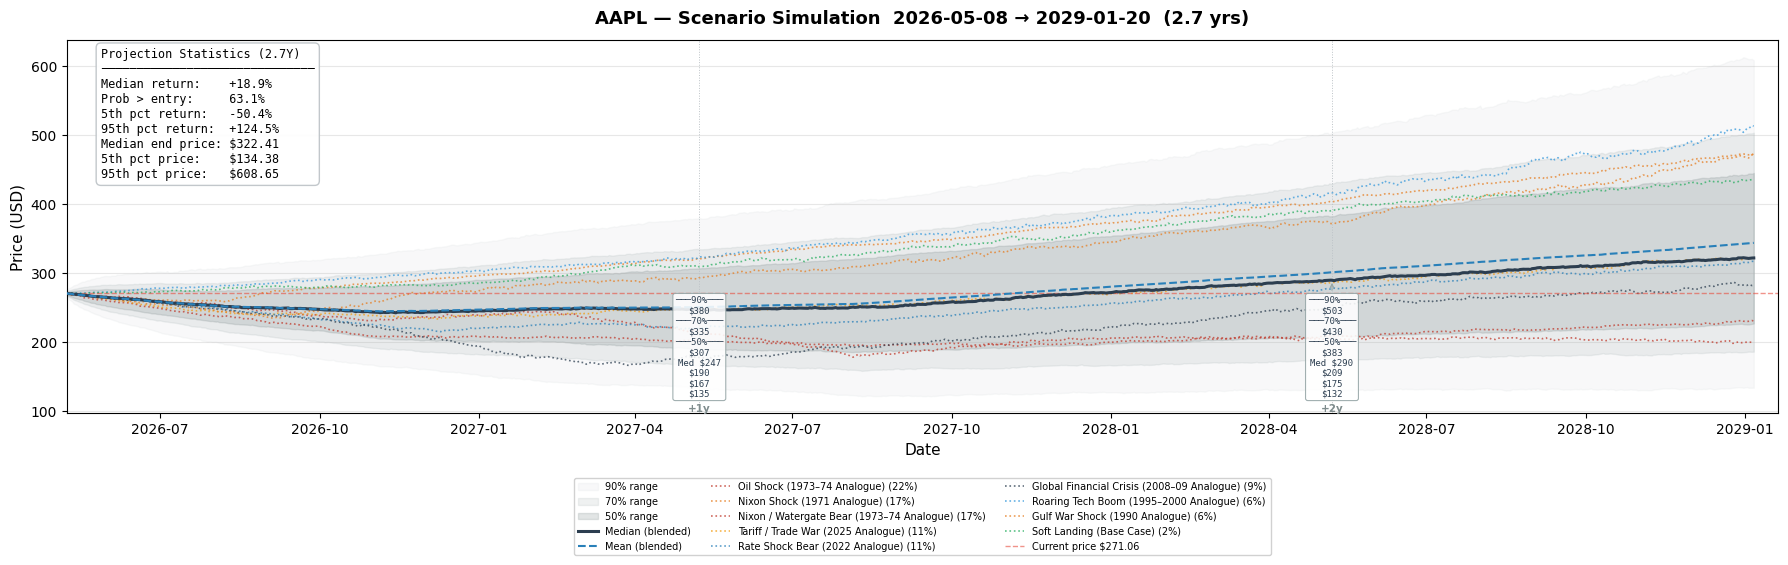

  ▶ CVX             $  185.21  β=0.64
  ✅  Chart saved → ./sim_output/usa/sim_CVX_4yr.png


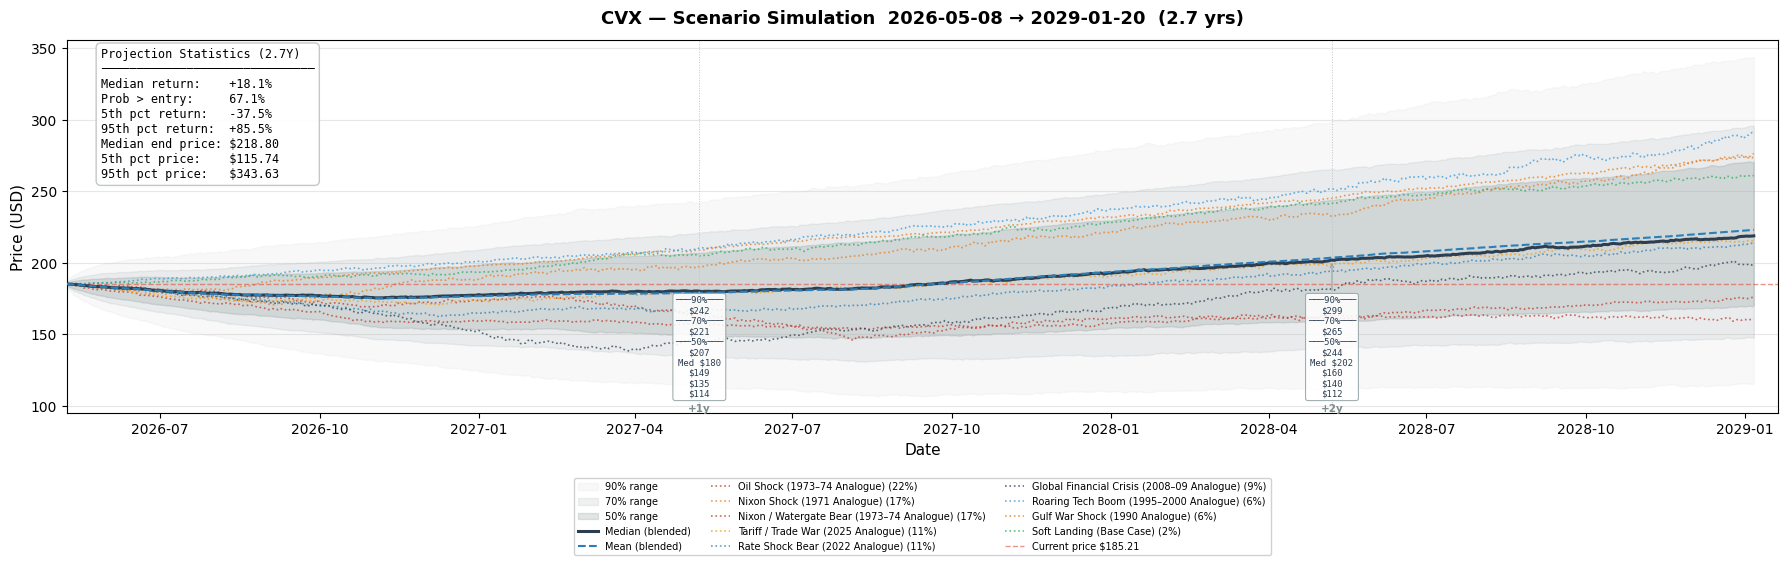

  ▶ GLD             $  433.25  β=0.45
  ✅  Chart saved → ./sim_output/usa/sim_GLD_4yr.png


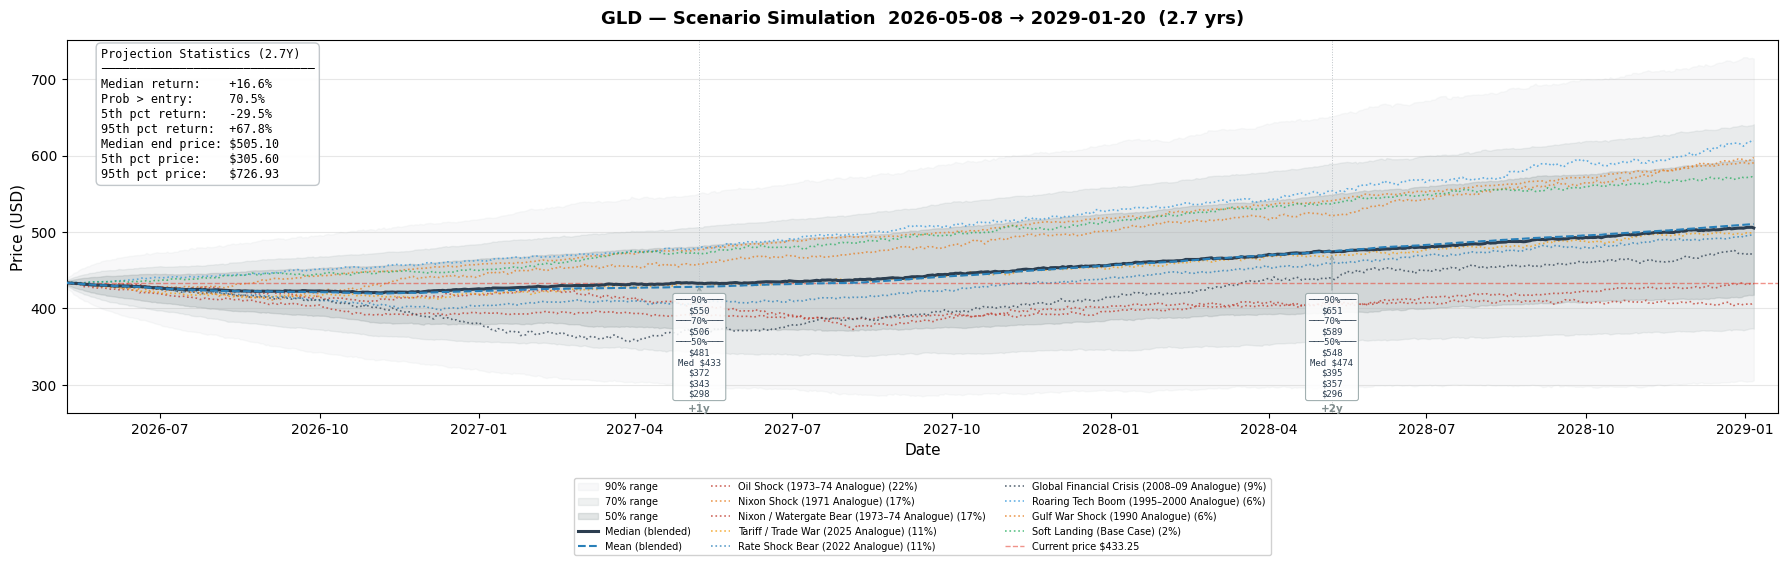

  ▶ IWM             $  276.65  β=1.08
  ✅  Chart saved → ./sim_output/usa/sim_IWM_4yr.png


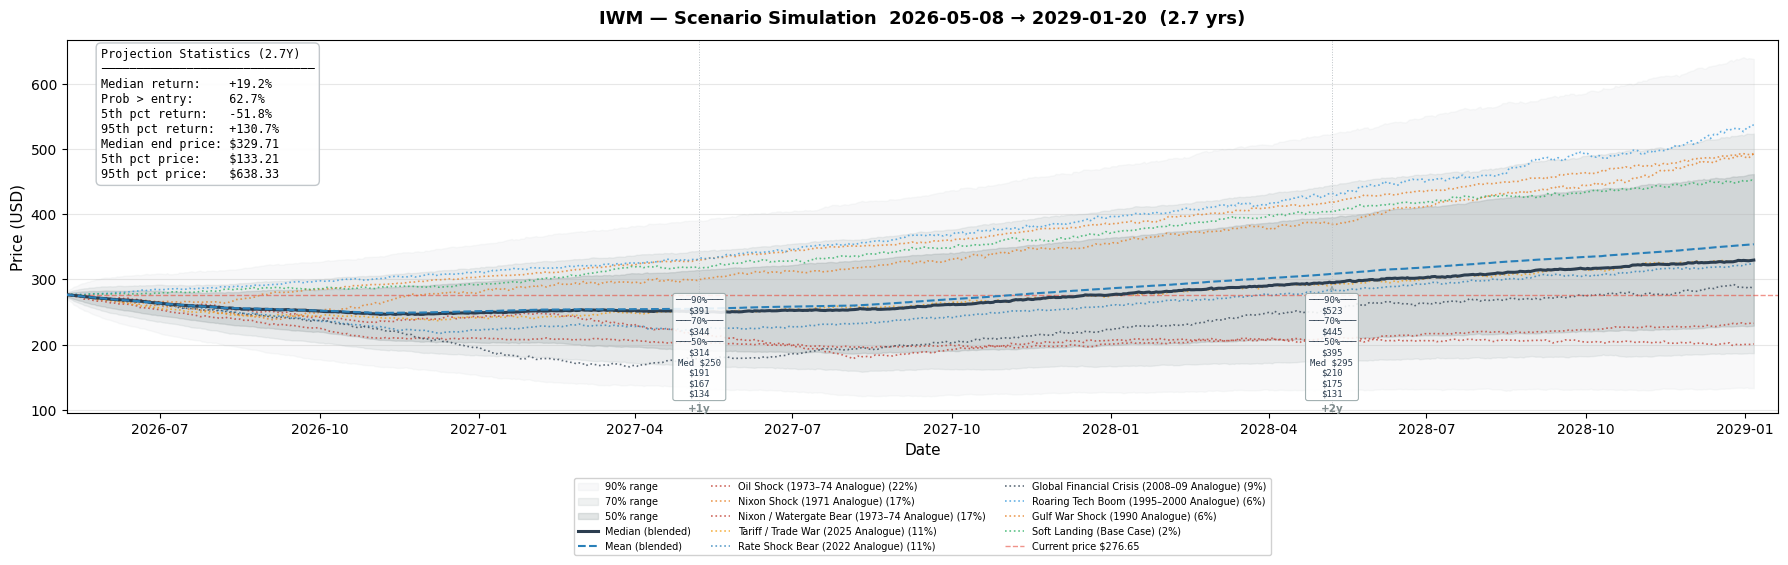

  ▶ MSFT            $  424.62  β=1.06
  ✅  Chart saved → ./sim_output/usa/sim_MSFT_4yr.png


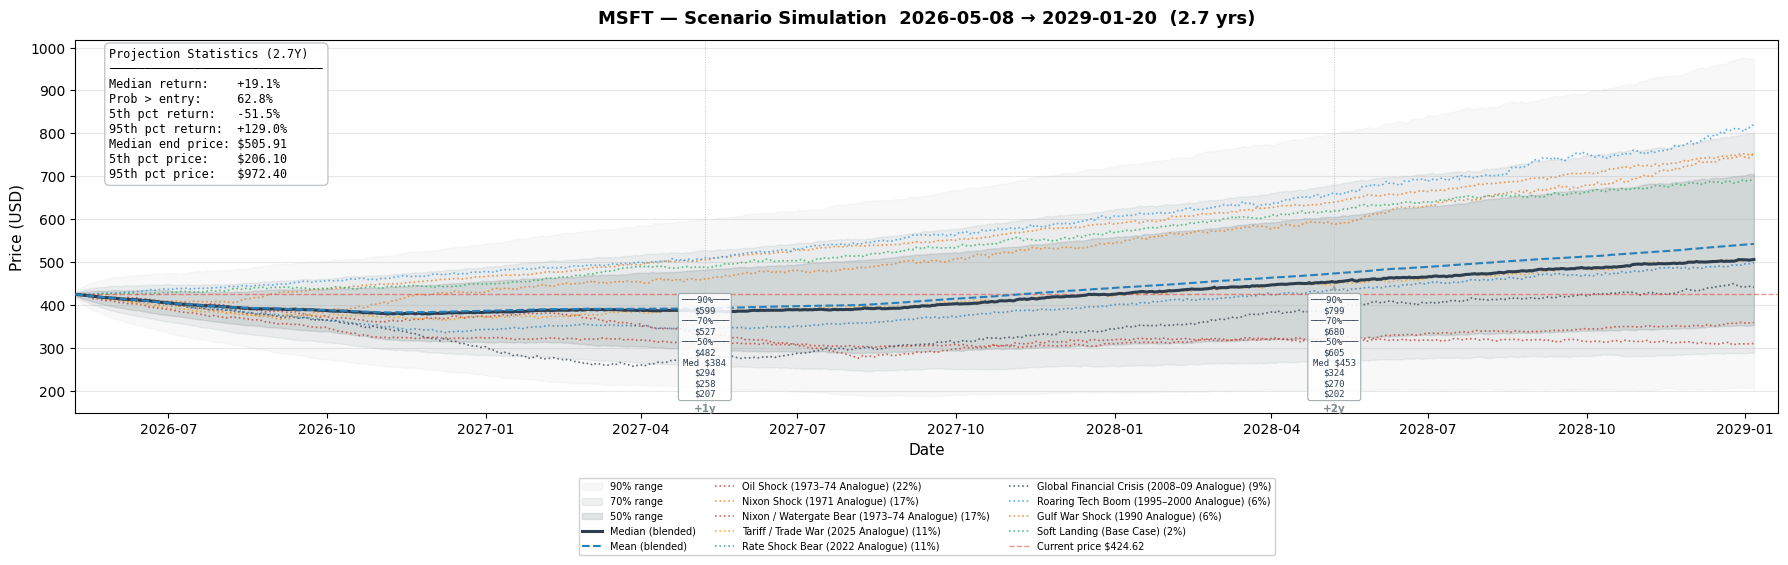

  ▶ NVDA            $  208.27  β=1.83
  ✅  Chart saved → ./sim_output/usa/sim_NVDA_4yr.png


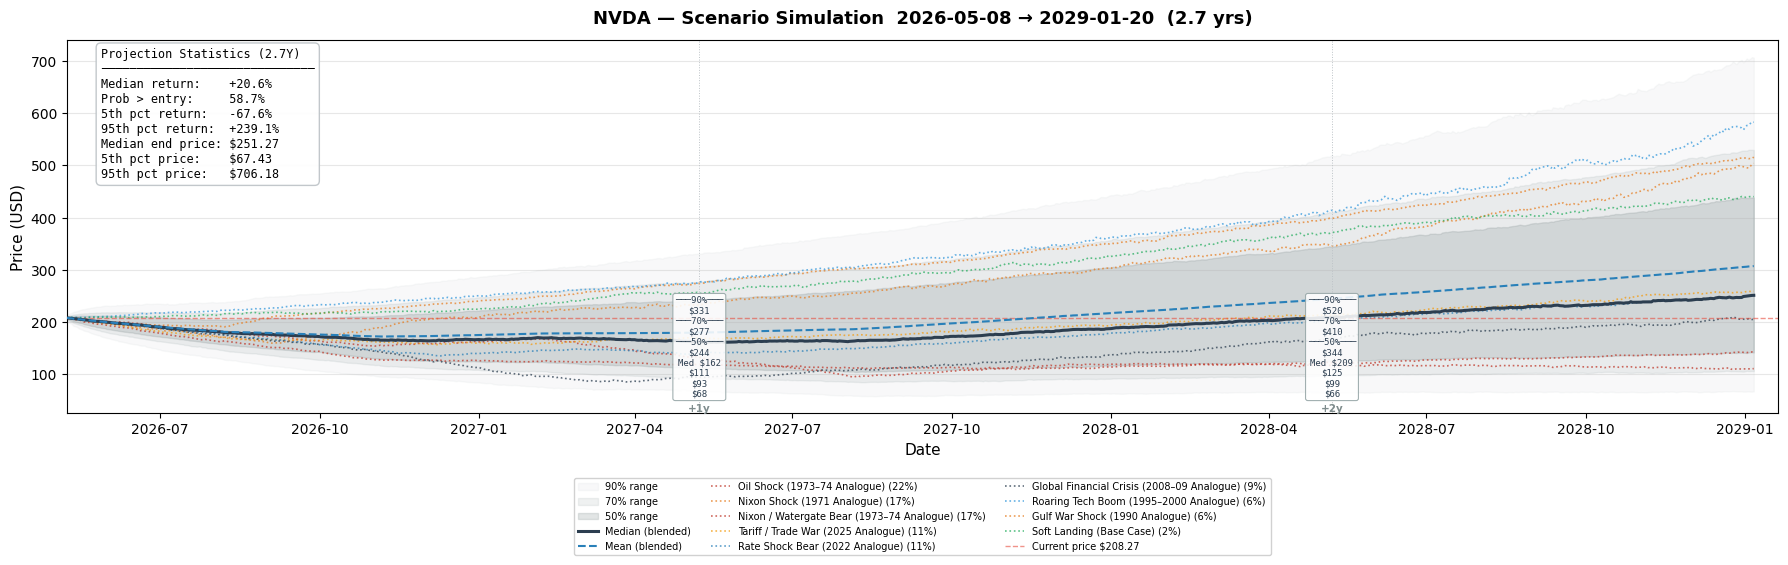

  ▶ QQQ             $  663.88  β=1.13
  ✅  Chart saved → ./sim_output/usa/sim_QQQ_4yr.png


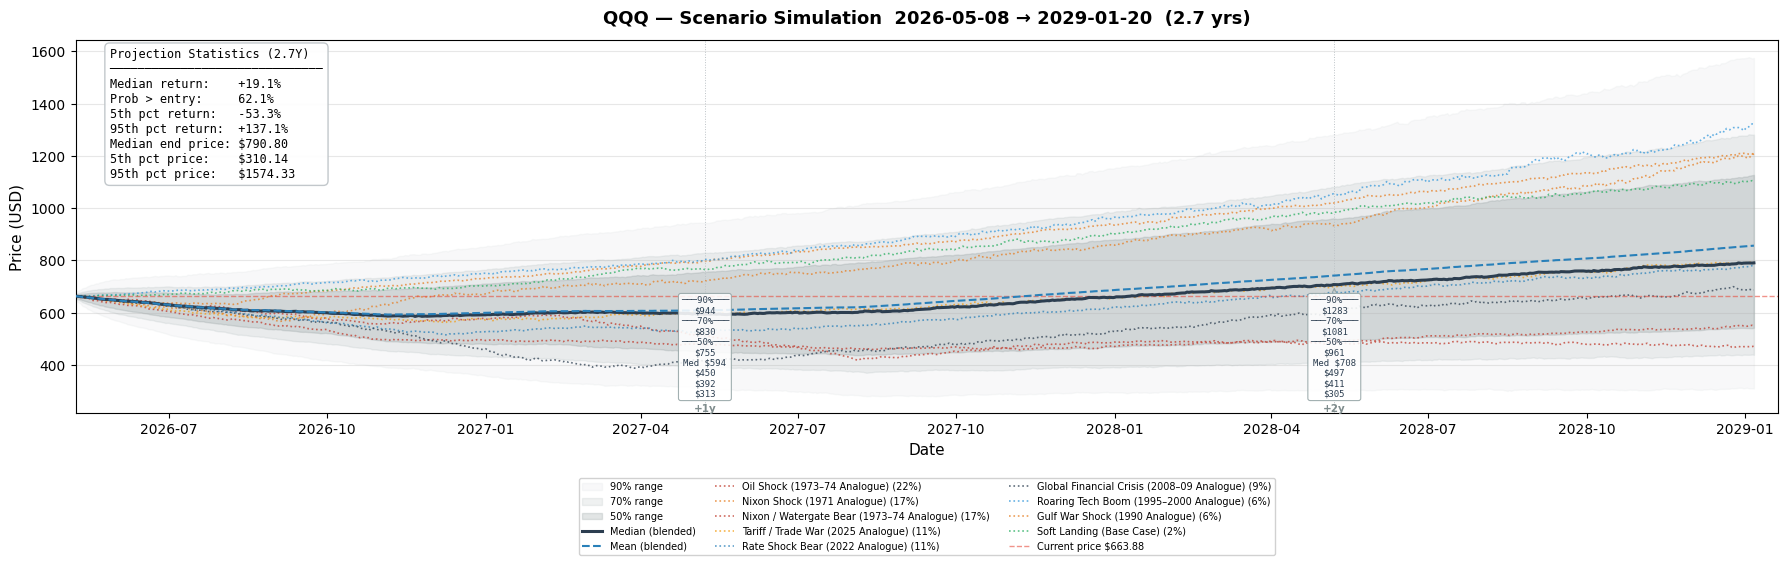

  ▶ SPY             $  713.94  β=1.00
  ✅  Chart saved → ./sim_output/usa/sim_SPY_4yr.png


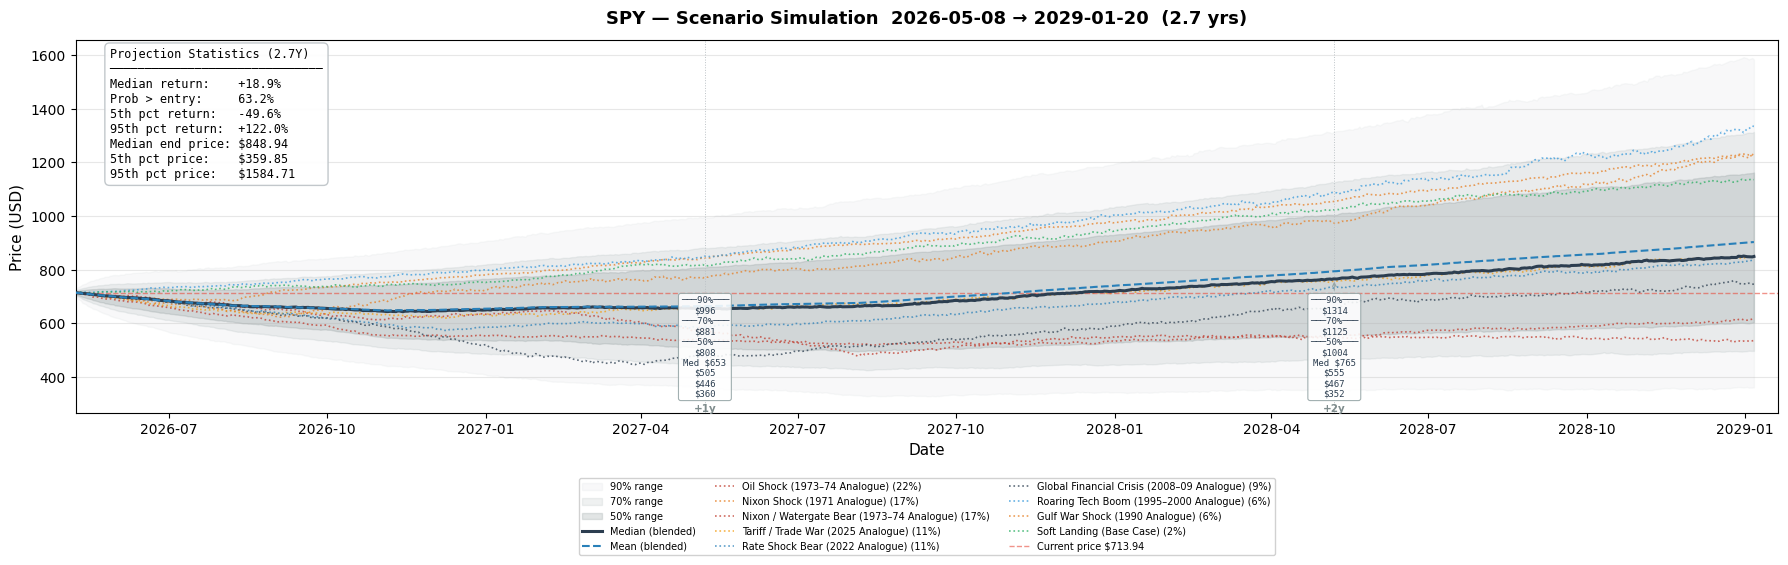

  ▶ TLT             $   86.71  β=0.68
  ✅  Chart saved → ./sim_output/usa/sim_TLT_4yr.png


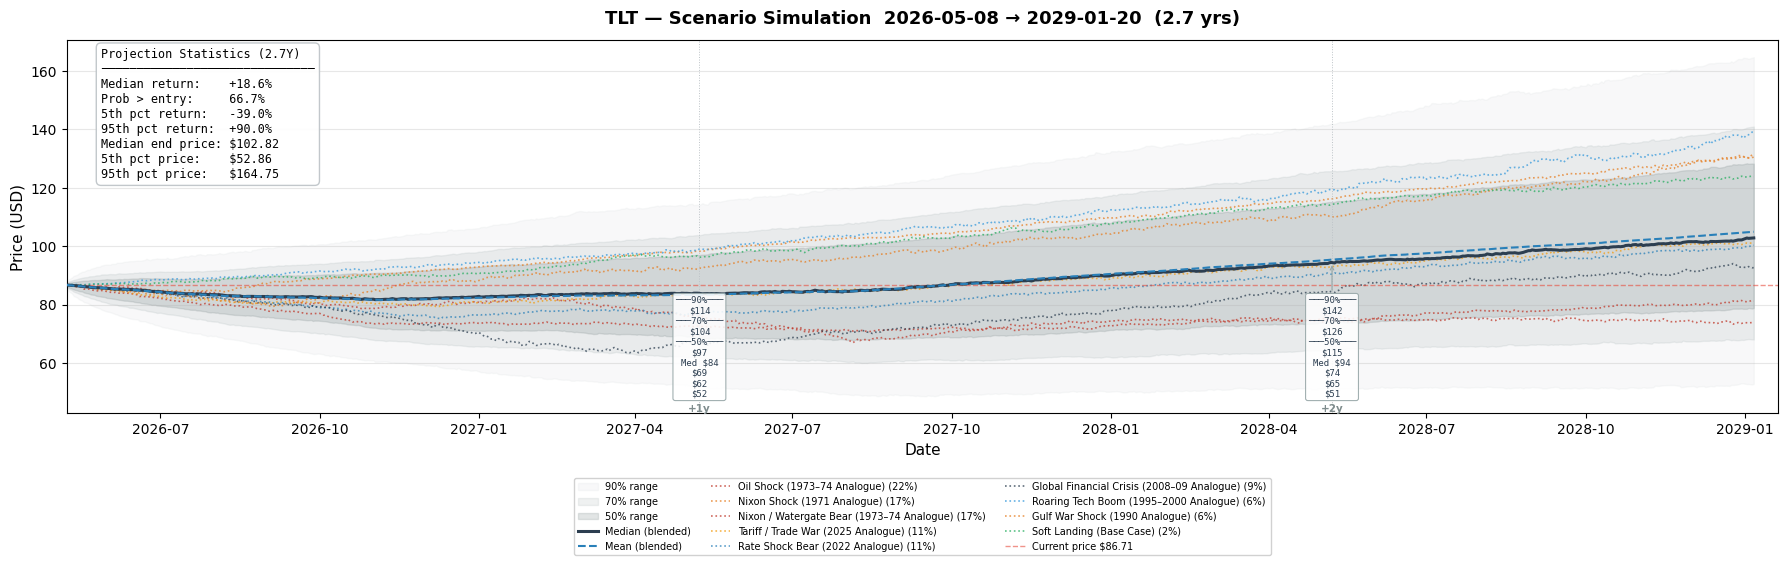

  ▶ TSM             $  402.46  β=1.26
  ✅  Chart saved → ./sim_output/usa/sim_TSM_4yr.png


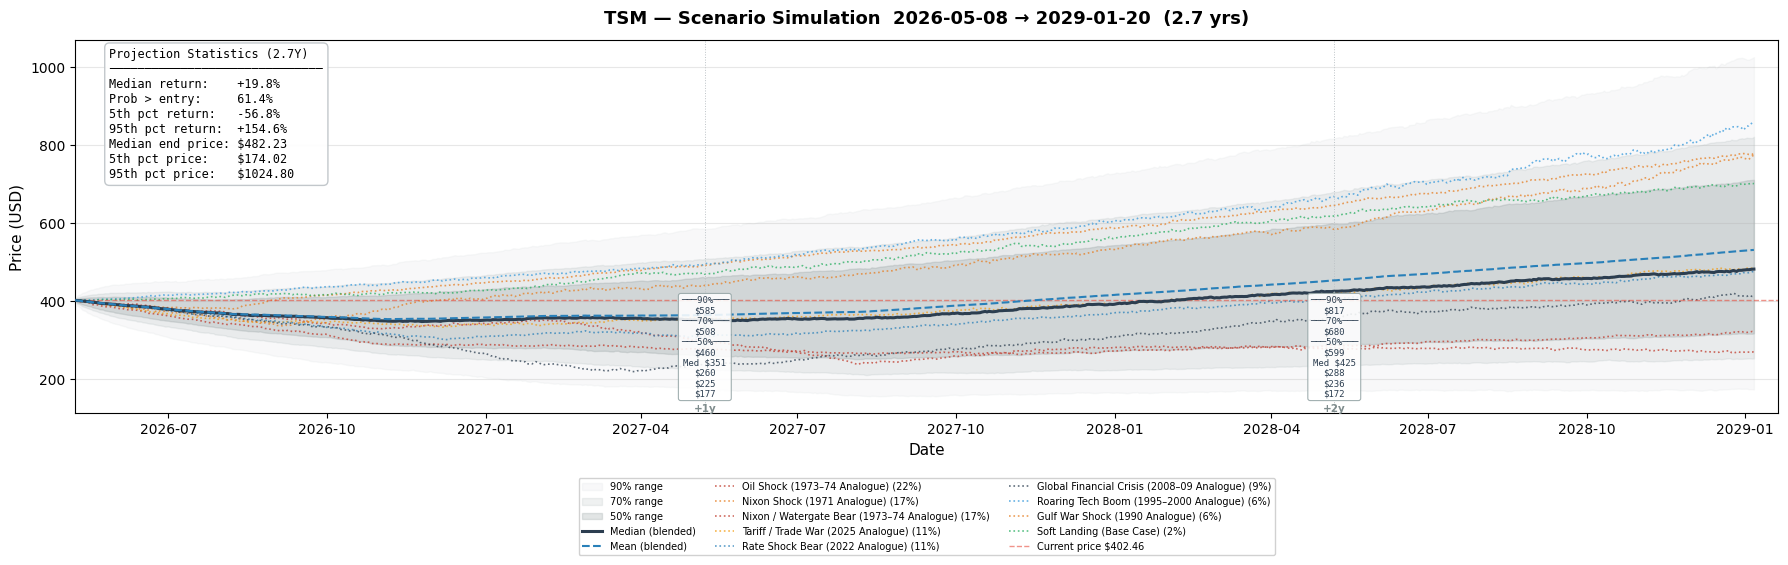

  ▶ XOM             $  148.91  β=0.43
  ✅  Chart saved → ./sim_output/usa/sim_XOM_4yr.png


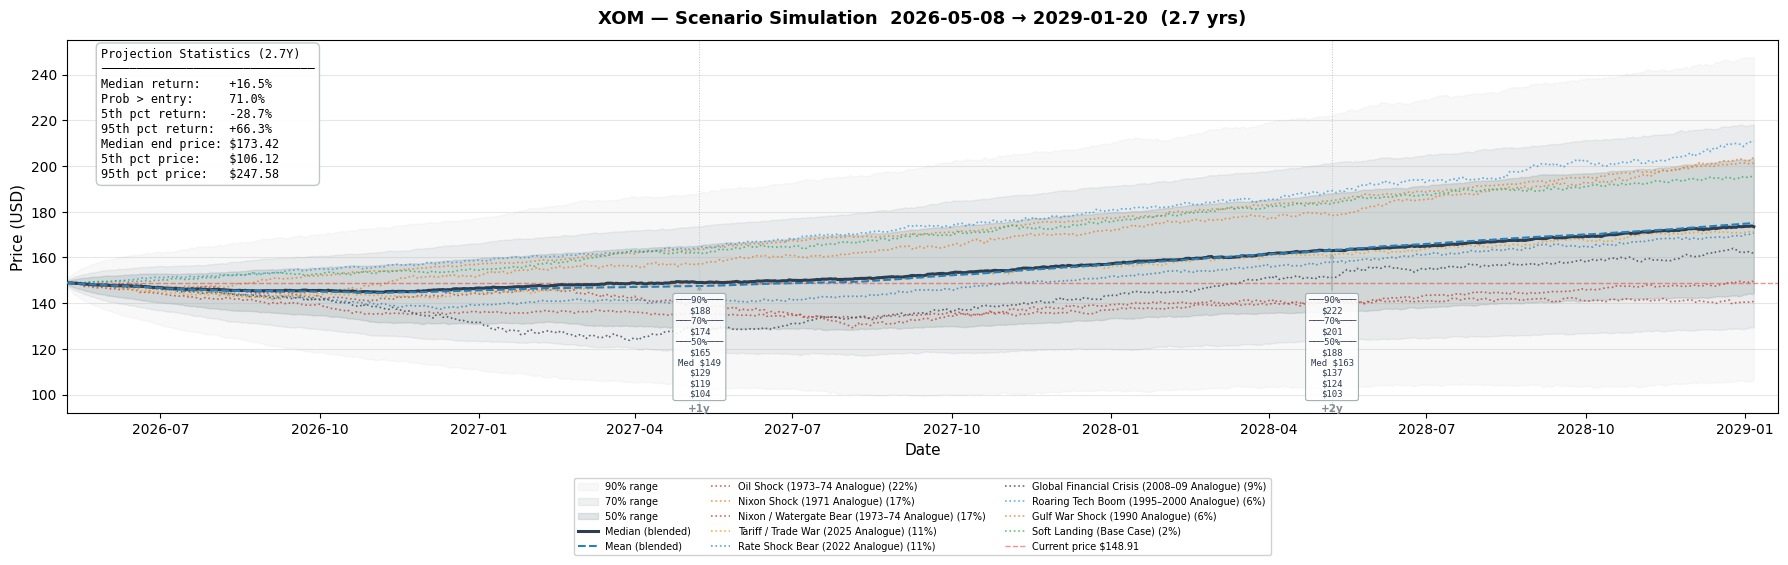


  📊 USA Projection Table


,nation,currency,projection_start,projection_end,current_usd,current_local,beta,1Y_exp,1Y_p50_low,1Y_p50_high,1Y_p70_low,1Y_p70_high,1Y_p90_low,1Y_p90_high,2Y_exp,2Y_p50_low,2Y_p50_high,2Y_p70_low,2Y_p70_high,2Y_p90_low,2Y_p90_high,1Y_bear,1Y_base,1Y_bull,2Y_bear,2Y_base,2Y_bull,top_scenarios
ticker,,,,,,,,,,,,,,,,,,,,,,,,,,,,
SPY,usa,USD,2026-05-08,2029-01-20,713.94,713.94,1.00,653.49,505.33,807.81,445.61,880.94,359.60,996.10,765.26,555.05,1003.56,466.91,1124.88,351.91,1314.16,505.33,653.49,807.81,555.05,765.26,1003.56,"oil_shock_1973:22%, nixon_shock_1971:17%, nixo..."
QQQ,usa,USD,2026-05-08,2029-01-20,663.88,663.88,1.13,594.00,449.69,755.12,392.44,829.98,312.96,944.44,707.91,497.19,961.16,411.41,1080.51,304.70,1283.13,449.69,594.00,755.12,497.19,707.91,961.16,"oil_shock_1973:22%, nixon_shock_1971:17%, nixo..."
GLD,usa,USD,2026-05-08,2029-01-20,433.25,433.25,0.45,432.71,371.97,480.64,343.42,505.94,298.38,550.30,473.69,394.69,548.40,356.72,589.29,296.28,650.80,371.97,432.71,480.64,394.69,473.69,548.40,"oil_shock_1973:22%, nixon_shock_1971:17%, nixo..."
MSFT,usa,USD,2026-05-08,2029-01-20,424.62,424.62,1.06,384.16,294.09,481.56,257.98,527.41,207.04,599.02,453.26,323.88,604.87,270.21,680.38,202.31,798.80,294.09,384.16,481.56,323.88,453.26,604.87,"oil_shock_1973:22%, nixon_shock_1971:17%, nixo..."
TSM,usa,USD,2026-05-08,2029-01-20,402.46,402.46,1.26,351.11,260.39,460.32,225.09,508.35,176.96,585.06,425.40,288.45,598.66,236.31,679.84,171.53,816.70,260.39,351.11,460.32,288.45,425.40,598.66,"oil_shock_1973:22%, nixon_shock_1971:17%, nixo..."
IWM,usa,USD,2026-05-08,2029-01-20,276.65,276.65,1.08,249.90,190.65,314.05,167.10,343.79,133.97,391.21,295.18,210.38,395.45,175.09,444.79,130.81,523.31,190.65,249.90,314.05,210.38,295.18,395.45,"oil_shock_1973:22%, nixon_shock_1971:17%, nixo..."
AAPL,usa,USD,2026-05-08,2029-01-20,271.06,271.06,1.03,246.89,190.04,307.24,167.20,335.06,134.59,380.37,290.25,208.86,382.84,175.12,429.71,131.62,503.18,190.04,246.89,307.24,208.86,290.25,382.84,"oil_shock_1973:22%, nixon_shock_1971:17%, nixo..."
NVDA,usa,USD,2026-05-08,2029-01-20,208.27,208.27,1.83,161.93,111.14,243.63,92.96,277.15,68.44,330.66,209.05,125.29,343.89,98.79,409.63,66.28,519.54,111.14,161.93,243.63,125.29,209.05,343.89,"oil_shock_1973:22%, nixon_shock_1971:17%, nixo..."
CVX,usa,USD,2026-05-08,2029-01-20,185.21,185.21,0.64,180.11,148.66,206.80,134.89,220.54,113.92,241.99,201.88,159.78,243.59,140.38,265.37,112.13,298.67,148.66,180.11,206.80,159.78,201.88,243.59,"oil_shock_1973:22%, nixon_shock_1971:17%, nixo..."



  ✅ Saved full table, including proxies and raw mixture weights → ./sim_output/usa/sim_usa_projection_table.csv



✅  All projections complete (charts + tables)


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 07 — BATCH SCENARIO PROJECTION + CLEAN TABLE OUTPUT
# ══════════════════════════════════════════════════════════════════════════════
# Notes:
#   • Scenario mixture weights are GLOBAL: one macro-state reconstruction applies
#     to every ticker in the run.
#   • Ticker-specific differences come from current price + beta. If you also run
#     the factor-regression cell, you get richer per-ticker proxy sensitivity.
#   • Probability bands are standard central intervals: 50% is narrowest,
#     70% is wider, 90% is widest.

weights_to_use = (adjusted_weights if "adjusted_weights" in dir() and adjusted_weights
                  else DEFAULT_WEIGHTS)

cal_scalars = compute_calibration_scalars(proxy_data if "proxy_data" in dir() else {})
RESULTS = {}

from IPython.display import display, HTML
import matplotlib.pyplot as plt
import ast

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1600)

print("Scenario weights in use — GLOBAL for all tickers in this run:")
for k, v in sorted(weights_to_use.items(), key=lambda x: -x[1]):
    print(f"  {k:<28} {v:.1%}  {'█'*int(v*50)}")
print()
print("Model interpretation:")
print("  current macro state ≈ weighted mixture of historical analogues from proxy signals")
print("  ticker projection   ≈ global analogue mixture × ticker beta × current price")
print()


def _nearest_idx(summary: pd.DataFrame, years: float) -> int:
    """Return row index nearest to projection_start + years."""
    target = pd.Timestamp(_PROJ_START + timedelta(days=365.25 * years))
    idx = int(np.argmin(np.abs(pd.to_datetime(summary.index) - target)))
    return max(0, min(idx, len(summary) - 1))


def extract_from_summary(summary: pd.DataFrame, idx: int) -> dict:
    row = summary.iloc[idx]

    p5  = row["p5"]
    p15 = row.get("p15", np.nan)
    p25 = row["p25"]
    p50 = row["p50"]
    p75 = row["p75"]
    p85 = row.get("p85", np.nan)
    p95 = row["p95"]

    # 50% central interval = p25–p75
    # 70% central interval = p15–p85 when available; otherwise interpolate
    # 90% central interval = p5–p95
    p50_low, p50_high = p25, p75
    p70_low  = p15 if pd.notna(p15) else (p25 + p5) / 2
    p70_high = p85 if pd.notna(p85) else (p75 + p95) / 2
    p90_low, p90_high = p5, p95

    assert p90_low <= p70_low <= p50_low, "Lower-band ordering failed: expected p90 <= p70 <= p50."
    assert p50_high <= p70_high <= p90_high, "Upper-band ordering failed: expected p50 <= p70 <= p90."

    return {
        "exp": float(p50),
        "p50_low": float(p50_low), "p50_high": float(p50_high),
        "p70_low": float(p70_low), "p70_high": float(p70_high),
        "p90_low": float(p90_low), "p90_high": float(p90_high),
    }


def compress_weights(w: dict, n: int = 3) -> str:
    top = sorted(w.items(), key=lambda x: -x[1])[:n]
    return ", ".join([f"{k}:{v:.0%}" for k, v in top])


proxies_used_str = ", ".join([f"{role}={sym}" for role, sym in _PROXIES.items()])

for nation, px_usd in LIVE_PRICES.items():
    flag = FLAGS.get(nation, "🏳")
    beta_s = LIVE_BETAS.get(nation, pd.Series(dtype=float))
    ndir = os.path.join(_SAVE_DIR, nation)
    os.makedirs(ndir, exist_ok=True)

    print(f"\n{'═'*60}\n  {flag}  {nation.upper()} — {len(px_usd)} tickers\n{'═'*60}")

    rows = []

    for ticker, price in px_usd.items():
        if pd.isna(price) or price <= 0:
            continue

        beta = float(beta_s.get(ticker, 1.0))
        print(f"  ▶ {ticker:<14}  ${price:>8.2f}  β={beta:.2f}")

        summary = run_blended_simulation(
            ticker,
            price,
            weights_to_use,
            beta,
            n_paths=_N_PATHS,
            save_dir=ndir,
            show_plot=True,
            cal_scalars=cal_scalars,
        )
        plt.close('all')

        idx_1y = _nearest_idx(summary, 1.0)
        idx_2y = _nearest_idx(summary, 2.0)

        stats_1y = extract_from_summary(summary, idx_1y)
        stats_2y = extract_from_summary(summary, idx_2y)

        rows.append({
            "ticker": ticker,
            "nation": nation,
            "currency": _MARKETS[nation]["currency"],
            "projection_start": _PROJ_START.strftime("%Y-%m-%d"),
            "projection_end": _PROJ_END.strftime("%Y-%m-%d"),
            "current_usd": price,
            "current_local": price * LIVE_FX.get(nation, 1.0),
            "beta": beta,
            "weight_scope": "global_macro_mixture_same_for_all_tickers",
            "proxies_used": proxies_used_str,

            "1Y_exp": stats_1y["exp"],
            "1Y_p50_low": stats_1y["p50_low"], "1Y_p50_high": stats_1y["p50_high"],
            "1Y_p70_low": stats_1y["p70_low"], "1Y_p70_high": stats_1y["p70_high"],
            "1Y_p90_low": stats_1y["p90_low"], "1Y_p90_high": stats_1y["p90_high"],

            "2Y_exp": stats_2y["exp"],
            "2Y_p50_low": stats_2y["p50_low"], "2Y_p50_high": stats_2y["p50_high"],
            "2Y_p70_low": stats_2y["p70_low"], "2Y_p70_high": stats_2y["p70_high"],
            "2Y_p90_low": stats_2y["p90_low"], "2Y_p90_high": stats_2y["p90_high"],

            # --- INTERPRETABLE STATES ---
"1Y_bear": stats_1y["p50_low"],   # realistic downside
"1Y_base": stats_1y["exp"],       # expected
"1Y_bull": stats_1y["p50_high"],  # realistic upside

"2Y_bear": stats_2y["p50_low"],
"2Y_base": stats_2y["exp"],
"2Y_bull": stats_2y["p50_high"],

            "top_scenarios": compress_weights(weights_to_use, 3),
            "mixture_weights": str(weights_to_use),
        })

    df = pd.DataFrame(rows).set_index("ticker")
    RESULTS[nation] = df

    out_path = os.path.join(ndir, f"sim_{nation}_projection_table.csv")
    df.to_csv(out_path)

    print(f"\n  📊 {nation.upper()} Projection Table")

    df_display = df.copy()
    drop_for_display = ["mixture_weights", "proxies_used", "weight_scope"]
    df_display = df_display.drop(columns=[c for c in drop_for_display if c in df_display.columns])

    num_cols = df_display.select_dtypes(include="number").columns
    df_display[num_cols] = df_display[num_cols].round(2)
    df_display = df_display.sort_values("2Y_exp", ascending=False)
    display(df_display)

    print(f"\n  ✅ Saved full table, including proxies and raw mixture weights → {out_path}")
    display(HTML("<br><hr style='height:3px;border:none;background:#ccc;'><br>"))

print("\n✅  All projections complete (charts + tables)")


## Cell 08 — 🔬 All-scenario grids  *(every ticker × every scenario)*

One subplot per scenario for each ticker. Faster than Cell 07 (uses N_PATHS÷5).

## Cell 08B — Historical reconstruction / backcast

This cell answers: “What target price would the model have implied in the past?”

It rolls backward through historical dates, reconstructs the macro state from the same proxy roles, derives a global historical-analogue mixture for that date, and then produces 1Y/2Y median target prices from that historical starting point. This is a **backcast**, not a true out-of-sample forecast unless the proxy data is strictly available at each historical date.

Important interpretation:
- The **scenario mixture is macro-level and shared across tickers** for each evaluation date.
- Tickers differ by their historical price at that date and beta.
- The output compares model-implied 1Y/2Y target prices with the future realized prices when those future observations are available.


Synced SENS_TICKERS from SIM_CONFIG: ['SPY', 'QQQ', 'IWM', 'NVDA', 'AAPL', 'MSFT', 'TSM', 'XOM', 'CVX', 'GLD', 'TLT']

🧪 TICKER × 18-PROXY SENSITIVITY + HISTORICAL EVENT PSEUDO TARGETS
Tickers      : ['SPY', 'QQQ', 'IWM', 'NVDA', 'AAPL', 'MSFT', 'TSM', 'XOM', 'CVX', 'GLD', 'TLT']
Fit window   : 2019-01-01 → latest
Regression   : RIDGE | standardized=False
Proxy count  : 18
Available proxy roles: 18 / 18
market=SPY, tech=QQQ, small_cap=IWM, volatility=^VIX, tbill=SGOV, short_bond=SHY, long_bond=TLT, credit_ig=LQD, credit_hy=HYG, credit_em=EMB, tips=TIP, commodity=PDBC, usd=UUP, discretionary=XLY, staples=XLP, financials=XLF, gold=GLD, oil=USO

✅ Ticker sensitivity table


,alpha_daily,r2,n_obs,regression,standardized,market,tech,small_cap,volatility,tbill,short_bond,long_bond,credit_ig,credit_hy,credit_em,tips,commodity,usd,discretionary,staples,financials,gold,oil
ticker,,,,,,,,,,,,,,,,,,,,,,,
SPY,0.0008,0.6111,1482,ridge,False,0.0191,0.0239,0.0201,-0.0574,-0.0,0.0002,0.0009,0.0035,0.0063,0.0061,0.0013,0.0043,-0.0023,0.0224,0.0086,0.0164,0.0026,0.0055
QQQ,0.0009,0.5263,1482,ridge,False,0.0239,0.0372,0.0219,-0.0695,-0.0,0.0003,0.0025,0.0049,0.0077,0.0077,0.0018,0.0032,-0.0028,0.0308,0.0067,0.0126,0.0040,0.0023
IWM,0.0007,0.5122,1482,ridge,False,0.0201,0.0219,0.0393,-0.0686,-0.0,0.0003,0.0010,0.0044,0.0081,0.0076,0.0017,0.0066,-0.0034,0.0266,0.0080,0.0238,0.0039,0.0090
NVDA,0.0028,0.2881,1482,ridge,False,0.0392,0.0683,0.0309,-0.1166,0.0,0.0000,0.0038,0.0071,0.0119,0.0120,0.0018,0.0049,-0.0043,0.0458,-0.0007,0.0115,0.0054,0.0042
AAPL,0.0011,0.3023,1482,ridge,False,0.0247,0.0373,0.0194,-0.0669,-0.0,0.0003,0.0031,0.0052,0.0078,0.0077,0.0020,0.0026,-0.0026,0.0294,0.0107,0.0127,0.0025,0.0027
MSFT,0.0008,0.2961,1482,ridge,False,0.0231,0.0369,0.0149,-0.0610,0.0,0.0003,0.0017,0.0043,0.0070,0.0067,0.0016,0.0027,-0.0025,0.0264,0.0064,0.0100,0.0025,0.0016
TSM,0.0019,0.2460,1482,ridge,False,0.0246,0.0401,0.0262,-0.0828,0.0,-0.0001,-0.0006,0.0036,0.0075,0.0076,0.0002,0.0067,-0.0045,0.0286,-0.0007,0.0106,0.0091,0.0048
XOM,0.0011,0.1784,1482,ridge,False,0.0104,0.0011,0.0201,-0.0330,-0.0,-0.0004,-0.0076,-0.0014,0.0037,0.0015,0.0007,0.0301,-0.0012,0.0060,0.0080,0.0232,0.0034,0.0589
CVX,0.0007,0.1880,1482,ridge,False,0.0116,0.0038,0.0202,-0.0362,-0.0,-0.0004,-0.0063,-0.0006,0.0042,0.0023,0.0009,0.0254,-0.0009,0.0081,0.0076,0.0224,0.0020,0.0499



✅ Event proxy movement table


,start,end,actual_proxy_count,market,tech,small_cap,volatility,tbill,short_bond,long_bond,credit_ig,credit_hy,credit_em,tips,commodity,usd,discretionary,staples,financials,gold,oil
event,,,,,,,,,,,,,,,,,,,,,
oil_shock_1973,1973-01-01,1975-06-30,0,-0.081,-0.081,-0.081,0.065,0.020,0.008,-0.250,-0.024,-0.045,-0.041,0.050,0.800,-0.100,-0.081,-0.037,-0.081,0.650,0.800
nixon_shock_1971,1971-08-01,1972-12-31,0,0.757,0.757,0.757,-0.150,0.020,-0.076,-0.189,0.227,0.416,0.378,0.050,0.150,-0.150,0.757,0.340,0.757,0.350,0.050
nixon_watergate_1973,1973-01-01,1974-12-31,0,-0.201,-0.201,-0.201,0.161,0.020,0.020,-0.250,-0.060,-0.111,-0.101,0.050,0.800,-0.100,-0.201,-0.091,-0.201,0.650,0.800
gulf_war_1990,1990-08-01,1991-06-30,0,1.037,1.037,1.037,-0.150,0.020,-0.104,-0.259,0.311,0.571,0.519,0.050,0.050,0.050,1.037,0.467,1.037,0.120,0.350
roaring_tech_boom_1990s,1995-01-01,2000-03-01,0,1.200,2.200,0.900,-0.150,0.020,-0.140,-0.100,0.420,0.769,0.699,0.050,0.050,0.200,1.399,0.629,1.399,-0.250,-0.100
gfc_2008,2007-10-01,2010-12-31,0,-0.450,-0.350,-0.500,-0.150,0.020,-0.050,0.250,-0.100,-0.250,0.252,0.050,0.050,0.150,0.504,0.227,-0.700,0.150,0.050
covid_crash_2020,2020-02-01,2021-06-30,18,0.354,0.607,0.438,-0.119,0.001,0.023,0.012,0.065,0.077,0.027,0.104,0.349,-0.060,0.435,0.152,0.258,0.116,-0.406
rate_shock_2022,2022-01-01,2023-12-31,18,0.026,0.034,-0.083,-0.250,0.068,0.002,-0.274,-0.092,-0.007,-0.091,-0.084,0.113,0.127,-0.135,-0.016,-0.010,0.136,0.216
soft_landing,2023-01-01,2024-06-30,18,0.460,0.829,0.194,-0.457,0.079,0.052,-0.048,0.072,0.139,0.117,0.042,0.016,0.102,0.439,0.074,0.230,0.257,0.177



✅ Pseudo target prices by ticker × event


,ticker,event,current_price,pseudo_event_return_%,pseudo_target_price,actual_proxy_count,top_positive_proxy,top_positive_contrib_%,top_negative_proxy,top_negative_contrib_%
46,AAPL,covid_crash_2020,271.06,6.72,289.27,18,tech,2.26,oil,-0.11
45,AAPL,gfc_2008,271.06,-1.49,267.02,0,discretionary,1.48,tech,-1.30
43,AAPL,gulf_war_1990,271.06,15.38,312.74,0,tech,3.87,long_bond,-0.08
41,AAPL,nixon_shock_1971,271.06,11.58,302.44,0,tech,2.82,long_bond,-0.06
42,AAPL,nixon_watergate_1973,271.06,-3.31,262.08,0,oil,0.22,volatility,-1.08
...,...,...,...,...,...,...,...,...,...,...
70,XOM,oil_shock_1973,148.91,6.78,159.01,0,oil,4.71,volatility,-0.21
77,XOM,rate_shock_2022,148.91,2.41,152.50,18,oil,1.27,small_cap,-0.17
74,XOM,roaring_tech_boom_1990s,148.91,8.25,161.19,0,financials,3.25,oil,-0.59
78,XOM,soft_landing,148.91,4.58,155.73,18,volatility,1.51,usd,-0.01



✅ Proxy contribution detail


,ticker,event,proxy_role,proxy_symbol,sensitivity,event_proxy_move_%,contribution_%
829,AAPL,covid_crash_2020,tech,QQQ,0.0373,60.6763,2.2622
841,AAPL,covid_crash_2020,discretionary,XLY,0.0294,43.4962,1.2795
828,AAPL,covid_crash_2020,market,SPY,0.0247,35.4169,0.8759
830,AAPL,covid_crash_2020,small_cap,IWM,0.0194,43.8070,0.8508
831,AAPL,covid_crash_2020,volatility,^VIX,-0.0669,-11.9087,0.7963
...,...,...,...,...,...,...,...
1426,XOM,tariff_shock_2025,tbill,SGOV,-0.0000,3.5012,-0.0001
1427,XOM,tariff_shock_2025,short_bond,SHY,-0.0004,3.7251,-0.0015
1429,XOM,tariff_shock_2025,credit_ig,LQD,-0.0014,4.4580,-0.0061
1436,XOM,tariff_shock_2025,staples,XLP,0.0080,-4.4518,-0.0357



✅ Saved:
  sensitivity table     → ./sim_output/ticker_proxy_sensitivity_18proxies.csv
  event proxy moves     → ./sim_output/event_proxy_moves_18proxies.csv
  pseudo targets        → ./sim_output/pseudo_event_target_prices.csv
  proxy contributions   → ./sim_output/pseudo_event_proxy_contributions.csv

📊 SPY pseudo target chart


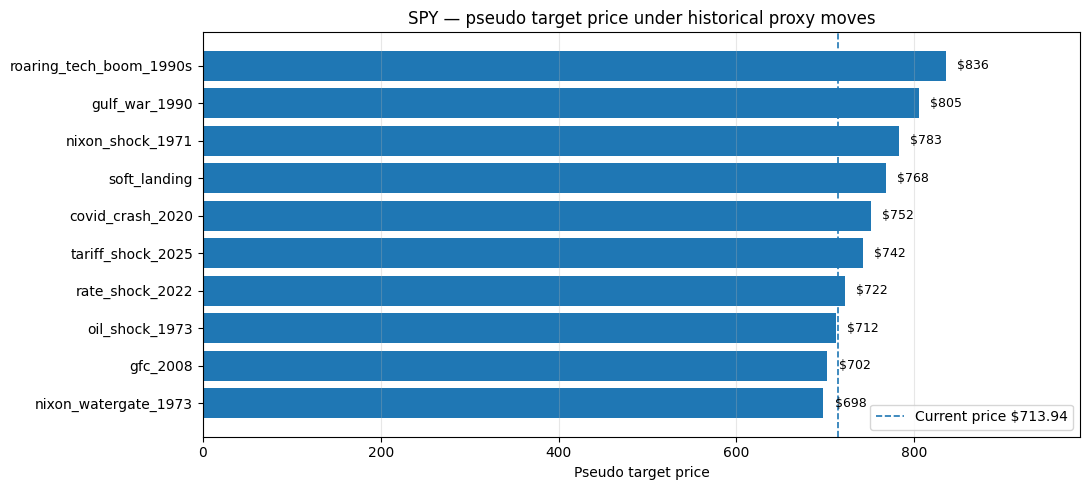


📊 QQQ pseudo target chart


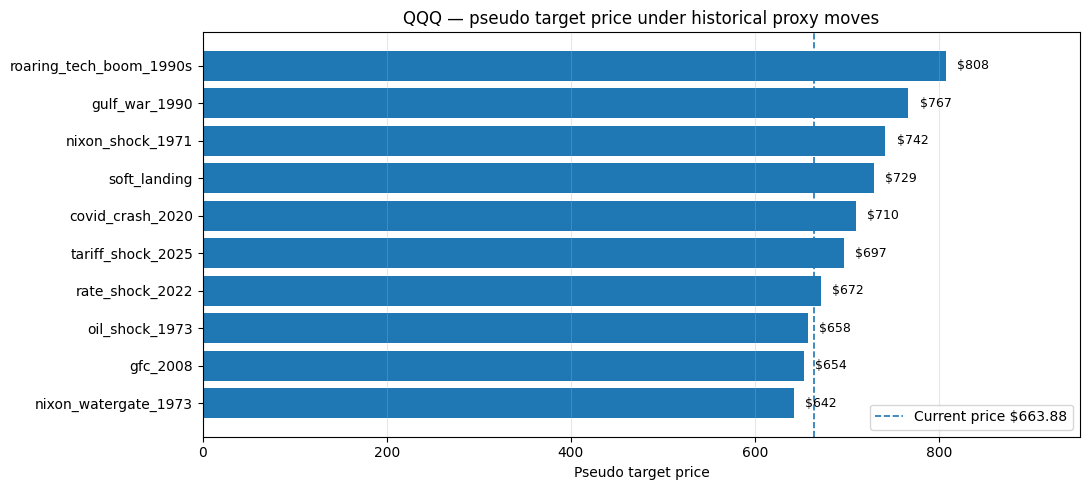


📊 IWM pseudo target chart


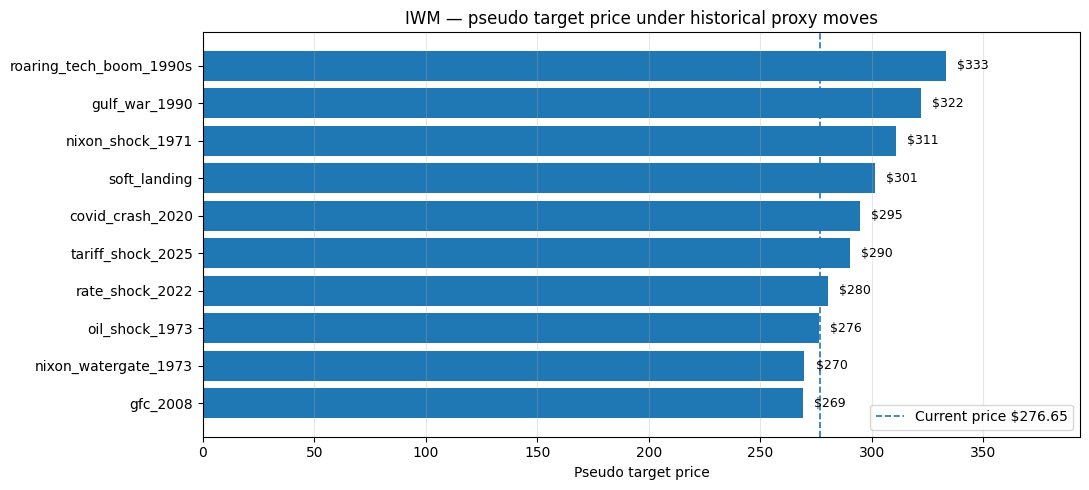


📊 NVDA pseudo target chart


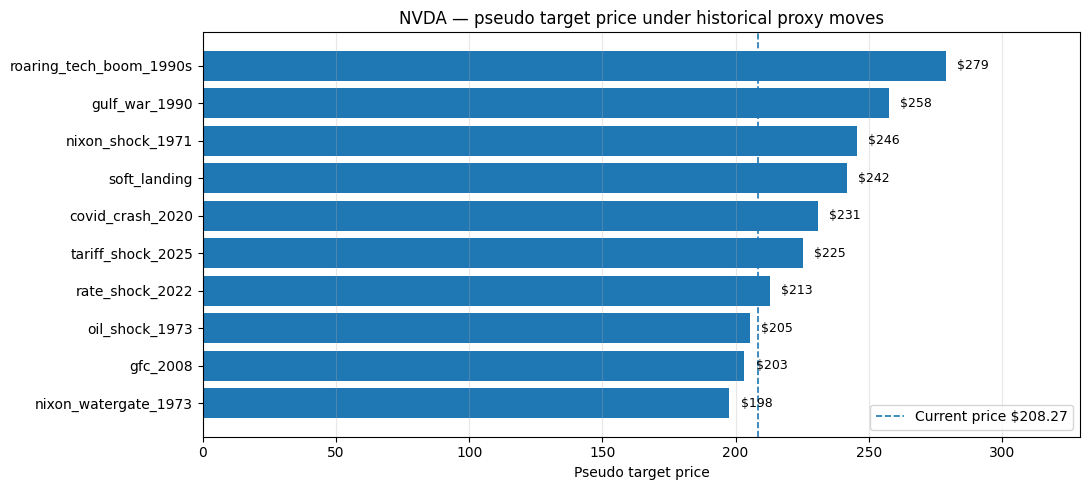


📊 AAPL pseudo target chart


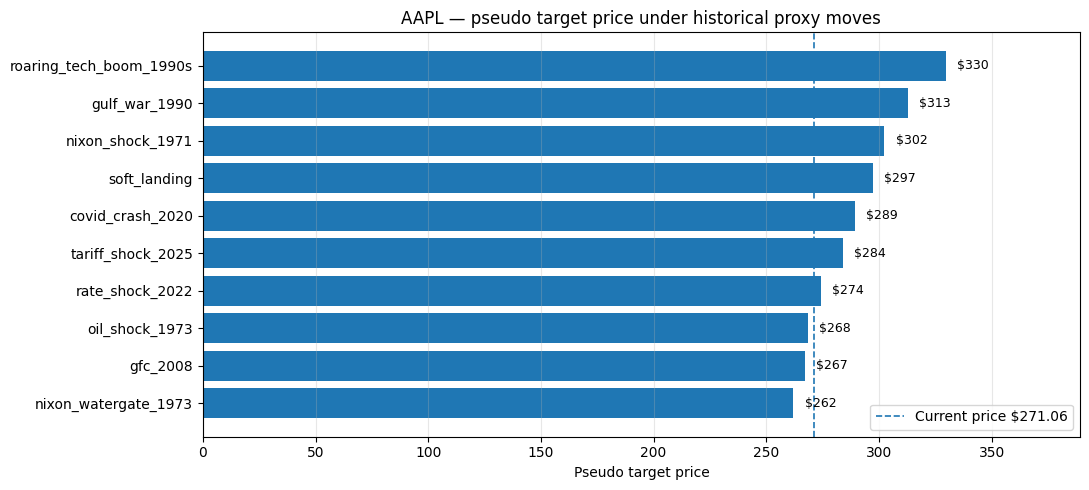


📊 MSFT pseudo target chart


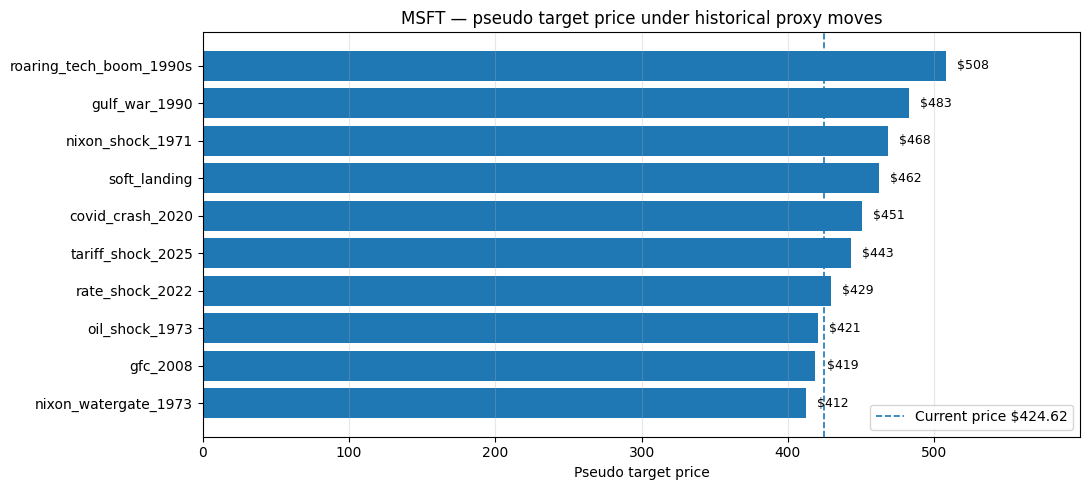


📊 TSM pseudo target chart


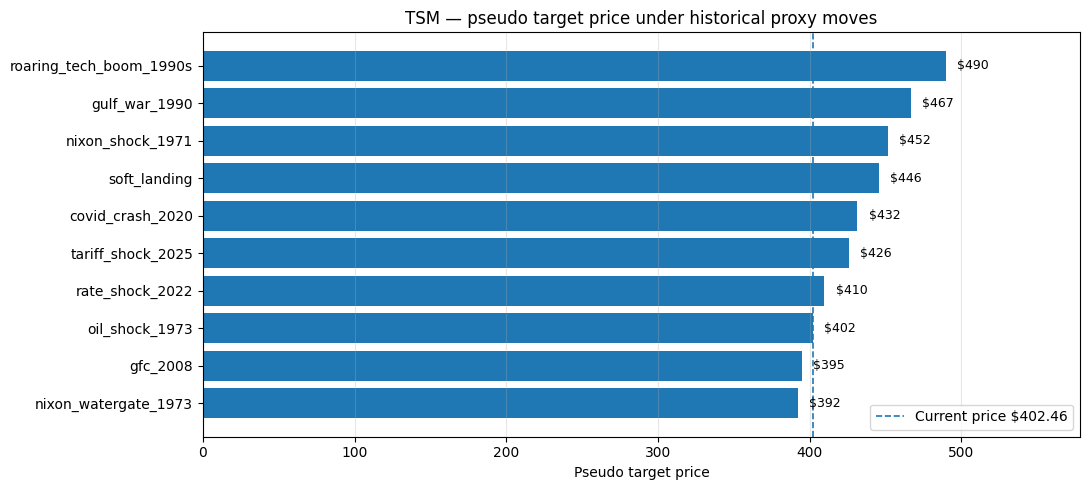


📊 XOM pseudo target chart


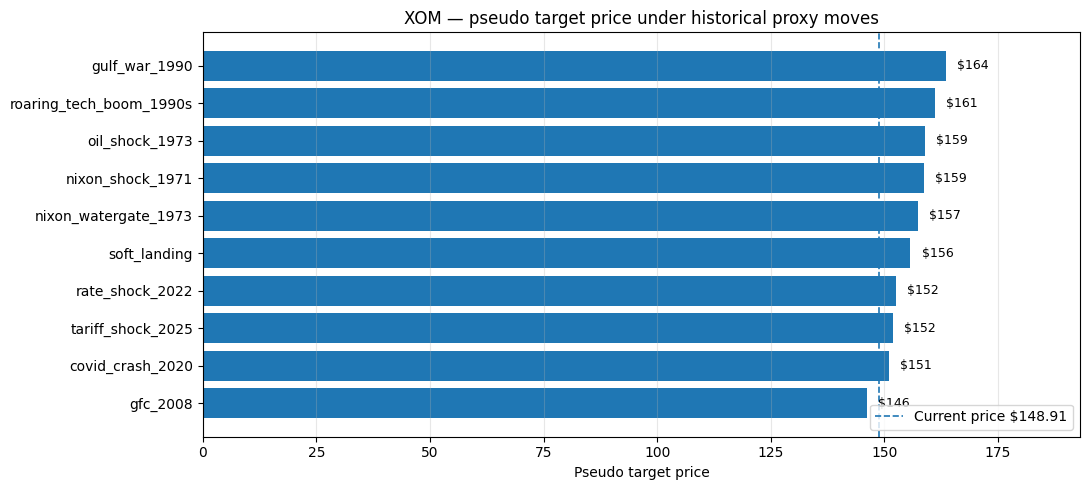


📊 CVX pseudo target chart


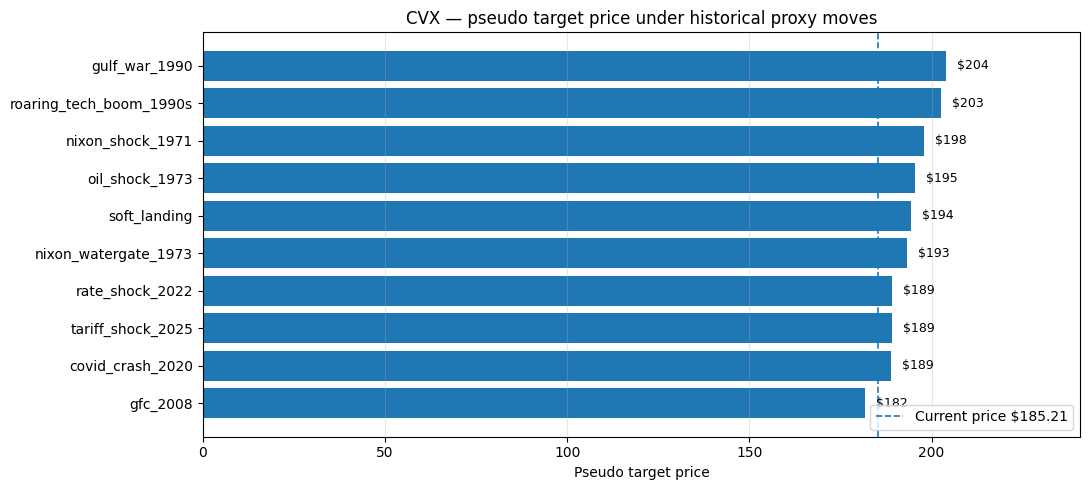


📊 GLD pseudo target chart


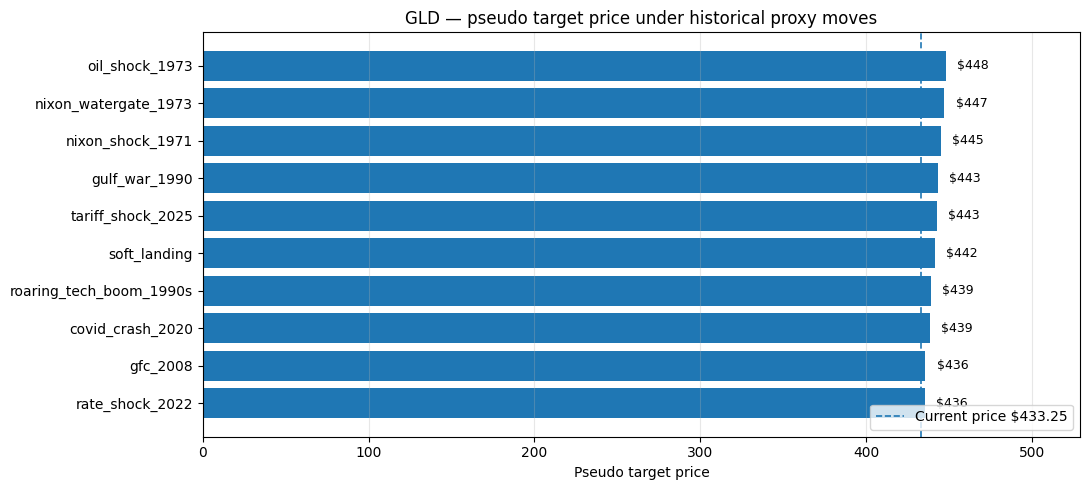


📊 TLT pseudo target chart


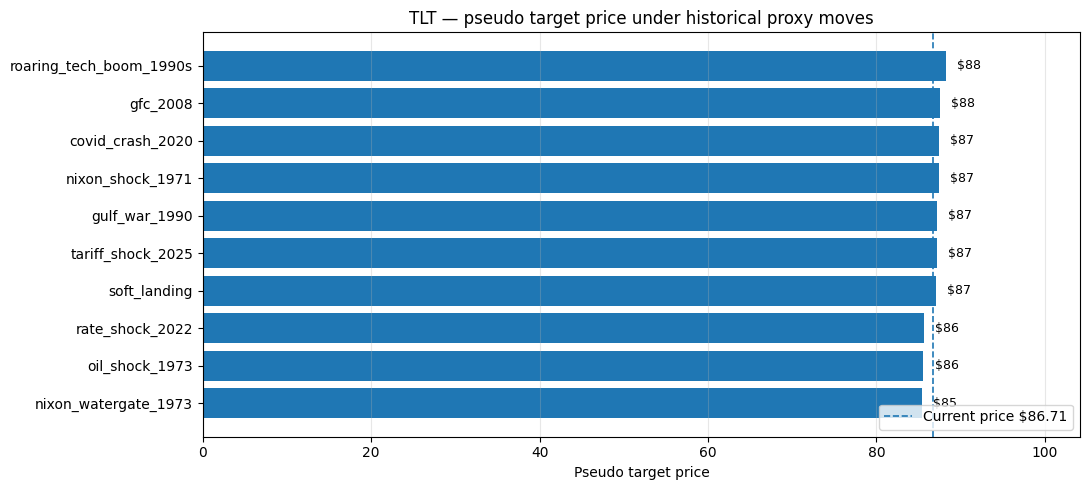

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 08B — PROXY SENSITIVITY + HISTORICAL EVENT PSEUDO TARGETS
# ══════════════════════════════════════════════════════════════════════════════
# Purpose:
#   1) Estimate each ticker's sensitivity to the 18 macro proxies.
#   2) Measure how proxies moved during historical event windows.
#   3) Apply ticker sensitivities to those historical proxy moves to create
#      pseudo target prices, even when a ticker did not exist during the event.
#
# Method:
#   Daily ticker returns ~ alpha + 18 proxy returns using Ridge/OLS-style regression.
#   Ridge is used by default because 18 proxies are highly correlated.
#
# Interpretation:
#   pseudo_event_return ≈ Σ beta_proxy × event_proxy_return
#   pseudo_target_price = current_price × (1 + pseudo_event_return)

from IPython.display import display, HTML
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

try:
    from sklearn.linear_model import Ridge, LinearRegression
    from sklearn.preprocessing import StandardScaler
except Exception as e:
    raise RuntimeError("scikit-learn is required for this cell. Re-run setup cell.") from e


# ─────────────────────────────────────────────────────────────────────────────
# USER SETTINGS
# ─────────────────────────────────────────────────────────────────────────────
# Sync ticker list with enabled markets in SIM_CONFIG
SENS_TICKERS = []

for nation, mkt in SIM_CONFIG["MARKETS"].items():
    if not mkt.get("enabled", False):
        continue
    SENS_TICKERS.extend(list(mkt["tickers"].keys()))

# de-duplicate while preserving order
SENS_TICKERS = list(dict.fromkeys(SENS_TICKERS))

print(f"Synced SENS_TICKERS from SIM_CONFIG: {SENS_TICKERS}")

SENS_START = "2019-01-01"      # for estimating ticker sensitivity
SENS_END = None                # None = latest
SENS_REGRESSION = "ridge"      # "ridge" or "ols"
RIDGE_ALPHA = 5.0              # higher = more stable / more shrinkage

MIN_OBS = 252                  # minimum daily observations for regression
USE_STANDARDIZED_BETAS = False # False = return-space beta; True = z-score beta

# Historical event windows.
# For old events, ETF proxies did not exist, so this cell uses SCENARIO_LIBRARY phases
# as fallback proxy templates where actual proxy data is unavailable.
EVENT_WINDOWS = {
    "oil_shock_1973":        ("1973-01-01", "1975-06-30"),
    "nixon_shock_1971":      ("1971-08-01", "1972-12-31"),
    "nixon_watergate_1973":  ("1973-01-01", "1974-12-31"),
    "gulf_war_1990":         ("1990-08-01", "1991-06-30"),
    "roaring_tech_boom_1990s": ("1995-01-01", "2000-03-01"),
    "gfc_2008":              ("2007-10-01", "2010-12-31"),
    "covid_crash_2020":      ("2020-02-01", "2021-06-30"),
    "rate_shock_2022":       ("2022-01-01", "2023-12-31"),
    "soft_landing":          ("2023-01-01", "2024-06-30"),
    "tariff_shock_2025":     ("2025-03-01", "2025-12-31"),
}

print("\n" + "="*90)
print("🧪 TICKER × 18-PROXY SENSITIVITY + HISTORICAL EVENT PSEUDO TARGETS")
print("="*90)
print(f"Tickers      : {SENS_TICKERS}")
print(f"Fit window   : {SENS_START} → {SENS_END or 'latest'}")
print(f"Regression   : {SENS_REGRESSION.upper()} | standardized={USE_STANDARDIZED_BETAS}")
print(f"Proxy count  : {len(_PROXIES)}")


# ─────────────────────────────────────────────────────────────────────────────
# DOWNLOAD DATA
# ─────────────────────────────────────────────────────────────────────────────
if not _YF_AVAILABLE:
    raise RuntimeError("yfinance is required for this cell.")

proxy_symbols = list(dict.fromkeys(_PROXIES.values()))
all_symbols = sorted(set(SENS_TICKERS + proxy_symbols))

px = yf.download(
    all_symbols,
    start=SENS_START,
    end=SENS_END,
    auto_adjust=True,
    progress=False,
)["Close"]

if isinstance(px, pd.Series):
    px = px.to_frame(name=all_symbols[0])

px = px.dropna(axis=1, how="all").ffill()
rets = px.pct_change(fill_method=None).replace([np.inf, -np.inf], np.nan)

# role → symbol map, only available symbols
role_to_sym = {role: sym for role, sym in _PROXIES.items() if sym in rets.columns}
proxy_roles = list(role_to_sym.keys())

proxy_ret = pd.DataFrame({
    role: rets[sym]
    for role, sym in role_to_sym.items()
}).dropna(how="all")

print(f"Available proxy roles: {len(proxy_roles)} / {len(_PROXIES)}")
print(", ".join([f"{r}={role_to_sym[r]}" for r in proxy_roles]))


# ─────────────────────────────────────────────────────────────────────────────
# FIT TICKER SENSITIVITY TO PROXIES
# ─────────────────────────────────────────────────────────────────────────────
SENSITIVITY_ROWS = []
SENSITIVITY_MATRIX = {}

for ticker in SENS_TICKERS:
    if ticker not in rets.columns:
        print(f"⚠ {ticker}: no price data, skipped.")
        continue

    y = rets[ticker].rename("ticker_ret")
    df_fit = pd.concat([y, proxy_ret], axis=1).dropna()

    if len(df_fit) < MIN_OBS:
        print(f"⚠ {ticker}: insufficient observations ({len(df_fit)}), skipped.")
        continue

    yv = df_fit["ticker_ret"].values
    X = df_fit[proxy_roles].values

    if USE_STANDARDIZED_BETAS:
        x_scaler = StandardScaler()
        y_scaler = StandardScaler()
        X_fit = x_scaler.fit_transform(X)
        y_fit = y_scaler.fit_transform(yv.reshape(-1, 1)).ravel()
    else:
        X_fit = X
        y_fit = yv

    if SENS_REGRESSION.lower() == "ols":
        model = LinearRegression()
    else:
        model = Ridge(alpha=RIDGE_ALPHA)

    model.fit(X_fit, y_fit)

    coefs = pd.Series(model.coef_, index=proxy_roles)
    alpha = float(model.intercept_)
    r2 = float(model.score(X_fit, y_fit))

    SENSITIVITY_MATRIX[ticker] = coefs

    row = {
        "ticker": ticker,
        "alpha_daily": alpha,
        "r2": r2,
        "n_obs": len(df_fit),
        "regression": SENS_REGRESSION,
        "standardized": USE_STANDARDIZED_BETAS,
    }
    row.update(coefs.to_dict())
    SENSITIVITY_ROWS.append(row)

SENSITIVITY_TABLE = pd.DataFrame(SENSITIVITY_ROWS).set_index("ticker")

print("\n✅ Ticker sensitivity table")
display(SENSITIVITY_TABLE.round(4))


# ─────────────────────────────────────────────────────────────────────────────
# EVENT PROXY MOVEMENT HELPERS
# ─────────────────────────────────────────────────────────────────────────────
def scenario_phase_total_return(sc_key: str) -> float:
    """
    Fallback total return from scenario phase drifts.
    This is used when actual proxy price history is unavailable.
    """
    if sc_key not in SCENARIOS:
        return 0.0

    total_log = 0.0
    for dur_m, ann_drift, ann_vol, desc in SCENARIOS[sc_key]["phases"]:
        total_log += ann_drift * (dur_m / 12.0)

    return float(np.exp(total_log) - 1)


def fallback_proxy_event_moves(sc_key: str) -> dict:
    """
    Approximate role-level proxy moves for old scenarios where modern ETFs
    do not exist. These are intentionally directional, not exact historical data.
    """
    base = {role: 0.0 for role in proxy_roles}
    market_move = scenario_phase_total_return(sc_key)

    # default market-style moves
    for role in ["market", "tech", "small_cap", "discretionary", "financials"]:
        if role in base:
            base[role] = market_move

    if "staples" in base:
        base["staples"] = market_move * 0.45

    if "volatility" in base:
        base["volatility"] = abs(market_move) * 0.8 if market_move < 0 else -0.15

    if "credit_hy" in base:
        base["credit_hy"] = market_move * 0.55
    if "credit_ig" in base:
        base["credit_ig"] = market_move * 0.30
    if "credit_em" in base:
        base["credit_em"] = market_move * 0.50

    if "long_bond" in base:
        base["long_bond"] = -0.25 * market_move
    if "short_bond" in base:
        base["short_bond"] = -0.10 * market_move
    if "tbill" in base:
        base["tbill"] = 0.02

    if "tips" in base:
        base["tips"] = 0.05
    if "usd" in base:
        base["usd"] = 0.05
    if "commodity" in base:
        base["commodity"] = 0.05
    if "gold" in base:
        base["gold"] = 0.05
    if "oil" in base:
        base["oil"] = 0.05

    # scenario-specific overrides
    if sc_key in ["oil_shock_1973", "nixon_watergate_1973"]:
        for role in ["oil", "commodity"]:
            if role in base:
                base[role] = 0.80
        if "gold" in base:
            base["gold"] = 0.65
        if "long_bond" in base:
            base["long_bond"] = -0.25
        if "usd" in base:
            base["usd"] = -0.10

    elif sc_key == "nixon_shock_1971":
        if "gold" in base:
            base["gold"] = 0.35
        if "usd" in base:
            base["usd"] = -0.15
        if "commodity" in base:
            base["commodity"] = 0.15

    elif sc_key == "gulf_war_1990":
        if "oil" in base:
            base["oil"] = 0.35
        if "gold" in base:
            base["gold"] = 0.12

    elif sc_key == "roaring_tech_boom_1990s":
        if "market" in base:
            base["market"] = 1.20
        if "tech" in base:
            base["tech"] = 2.20
        if "small_cap" in base:
            base["small_cap"] = 0.90
        if "gold" in base:
            base["gold"] = -0.25
        if "long_bond" in base:
            base["long_bond"] = -0.10
        if "usd" in base:
            base["usd"] = 0.20
        if "oil" in base:
            base["oil"] = -0.10

    elif sc_key == "gfc_2008":
        if "market" in base:
            base["market"] = -0.45
        if "tech" in base:
            base["tech"] = -0.35
        if "small_cap" in base:
            base["small_cap"] = -0.50
        if "financials" in base:
            base["financials"] = -0.70
        if "credit_hy" in base:
            base["credit_hy"] = -0.25
        if "credit_ig" in base:
            base["credit_ig"] = -0.10
        if "long_bond" in base:
            base["long_bond"] = 0.25
        if "gold" in base:
            base["gold"] = 0.15
        if "usd" in base:
            base["usd"] = 0.15

    elif sc_key == "covid_crash_2020":
        if "market" in base:
            base["market"] = 0.35
        if "tech" in base:
            base["tech"] = 0.65
        if "oil" in base:
            base["oil"] = -0.45
        if "long_bond" in base:
            base["long_bond"] = 0.20
        if "gold" in base:
            base["gold"] = 0.25

    elif sc_key == "rate_shock_2022":
        if "market" in base:
            base["market"] = -0.15
        if "tech" in base:
            base["tech"] = -0.30
        if "long_bond" in base:
            base["long_bond"] = -0.30
        if "short_bond" in base:
            base["short_bond"] = -0.08
        if "usd" in base:
            base["usd"] = 0.10
        if "oil" in base:
            base["oil"] = 0.20

    elif sc_key == "soft_landing":
        if "market" in base:
            base["market"] = 0.25
        if "tech" in base:
            base["tech"] = 0.35
        if "long_bond" in base:
            base["long_bond"] = 0.10
        if "gold" in base:
            base["gold"] = 0.05

    elif sc_key == "tariff_shock_2025":
        if "market" in base:
            base["market"] = -0.08
        if "tech" in base:
            base["tech"] = -0.12
        if "usd" in base:
            base["usd"] = 0.08
        if "commodity" in base:
            base["commodity"] = 0.06

    return base


def actual_proxy_event_moves(start, end) -> tuple[dict, int]:
    """
    Actual proxy ETF total returns during the event window.
    Returns (moves, available_count).
    """
    start = pd.Timestamp(start)
    end = pd.Timestamp(end)

    moves = {}
    available = 0

    for role, sym in role_to_sym.items():
        if sym not in px.columns:
            continue

        s = px[sym].loc[start:end].dropna()
        if len(s) >= 20:
            moves[role] = float(s.iloc[-1] / s.iloc[0] - 1)
            available += 1
        else:
            moves[role] = np.nan

    return moves, available


def event_proxy_moves(sc_key, start, end):
    actual, n_avail = actual_proxy_event_moves(start, end)
    fallback = fallback_proxy_event_moves(sc_key)

    final = {}
    source = {}

    for role in proxy_roles:
        if role in actual and pd.notna(actual[role]):
            final[role] = actual[role]
            source[role] = "actual_proxy_history"
        else:
            final[role] = fallback.get(role, 0.0)
            source[role] = "scenario_template_fallback"

    return final, source, n_avail


# ─────────────────────────────────────────────────────────────────────────────
# BUILD EVENT PROXY MOVE TABLE
# ─────────────────────────────────────────────────────────────────────────────
EVENT_PROXY_ROWS = []

for sc_key, (start, end) in EVENT_WINDOWS.items():
    moves, sources, n_avail = event_proxy_moves(sc_key, start, end)

    row = {
        "event": sc_key,
        "start": start,
        "end": end,
        "actual_proxy_count": n_avail,
    }
    row.update(moves)
    EVENT_PROXY_ROWS.append(row)

EVENT_PROXY_MOVES = pd.DataFrame(EVENT_PROXY_ROWS).set_index("event")

print("\n✅ Event proxy movement table")
display(EVENT_PROXY_MOVES.round(3))


# ─────────────────────────────────────────────────────────────────────────────
# APPLY TICKER SENSITIVITY TO EVENT PROXY MOVES
# ─────────────────────────────────────────────────────────────────────────────
current_prices = {}

try:
    for nation, pxs in LIVE_PRICES.items():
        for t, p in pxs.items():
            current_prices[t] = float(p)
except Exception:
    pass

# fallback to downloaded latest prices
for t in SENS_TICKERS:
    if t not in current_prices and t in px.columns:
        current_prices[t] = float(px[t].dropna().iloc[-1])


PSEUDO_ROWS = []
CONTRIB_ROWS = []

for ticker, sens in SENSITIVITY_MATRIX.items():
    cur_px = current_prices.get(ticker, np.nan)
    if not np.isfinite(cur_px) or cur_px <= 0:
        continue

    for event in EVENT_PROXY_MOVES.index:
        proxy_move = EVENT_PROXY_MOVES.loc[event, proxy_roles].astype(float)

        # If using standardized betas, this is an index score rather than direct return.
        # Keep it as pseudo return for comparison, but prefer USE_STANDARDIZED_BETAS=False.
        contrib = sens.reindex(proxy_roles).fillna(0.0) * proxy_move.reindex(proxy_roles).fillna(0.0)

        pseudo_ret = float(contrib.sum())
        pseudo_ret_clipped = float(np.clip(pseudo_ret, -0.90, 5.00))
        pseudo_target = cur_px * (1.0 + pseudo_ret_clipped)

        PSEUDO_ROWS.append({
            "ticker": ticker,
            "event": event,
            "current_price": cur_px,
            "pseudo_event_return_%": pseudo_ret_clipped * 100,
            "pseudo_target_price": pseudo_target,
            "actual_proxy_count": EVENT_PROXY_MOVES.loc[event, "actual_proxy_count"],
            "top_positive_proxy": contrib.sort_values(ascending=False).index[0],
            "top_positive_contrib_%": contrib.sort_values(ascending=False).iloc[0] * 100,
            "top_negative_proxy": contrib.sort_values(ascending=True).index[0],
            "top_negative_contrib_%": contrib.sort_values(ascending=True).iloc[0] * 100,
        })

        for role, val in contrib.items():
            CONTRIB_ROWS.append({
                "ticker": ticker,
                "event": event,
                "proxy_role": role,
                "proxy_symbol": role_to_sym.get(role, ""),
                "sensitivity": sens.get(role, np.nan),
                "event_proxy_move_%": proxy_move.get(role, np.nan) * 100,
                "contribution_%": val * 100,
            })

PSEUDO_TARGETS = pd.DataFrame(PSEUDO_ROWS)
PSEUDO_CONTRIBUTIONS = pd.DataFrame(CONTRIB_ROWS)

print("\n✅ Pseudo target prices by ticker × event")
display(PSEUDO_TARGETS.sort_values(["ticker", "event"]).round(2))

print("\n✅ Proxy contribution detail")
display(PSEUDO_CONTRIBUTIONS.sort_values(["ticker", "event", "contribution_%"], ascending=[True, True, False]).round(4))


# ─────────────────────────────────────────────────────────────────────────────
# SAVE OUTPUTS
# ─────────────────────────────────────────────────────────────────────────────
os.makedirs(_SAVE_DIR, exist_ok=True)

sens_path = os.path.join(_SAVE_DIR, "ticker_proxy_sensitivity_18proxies.csv")
event_path = os.path.join(_SAVE_DIR, "event_proxy_moves_18proxies.csv")
target_path = os.path.join(_SAVE_DIR, "pseudo_event_target_prices.csv")
contrib_path = os.path.join(_SAVE_DIR, "pseudo_event_proxy_contributions.csv")

SENSITIVITY_TABLE.to_csv(sens_path)
EVENT_PROXY_MOVES.to_csv(event_path)
PSEUDO_TARGETS.to_csv(target_path, index=False)
PSEUDO_CONTRIBUTIONS.to_csv(contrib_path, index=False)

print("\n✅ Saved:")
print(f"  sensitivity table     → {sens_path}")
print(f"  event proxy moves     → {event_path}")
print(f"  pseudo targets        → {target_path}")
print(f"  proxy contributions   → {contrib_path}")

# ─────────────────────────────────────────────────────────────────────────────
# VISUALS: CHOOSE WHICH TICKERS TO PLOT
# ─────────────────────────────────────────────────────────────────────────────

PLOT_TICKERS = "ALL"      # use "ALL" for all tickers, or list like ["NVDA", "AAPL"]

if PLOT_TICKERS == "ALL":
    tickers_to_plot = list(SENSITIVITY_TABLE.index)
else:
    tickers_to_plot = [t for t in PLOT_TICKERS if t in SENSITIVITY_TABLE.index]

for ticker in tickers_to_plot:
    tdf = PSEUDO_TARGETS[PSEUDO_TARGETS["ticker"] == ticker].copy()
    if tdf.empty:
        continue

    print(f"\n📊 {ticker} pseudo target chart")

    tdf = tdf.sort_values("pseudo_target_price")

    fig, ax = plt.subplots(figsize=(11, 5))

    bars = ax.barh(tdf["event"], tdf["pseudo_target_price"])

    current_px = tdf["current_price"].iloc[0]
    ax.axvline(
        current_px,
        linestyle="--",
        lw=1.2,
        label=f"Current price ${current_px:,.2f}"
    )

    xmax = max(tdf["pseudo_target_price"].max(), current_px)
    ax.set_xlim(0, xmax * 1.18)

    for bar, price in zip(bars, tdf["pseudo_target_price"]):
        ax.text(
            bar.get_width() + xmax * 0.015,
            bar.get_y() + bar.get_height() / 2,
            f"${price:,.0f}",
            va="center",
            fontsize=9
        )

    ax.set_title(f"{ticker} — pseudo target price under historical proxy moves")
    ax.set_xlabel("Pseudo target price")
    ax.grid(axis="x", alpha=0.3)
    ax.legend(loc="lower right")

    plt.tight_layout()
    plt.show()
    plt.close(fig)

## Cell 09 — 📐 Factor regression + scenario projection

**Step 1:** Regress last 252 days of each ticker vs 18 proxy returns → factor loadings.  
**Step 2:** Pull how proxies actually moved during each historical shock.  
**Step 3:** `implied_return = Σ (loading × proxy_move_in_scenario)`.

Different from Cell 07: uses your ticker's *actual factor sensitivity* rather than
parametric drift/vol. A gold miner gets a different projection than a tech stock
under the oil shock scenario because their loadings to USO and GLD differ.

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 09 — 📐 FACTOR REGRESSION + SCENARIO PROJECTION
#          Ridge + self-proxy exclusion + wide table output
# ══════════════════════════════════════════════════════════════════════════════

from IPython.display import display, HTML
from sklearn.linear_model import Ridge
import numpy as np
import pandas as pd
import os

LOOKBACK = 252
MIN_OBS = 120

USE_RIDGE = True
RIDGE_ALPHA = 10.0
EXCLUDE_SELF_PROXY = True

display(HTML("""
<style>
.output_area {
    max-width: 100% !important;
}
table {
    font-size: 12px !important;
}
</style>
"""))

print("\n" + "="*90)
print("📐 FACTOR REGRESSION + SCENARIO PROJECTION")
print(f"Projection : {_PROJ_START.date()} → {_PROJ_END.date()}  ({_HORIZON:.2f} yrs)")
print(f"Regression : {'Ridge' if USE_RIDGE else 'OLS'} | lookback {LOOKBACK} trading days | {len(_PROXIES)} proxy instruments")
print(f"Ridge alpha: {RIDGE_ALPHA if USE_RIDGE else 'n/a'} | self-proxy excluded={EXCLUDE_SELF_PROXY}")
print("="*90)

# ─────────────────────────────────────────────────────────────────────────────
# 1. Download recent price data
# ─────────────────────────────────────────────────────────────────────────────
all_syms = list(_TICKERS.keys())
proxy_syms = list(set(_PROXIES.values()))

price_data = yf.download(
    all_syms + proxy_syms,
    period="2y",
    auto_adjust=True,
    progress=False
)["Close"]

if isinstance(price_data, pd.Series):
    price_data = price_data.to_frame()

price_data = price_data.dropna(axis=1, how="all")
ret = price_data.pct_change(fill_method=None).dropna()

ticker_ret = ret[[c for c in ret.columns if c in all_syms]]
proxy_ret = ret[[c for c in ret.columns if c in proxy_syms]]

common_idx = ticker_ret.index.intersection(proxy_ret.index)
ticker_ret = ticker_ret.loc[common_idx]
proxy_ret = proxy_ret.loc[common_idx]

# ─────────────────────────────────────────────────────────────────────────────
# 2. Factor regression
# ─────────────────────────────────────────────────────────────────────────────
loadings = {}
reg_stats = {}

sym_to_role = {v: k for k, v in _PROXIES.items()}

for tkr in ticker_ret.columns:
    y = ticker_ret[tkr].dropna().iloc[-LOOKBACK:]

    X = proxy_ret.loc[y.index].dropna(axis=1, how="all")
    X = X.loc[y.index]

    # Important: avoid SPY~SPY, QQQ~QQQ, GLD~GLD, TLT~TLT self-regression
    if EXCLUDE_SELF_PROXY and tkr in X.columns:
        X = X.drop(columns=[tkr])

    # Drop columns with no useful variation
    X = X.loc[:, X.std() > 1e-10]

    # Align cleanly
    df_fit = pd.concat([y.rename("y"), X], axis=1).dropna()
    y_clean = df_fit["y"]
    X_clean = df_fit.drop(columns=["y"])

    if len(y_clean) < MIN_OBS or X_clean.shape[1] < 3:
        print(f"⚠ skipped {tkr}: obs={len(y_clean)}, proxies={X_clean.shape[1]}")
        continue

    X_mat = X_clean.values
    y_vec = y_clean.values

    try:
        if USE_RIDGE:
            model = Ridge(alpha=RIDGE_ALPHA, fit_intercept=True)
            model.fit(X_mat, y_vec)
            y_hat = model.predict(X_mat)
            coef = pd.Series(model.coef_, index=X_clean.columns)
            intercept = float(model.intercept_)
        else:
            X_design = np.column_stack([np.ones(len(X_mat)), X_mat])
            beta, res, rank, _ = np.linalg.lstsq(X_design, y_vec, rcond=None)
            y_hat = X_design @ beta
            coef = pd.Series(beta[1:], index=X_clean.columns)
            intercept = float(beta[0])

        ss_res = float(np.sum((y_vec - y_hat) ** 2))
        ss_tot = float(np.sum((y_vec - y_vec.mean()) ** 2))
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0.0

        loadings[tkr] = coef

        top_sym = coef.abs().idxmax()
        top_role = sym_to_role.get(top_sym, top_sym)

        reg_stats[tkr] = {
            "r2": r2,
            "n_obs": len(y_clean),
            "top_proxy_sym": top_sym,
            "top_proxy": top_role,
            "top_loading": float(coef[top_sym]),
            "coverage": len(coef),
            "intercept": intercept,
        }

    except Exception as e:
        print(f"⚠ regression failed [{tkr}]: {e}")

loadings_df = pd.DataFrame(loadings).T

print(f"\n✅ Regression complete — {len(loadings_df)} tickers estimated")

# ─────────────────────────────────────────────────────────────────────────────
# 3. Scenario cumulative proxy shocks
# ─────────────────────────────────────────────────────────────────────────────
scenario_shocks = {}

for sc_key in SCENARIO_WINDOWS:
    df = _fetch_scenario_returns(sc_key)

    if df.empty:
        continue

    cum_ret = (1 + df).prod() - 1

    s_str, e_str = SCENARIO_WINDOWS[sc_key]
    from datetime import datetime as _dt

    sc_yrs = (_dt.strptime(e_str, "%Y-%m-%d") - _dt.strptime(s_str, "%Y-%m-%d")).days / 365.25
    sc_yrs = max(sc_yrs, 0.25)

    ann_ret = (1 + cum_ret) ** (1 / sc_yrs) - 1
    scaled = (1 + ann_ret) ** _HORIZON - 1

    role_to_sym = {**MODERN_PROXIES, **HISTORICAL_PROXIES}

    shock_series = {}
    for role, val in scaled.items():
        sym = role_to_sym.get(role)
        if sym:
            shock_series[sym] = float(val)

    scenario_shocks[sc_key] = pd.Series(shock_series)

scenario_shocks_df = pd.DataFrame(scenario_shocks).T.fillna(0.0)

# ─────────────────────────────────────────────────────────────────────────────
# 4. Induced return per ticker × scenario
# ─────────────────────────────────────────────────────────────────────────────
projection = {}

for tkr in loadings_df.index:
    coef = loadings_df.loc[tkr].dropna()
    sc_vals = {}

    for sc in scenario_shocks_df.index:
        shock = scenario_shocks_df.loc[sc]
        common = coef.index.intersection(shock.index)

        if len(common) < 3:
            sc_vals[sc] = 0.0
            continue

        val = float((coef[common] * shock[common]).sum())

        # safer cap than before
        val = np.clip(val, -0.75, 1.50)

        sc_vals[sc] = val

    projection[tkr] = sc_vals

projection_df = pd.DataFrame(projection).T

# ─────────────────────────────────────────────────────────────────────────────
# 5. Weighted expected return
# ─────────────────────────────────────────────────────────────────────────────
_wts = FINAL_WEIGHTS if "FINAL_WEIGHTS" in dir() else DEFAULT_WEIGHTS
weights_series = pd.Series(_wts)

common_sc = projection_df.columns.intersection(weights_series.index)
proj_al = projection_df[common_sc]
w_al = weights_series[common_sc] / weights_series[common_sc].sum()

expected_ret = proj_al.dot(w_al)

# ─────────────────────────────────────────────────────────────────────────────
# 6. Reliability
# ─────────────────────────────────────────────────────────────────────────────
def _reliability(stats):
    r2 = stats.get("r2", 0)
    n = stats.get("n_obs", 0)
    cov = stats.get("coverage", 0)

    if r2 > 0.75 and n > 200 and cov > 10:
        return "★★★ HIGH"
    elif r2 > 0.45 and n > 150 and cov > 6:
        return "★★☆ MEDIUM"
    else:
        return "★☆☆ LOW"

# ─────────────────────────────────────────────────────────────────────────────
# 7. Current prices and betas
# ─────────────────────────────────────────────────────────────────────────────
px_now = pd.Series(dtype=float)

try:
    for nation_px in LIVE_PRICES.values():
        px_now = pd.concat([px_now, nation_px])
except Exception:
    pass

missing_px = [t for t in loadings_df.index if t not in px_now.index]
if missing_px:
    px_now = pd.concat([px_now, _yf_prices(missing_px)])

betas_now = pd.Series(dtype=float)

try:
    for nation_beta in LIVE_BETAS.values():
        betas_now = pd.concat([betas_now, nation_beta])
except Exception:
    pass

# ─────────────────────────────────────────────────────────────────────────────
# 8. Build clean output table
# ─────────────────────────────────────────────────────────────────────────────
SC_SHORT = {
    "oil_shock_1973": "Oil73",
    "gulf_war_1990": "Gulf90",
    "roaring_tech_boom_1990s": "Tech95",
    "gfc_2008": "GFC08",
    "covid_crash_2020": "Covid",
    "rate_shock_2022": "Rate22",
    "tariff_shock_2025": "Tariff",
    "soft_landing": "Soft",
    "nixon_shock_1971": "Nixn71",
    "nixon_watergate_1973": "NixnWG",
}

sc_order = [s for s in SC_SHORT.keys() if s in projection_df.columns]

summary_rows = []

for tkr in sorted(loadings_df.index):
    st = reg_stats.get(tkr, {})

    r2 = st.get("r2", 0)
    n_obs = st.get("n_obs", 0)
    cov = st.get("coverage", 0)
    top_p = st.get("top_proxy", "?")

    beta = float(betas_now.get(tkr, 1.0))
    px = float(px_now.get(tkr, np.nan))

    exp_r = float(expected_ret.get(tkr, np.nan))
    exp_p = px * (1 + exp_r) if np.isfinite(px) and np.isfinite(exp_r) else np.nan

    sc_vals_tkr = {
        s: projection_df.loc[tkr, s]
        for s in sc_order
        if s in projection_df.columns
    }

    best_sc = max(sc_vals_tkr, key=sc_vals_tkr.get) if sc_vals_tkr else "-"
    worst_sc = min(sc_vals_tkr, key=sc_vals_tkr.get) if sc_vals_tkr else "-"

    row = {
        "ticker": tkr,
        "current_price": px,
        "beta": beta,
        "top_proxy": top_p,
        "r2": r2,
        "n_obs": n_obs,
        "proxy_coverage": cov,
        "reliability": _reliability(st),
        "exp_return_%": exp_r * 100,
        "exp_price": exp_p,
        "best_scenario": SC_SHORT.get(best_sc, best_sc),
        "worst_scenario": SC_SHORT.get(worst_sc, worst_sc),
    }

    for s in sc_order:
        row[SC_SHORT.get(s, s)] = projection_df.loc[tkr, s] * 100

    summary_rows.append(row)

FACTOR_SUMMARY = pd.DataFrame(summary_rows).set_index("ticker")

# ─────────────────────────────────────────────────────────────────────────────
# 9. Wide display tables
# ─────────────────────────────────────────────────────────────────────────────
display(HTML("<h3>📊 Factor Projection Summary</h3>"))

summary_display = FACTOR_SUMMARY.copy()

num_cols = summary_display.select_dtypes(include="number").columns
summary_display[num_cols] = summary_display[num_cols].round(2)

summary_display = summary_display.sort_values("exp_return_%", ascending=False)

display(HTML("""
<div style="overflow-x:auto; width:100%; border:1px solid #ddd; padding:8px;">
""" + summary_display.to_html() + """
</div>
"""))

display(HTML("<h3>📈 Scenario Return Matrix (%)</h3>"))

scenario_cols = [SC_SHORT[s] for s in sc_order if SC_SHORT[s] in summary_display.columns]

scenario_display = summary_display[
    ["current_price", "exp_return_%", "exp_price", "reliability"] + scenario_cols
].copy()

display(HTML("""
<div style="overflow-x:auto; width:100%; border:1px solid #ddd; padding:8px;">
""" + scenario_display.to_html() + """
</div>
"""))

display(HTML("<h3>🧬 Raw Proxy Loadings</h3>"))

loadings_named = loadings_df.copy()
loadings_named = loadings_named.rename(columns=sym_to_role)

display(HTML("""
<div style="overflow-x:auto; width:100%; border:1px solid #ddd; padding:8px;">
""" + loadings_named.round(4).to_html() + """
</div>
"""))

# ─────────────────────────────────────────────────────────────────────────────
# 10. Save outputs
# ─────────────────────────────────────────────────────────────────────────────
FACTOR_PROJECTION = projection_df
FACTOR_EXPECTED = expected_ret

if _SAVE_DIR:
    os.makedirs(_SAVE_DIR, exist_ok=True)

    summary_path = os.path.join(_SAVE_DIR, "factor_projection_summary.csv")
    projection_path = os.path.join(_SAVE_DIR, "factor_projection_matrix.csv")
    loadings_path = os.path.join(_SAVE_DIR, "factor_proxy_loadings.csv")

    FACTOR_SUMMARY.to_csv(summary_path)
    FACTOR_PROJECTION.to_csv(projection_path)
    loadings_named.to_csv(loadings_path)

    print("\n✅ Saved:")
    print(f"  summary     → {summary_path}")
    print(f"  scenarios   → {projection_path}")
    print(f"  loadings    → {loadings_path}")

print("\nNotes:")
print("  • This is a deterministic factor model, not Monte Carlo.")
print("  • Regression uses Ridge by default to reduce unstable proxy coefficients.")
print("  • Self-proxy is excluded, so SPY is not regressed on SPY, QQQ not on QQQ, etc.")
print("  • ExpRet = scenario-weighted expected return using FINAL_WEIGHTS or DEFAULT_WEIGHTS.")
print("  • ExpPrice = current price × (1 + ExpRet).")
print("  • Use Cell 07 for probability bands / uncertainty ranges.")
print("  • LOW reliability names should be treated as directional only.")
print("="*90)


📐 FACTOR REGRESSION + SCENARIO PROJECTION
Projection : 2026-05-08 → 2029-01-20  (2.70 yrs)
Regression : Ridge | lookback 252 trading days | 18 proxy instruments
Ridge alpha: 10.0 | self-proxy excluded=True

✅ Regression complete — 11 tickers estimated


,current_price,beta,top_proxy,r2,n_obs,proxy_coverage,reliability,exp_return_%,exp_price,best_scenario,worst_scenario,Oil73,Gulf90,Tech95,GFC08,Covid,Rate22,Tariff,Soft,Nixn71,NixnWG
ticker,,,,,,,,,,,,,,,,,,,,,
TSM,402.46,1.26,volatility,0.08,252,18,★☆☆ LOW,0.29,403.64,Tariff,Oil73,0.0,0.0,0.0,0.26,0.52,0.57,2.27,1.55,0.0,0.0
NVDA,208.27,1.83,volatility,0.07,252,18,★☆☆ LOW,0.23,208.74,Tariff,Oil73,0.0,0.0,0.0,0.12,0.34,0.54,1.78,1.35,0.0,0.0
IWM,276.65,1.08,volatility,0.14,252,17,★☆☆ LOW,0.20,277.21,Tariff,Oil73,0.0,0.0,0.0,0.13,0.46,0.39,1.65,1.20,0.0,0.0
QQQ,663.88,1.13,volatility,0.16,252,17,★☆☆ LOW,0.18,665.05,Tariff,Oil73,0.0,0.0,0.0,0.11,0.36,0.37,1.41,1.07,0.0,0.0
SPY,713.94,1.00,volatility,0.18,252,17,★☆☆ LOW,0.14,714.95,Tariff,Oil73,0.0,0.0,0.0,0.08,0.31,0.29,1.14,0.87,0.0,0.0
AAPL,271.06,1.03,volatility,0.06,252,18,★☆☆ LOW,0.13,271.42,Tariff,Oil73,0.0,0.0,0.0,0.05,0.31,0.31,1.07,0.90,0.0,0.0
MSFT,424.62,1.06,volatility,0.03,252,18,★☆☆ LOW,0.10,425.06,Tariff,Oil73,0.0,0.0,0.0,0.02,0.22,0.25,0.85,0.71,0.0,0.0
TLT,86.71,0.68,oil,0.00,252,17,★☆☆ LOW,0.02,86.73,Tariff,Rate22,0.0,0.0,0.0,0.07,0.08,-0.03,0.14,0.03,0.0,0.0
GLD,433.25,0.45,commodity,0.00,252,17,★☆☆ LOW,0.00,433.26,Covid,Tariff,0.0,0.0,0.0,0.02,0.12,0.00,-0.01,-0.01,0.0,0.0


,current_price,exp_return_%,exp_price,reliability,Oil73,Gulf90,Tech95,GFC08,Covid,Rate22,Tariff,Soft,Nixn71,NixnWG
ticker,,,,,,,,,,,,,,
TSM,402.46,0.29,403.64,★☆☆ LOW,0.0,0.0,0.0,0.26,0.52,0.57,2.27,1.55,0.0,0.0
NVDA,208.27,0.23,208.74,★☆☆ LOW,0.0,0.0,0.0,0.12,0.34,0.54,1.78,1.35,0.0,0.0
IWM,276.65,0.20,277.21,★☆☆ LOW,0.0,0.0,0.0,0.13,0.46,0.39,1.65,1.20,0.0,0.0
QQQ,663.88,0.18,665.05,★☆☆ LOW,0.0,0.0,0.0,0.11,0.36,0.37,1.41,1.07,0.0,0.0
SPY,713.94,0.14,714.95,★☆☆ LOW,0.0,0.0,0.0,0.08,0.31,0.29,1.14,0.87,0.0,0.0
AAPL,271.06,0.13,271.42,★☆☆ LOW,0.0,0.0,0.0,0.05,0.31,0.31,1.07,0.90,0.0,0.0
MSFT,424.62,0.10,425.06,★☆☆ LOW,0.0,0.0,0.0,0.02,0.22,0.25,0.85,0.71,0.0,0.0
TLT,86.71,0.02,86.73,★☆☆ LOW,0.0,0.0,0.0,0.07,0.08,-0.03,0.14,0.03,0.0,0.0
GLD,433.25,0.00,433.26,★☆☆ LOW,0.0,0.0,0.0,0.02,0.12,0.00,-0.01,-0.01,0.0,0.0


,credit_em,gold,credit_hy,small_cap,credit_ig,commodity,tech,tbill,short_bond,market,tips,long_bond,oil,usd,financials,staples,discretionary,volatility
AAPL,0.0004,-0.0003,0.0003,0.0015,0.0002,-0.0005,0.0017,-0.0,-0.0000,0.0014,-0.0000,0.0000,-0.0016,0.0000,0.0013,0.0003,0.0018,-0.0120
CVX,-0.0001,-0.0002,0.0000,0.0003,-0.0001,0.0017,-0.0003,0.0,-0.0000,-0.0001,-0.0000,-0.0003,0.0043,0.0002,0.0001,0.0001,-0.0001,0.0002
GLD,0.0003,NaN,0.0001,0.0008,0.0002,0.0017,0.0004,-0.0,0.0001,0.0003,0.0002,0.0002,0.0002,-0.0007,-0.0002,0.0003,-0.0000,0.0004
IWM,0.0005,0.0008,0.0005,NaN,0.0004,-0.0003,0.0021,-0.0,0.0000,0.0018,0.0001,0.0002,-0.0018,-0.0002,0.0018,0.0004,0.0024,-0.0146
MSFT,0.0002,-0.0001,0.0003,0.0011,0.0001,-0.0001,0.0020,-0.0,-0.0000,0.0014,-0.0000,-0.0000,-0.0007,-0.0000,0.0009,-0.0005,0.0015,-0.0089
NVDA,0.0005,0.0004,0.0005,0.0024,0.0002,-0.0001,0.0038,-0.0,-0.0001,0.0026,-0.0001,-0.0001,-0.0015,0.0001,0.0009,-0.0012,0.0023,-0.0181
QQQ,0.0005,0.0004,0.0004,0.0021,0.0003,-0.0002,NaN,-0.0,-0.0000,0.0018,0.0000,0.0001,-0.0015,-0.0001,0.0012,-0.0001,0.0022,-0.0135
SPY,0.0004,0.0003,0.0004,0.0018,0.0002,-0.0003,0.0018,-0.0,0.0000,NaN,0.0000,0.0001,-0.0013,-0.0001,0.0012,0.0001,0.0018,-0.0110
TLT,0.0004,0.0002,0.0002,0.0002,0.0005,-0.0005,0.0001,-0.0,0.0001,0.0001,0.0003,NaN,-0.0011,-0.0002,0.0001,0.0002,0.0002,-0.0006
TSM,0.0008,0.0012,0.0006,0.0034,0.0004,-0.0005,0.0039,-0.0,0.0000,0.0027,0.0000,0.0002,-0.0032,-0.0001,0.0011,-0.0003,0.0028,-0.0208



✅ Saved:
  summary     → ./sim_output/factor_projection_summary.csv
  scenarios   → ./sim_output/factor_projection_matrix.csv
  loadings    → ./sim_output/factor_proxy_loadings.csv

Notes:
  • This is a deterministic factor model, not Monte Carlo.
  • Regression uses Ridge by default to reduce unstable proxy coefficients.
  • Self-proxy is excluded, so SPY is not regressed on SPY, QQQ not on QQQ, etc.
  • ExpRet = scenario-weighted expected return using FINAL_WEIGHTS or DEFAULT_WEIGHTS.
  • ExpPrice = current price × (1 + ExpRet).
  • Use Cell 07 for probability bands / uncertainty ranges.
  • LOW reliability names should be treated as directional only.


## Cell 13 — 🔍 Ad-hoc: any single ticker

In [ ]:
ADHOC_TICKER  = "NVDA"
ADHOC_PRICE   = None      # None = fetch from Yahoo Finance
ADHOC_BETA    = None      # None = from config or 1.0
ADHOC_WEIGHTS = None      # None = use adjusted_weights

if ADHOC_PRICE is None and _YF_AVAILABLE:
    raw = yf.download(ADHOC_TICKER, period="5d", auto_adjust=True, progress=False)["Close"]
    ADHOC_PRICE = float(raw.dropna().iloc[-1])
    print(f"Fetched {ADHOC_TICKER}: ${ADHOC_PRICE:.2f}")

ADHOC_BETA    = ADHOC_BETA    or float(_TICKERS.get(ADHOC_TICKER,{}).get("beta_override") or 1.0)
ADHOC_WEIGHTS = ADHOC_WEIGHTS or adjusted_weights if "adjusted_weights" in dir() else DEFAULT_WEIGHTS

print(f"\n▶ Blended fan chart: {ADHOC_TICKER}  ${ADHOC_PRICE:.2f}  β={ADHOC_BETA:.2f}")
_ = run_blended_simulation(ADHOC_TICKER, ADHOC_PRICE, ADHOC_WEIGHTS,
                            beta=ADHOC_BETA, save_dir=_SAVE_DIR, show_plot=True)

print(f"\n▶ All-scenario grid: {ADHOC_TICKER}")
_ = explore_single_ticker(ADHOC_TICKER, ADHOC_PRICE, beta=ADHOC_BETA,
                          n_paths=600, save_dir=_SAVE_DIR)

Fetched NVDA: $208.27

▶ Blended fan chart: NVDA  $208.27  β=1.00


KeyError: 'roaring_tech_boom_1990s'